# Riesgo de incumplimiento en préstamos de Lending Club

### scikit-learn frente a PySpark — modelado, comparación estadística e interpretabilidad

**Proyecto integrador de aprendizaje automático** · Machine Learning UN 202330

## Resumen

Este trabajo construye y compara modelos de clasificación supervisada para predecir si un préstamo otorgado por la plataforma Lending Club terminará en incumplimiento (`Charged Off`) o será pagado por completo (`Fully Paid`). Se utiliza el conjunto de datos completo de préstamos aceptados entre 2007 y 2018, sin ningún tipo de muestreo: 2,26 millones de registros, de los cuales 1,35 millones tienen un desenlace conocido.

Se implementan seis modelos en dos entornos, con espacios de búsqueda equivalentes y una misma partición de entrenamiento y prueba: regresión logística, árbol de decisión, bosque aleatorio, gradient boosting, máquina de vectores de soporte lineal y Naive Bayes, en **scikit-learn** y en **PySpark**. Las diferencias de desempeño se contrastan con la prueba de DeLong para AUC correlacionados, en su versión rápida de Sun y Xu (2014), y se verifican con las pruebas de McNemar y bootstrap pareado, con corrección de Holm por comparaciones múltiples. Por último, las predicciones erróneas se interpretan con LIME.

El mejor modelo en ambos entornos es **gradient boosting** (AUC de 0,720), con una ventaja significativa y relevante sobre la regresión logística. Los dos entornos alcanzan desempeños estadísticamente equivalentes en los modelos bien especificados, y scikit-learn resulta en general más rápido en un único equipo. La excepción es la máquina de vectores de soporte, cuyo resultado depende críticamente de la formulación del optimizador.

## Datos y objetivo

| | |
|---|---|
| Fuente | [Lending Club Loan Data](https://www.kaggle.com/datasets/wordsforthewise/lending-club), archivo `accepted_2007_to_2018Q4.csv` (1,7 GB) |
| Universo | 1.345.310 préstamos con desenlace conocido (sin muestreo) |
| Variable objetivo | `default` = 1 si `loan_status` es `Charged Off` (19,96 %), 0 si es `Fully Paid` |
| Partición | 80/20 estratificada, semilla 42, común a ambos entornos (1.076.248 / 269.062) |
| Predictores | 16 numéricos, 3 indicadores y 7 categóricos disponibles al originar el préstamo (91 columnas tras la codificación) |

## Resultados principales

| Modelo | AUC scikit-learn | AUC PySpark | Entrenamiento scikit-learn | Entrenamiento PySpark |
|---|---|---|---|---|
| **Gradient boosting** | **0,7198** | **0,7195** | 125,1 min | 80,8 min |
| Bosque aleatorio | 0,7151 | 0,7137 | 25,7 min | 105,1 min |
| Regresión logística | 0,7135 | 0,7135 | 0,4 min | 11,0 min |
| Árbol de decisión | 0,7029 | 0,7002 | 2,3 min | 3,7 min |
| Naive Bayes | 0,6390 | 0,6395 | 0,2 min | 2,9 min |
| SVM lineal (hinge) | 0,4611 | 0,6300 | 23,5 min | 21,1 min |

AUC calculado en el conjunto de prueba común. El tiempo de entrenamiento incluye la validación cruzada de 3 pliegues y el reajuste final.

**Conclusiones**
1. Gradient boosting es el mejor modelo en ambos entornos y con los mismos hiperparámetros. Entre sus dos implementaciones no hay una diferencia significativa de AUC ($p_{Holm} = 0{,}33$).
2. Entre entornos, las diferencias de los modelos de árboles son estadísticamente significativas pero inferiores al margen de relevancia de 0,005. La única diferencia relevante es la de la SVM lineal, atribuible al optimizador: el dual de liblinear frente al primal de Spark.
3. DeLong, el bootstrap pareado y McNemar coinciden en todas las comparaciones de AUC. Las discrepancias aparecen solo en el AUC-PR y el F1, las métricas centradas en la clase minoritaria.
4. scikit-learn completó el flujo en 178 minutos y PySpark en 229. Con datos que caben en memoria, Spark solo aventaja a scikit-learn en los algoritmos basados en árboles profundos.

## Estructura del libro

1. **Exploración de datos.** Análisis univariado, bivariado y de valores faltantes; identificación de variables con fuga de información y de redundancias.
2. **Preprocesamiento.** Partición común y transformaciones equivalentes en scikit-learn y PySpark, con verificación numérica de la equivalencia.
3. **Modelado con scikit-learn.** `GridSearchCV` con validación cruzada de 3 pliegues, métricas en entrenamiento y prueba, y diagnóstico de LinearSVC.
4. **Modelado con PySpark.** `CrossValidator` con `ParamGridBuilder` y efecto de las condiciones de ejecución en el rendimiento.
5. **Comparación estadística.** DeLong entre entornos y entre modelos, McNemar y bootstrap pareado.
6. **Interpretabilidad con LIME.** Explicación de préstamos mal clasificados en ambos entornos.
7. **Comparación de resultados y reflexión crítica.** Tablas comparativas, experimento de escalabilidad, modelo ganador y respuesta a las preguntas del enunciado.

## Reproducibilidad

Todos los cálculos se ejecutaron en un único equipo con procesador Intel de 12.ª generación (10 núcleos físicos, 12 lógicos), 16 GB de RAM y Windows 11 (build 26200; Python lo reporta como "Windows 10"). Se usaron Python 3.11.16, scikit-learn 1.9.1, pandas 2.2.3 y PySpark 3.5.5 en modo `local[*]`. El código compartido por los capítulos está en `lc_utils.py` (configuración, preprocesamiento y métricas) y `lc_stats.py` (pruebas estadísticas), y el repositorio incluye un notebook compilado con todos los capítulos y sus salidas (`proyecto_lending_club.ipynb`).

**Sobre este notebook.** Reúne, en orden y con todas sus salidas, los siete capítulos del Jupyter Book, que se ejecutaron cada uno en su propio kernel. Así se evita que scikit-learn y la JVM de Spark compitan por los 16 GB de RAM del equipo. El código compartido está en `docs/lc_utils.py` (configuración, preprocesamiento y métricas) y en `docs/lc_stats.py` (DeLong, McNemar y bootstrap). Para volver a ejecutarlo hay que usar el entorno `ml-lending` (Python 3.11, PySpark 3.5) con `docs/` como directorio de trabajo.

# 1. Exploración de datos (EDA)

Este capítulo corresponde a la sección 9.10.4.1 del proyecto. Se analiza el dataset **Lending Club Loan Data** completo (archivo `accepted_2007_to_2018Q4.csv`, sin muestreo ni reducción de filas) para entender su estructura, calidad y las relaciones iniciales con la variable objetivo `default` antes del preprocesamiento y del modelado.

**Convención.** Todas las estadísticas, pruebas y tablas se calculan sobre la totalidad de las filas. Únicamente el *pairplot* se dibuja sobre una submuestra aleatoria estratificada, tal como lo permite el enunciado, porque dibujar 1,3 millones de puntos por panel no es legible; esa submuestra no se usa para ningún cálculo.

In [1]:
import gc
import time
import warnings

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {0: "#4C72B0", 1: "#DD8452"}
print("CSV:", U.RAW_CSV, "| existe:", U.RAW_CSV.exists(), "| tamaño: %.2f GB" % (U.RAW_CSV.stat().st_size / 1e9))

CSV: C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\Tarea 1\accepted_2007_to_2018Q4.csv | existe: True | tamaño: 1.68 GB


## 1.1 Carga inicial y visión general

El CSV original tiene 151 columnas y pesa 1,7 GB. Cargar todas las columnas a la vez en pandas requiere más de 8 GB de RAM, así que la lectura completa se hace en dos pasadas, **ambas sobre todas las filas**:

1. **Pasada 1, por bloques de 100 mil filas y con las 151 columnas.** Cuenta las filas totales, registra el tipo inferido y los valores nulos de cada columna, y conserva las primeras y últimas filas del archivo.
2. **Pasada 2, con las columnas de interés** (`usecols`). Carga en memoria las variables que se analizan en el resto del capítulo.

In [2]:
t0 = time.time()
n_raw, n_cols = 0, None
null_all = None          # nulos por columna, solo en filas Fully Paid / Charged Off
numeric_kind = None      # True si la columna fue numérica en todos los bloques
status_counts = pd.Series(dtype="int64")
head_raw = tail_raw = None

for chunk in pd.read_csv(U.RAW_CSV, chunksize=100_000, low_memory=False):
    if head_raw is None:
        head_raw = chunk.head()
        null_all = pd.Series(0, index=chunk.columns)
        numeric_kind = pd.Series(True, index=chunk.columns)
        n_cols = chunk.shape[1]
    tail_raw = chunk.tail()
    n_raw += len(chunk)
    status_counts = status_counts.add(chunk["loan_status"].value_counts(dropna=False), fill_value=0)
    kept = chunk[chunk["loan_status"].isin(list(U.STATUS_KEEP))]
    null_all += kept.isna().sum()
    numeric_kind &= chunk.apply(lambda s: pd.api.types.is_numeric_dtype(s) or s.isna().all())

del chunk, kept
gc.collect()
t_pass1 = time.time() - t0
print(f"Dimensión del CSV original: {n_raw:,} filas x {n_cols} columnas  (pasada 1: {t_pass1:.0f} s)")

Dimensión del CSV original: 2,260,701 filas x 151 columnas  (pasada 1: 39 s)


In [3]:
head_raw.iloc[:, :25]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti
0,68407277,NaN,"3,600.000","3,600.000","3,600.000",36 months,13.990,123.030,C,C4,leadman,10+ years,MORTGAGE,"55,000.000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.910
1,68355089,NaN,"24,700.000","24,700.000","24,700.000",36 months,11.990,820.280,C,C1,Engineer,10+ years,MORTGAGE,"65,000.000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.060
2,68341763,NaN,"20,000.000","20,000.000","20,000.000",60 months,10.780,432.660,B,B4,truck driver,10+ years,MORTGAGE,"63,000.000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.780
3,66310712,NaN,"35,000.000","35,000.000","35,000.000",60 months,14.850,829.900,C,C5,Information Systems Officer,10+ years,MORTGAGE,"110,000.000",Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.060
4,68476807,NaN,"10,400.000","10,400.000","10,400.000",60 months,22.450,289.910,F,F1,Contract Specialist,3 years,MORTGAGE,"104,433.000",Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.370


In [4]:
tail_raw.iloc[:, :25]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti
2260696,88985880,NaN,"40,000.000","40,000.000","40,000.000",60 months,10.490,859.560,B,B3,Vice President,9 years,MORTGAGE,"227,000.000",Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.750
2260697,88224441,NaN,"24,000.000","24,000.000","24,000.000",60 months,14.490,564.560,C,C4,Program Manager,6 years,RENT,"110,000.000",Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.300
2260698,88215728,NaN,"14,000.000","14,000.000","14,000.000",60 months,14.490,329.330,C,C4,Customer Service Technician,10+ years,MORTGAGE,"95,000.000",Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,770xx,TX,23.360
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Las últimas filas del archivo no son préstamos: son líneas de resumen (`Total amount funded in policy code ...`) que se cuelan en la columna `id` y dejan vacías las demás. Tienen `loan_status` nulo y desaparecen con el filtro del target.

In [5]:
status_counts = status_counts.astype(int).sort_values(ascending=False)
status_table = pd.DataFrame({"n": status_counts, "%": 100 * status_counts / status_counts.sum()})
status_table

,n,%
loan_status,,
Fully Paid,1076751,47.629
Current,878317,38.852
Charged Off,268559,11.879
Late (31-120 days),21467,0.950
In Grace Period,8436,0.373
Late (16-30 days),4349,0.192
Does not meet the credit policy. Status:Fully Paid,1988,0.088
Does not meet the credit policy. Status:Charged Off,761,0.034
Default,40,0.002


**Definición del universo de análisis.** El target se define sobre préstamos con desenlace conocido: `Fully Paid` (0) y `Charged Off` (1). Se excluyen:

* `Current`, `In Grace Period` y `Late (…)`: préstamos vivos cuyo desenlace aún no se conoce.
* `Does not meet the credit policy. Status: …`: préstamos originados bajo una política de crédito distinta.
* `Default`: 40 casos en un estado transitorio previo a `Charged Off`.
* Las filas con `loan_status` nulo, que son las líneas de resumen.

In [6]:
t0 = time.time()
raw = pd.read_csv(U.RAW_CSV, usecols=U.RAW_COLS, low_memory=False)
df = U.build_eda_frame(raw)
t_pandas = time.time() - t0
del raw
print(f"Pasada 2 (pandas, {len(U.RAW_COLS)} columnas): {t_pandas:.1f} s")
print(f"Dataset de análisis: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"id único: {df['id'].is_unique}")

Pasada 2 (pandas, 30 columnas): 24.1 s
Dataset de análisis: 1,345,310 filas x 30 columnas
id único: True


**Comparación opcional del tiempo de carga con Spark.** Se lee el mismo CSV completo con `SparkSession`, se filtra `loan_status` y se cuenta el resultado. Como Spark es perezoso (*lazy*), el `count()` obliga a leer el archivo entero.

**Detalle de lectura.** Por defecto, Spark trata `\` como carácter de escape dentro de los campos entrecomillados. Este CSV sigue en cambio la norma RFC 4180 (comillas dobladas `""`), igual que pandas. Con las opciones por defecto, Spark desplaza las columnas del préstamo `61400928` y obtiene una fila menos que pandas (1.345.309 frente a 1.345.310). Por eso todos los capítulos leen con `escape='"'` (`U.SPARK_CSV_OPTIONS`). En este capítulo el driver usa 4 GB y no 8 GB, porque el mismo proceso ya tiene cargados los datos de pandas y el equipo tiene 16 GB de RAM.

In [7]:
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("LendingClub_EDA")
         .config("spark.sql.shuffle.partitions", "400")
         .config("spark.default.parallelism", "400")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

t0 = time.time()
sdf = spark.read.csv(str(U.RAW_CSV), **U.SPARK_CSV_OPTIONS)
n_spark = sdf.filter(F.col("loan_status").isin(list(U.STATUS_KEEP))).count()
t_spark = time.time() - t0
spark.stop()

pd.DataFrame({
    "entorno": ["pandas (usecols, 1 núcleo)", "Spark (local[*], lectura + filtro + count)"],
    "filas Fully Paid / Charged Off": [len(df), n_spark],
    "tiempo (s)": [t_pandas, t_spark],
})

,entorno,filas Fully Paid / Charged Off,tiempo (s)
0,"pandas (usecols, 1 núcleo)",1345310,24.145
1,"Spark (local[*], lectura + filtro + count)",1345310,12.878


Los dos entornos obtienen el mismo número de filas. Spark reparte el archivo en particiones que procesa en paralelo; pandas lo analiza con un solo hilo, aunque además convierte tipos y crea las variables derivadas. Por eso la comparación sirve solo como referencia: el tiempo de los modelos se compara con detalle en los capítulos de modelado.

In [8]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 30 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   id                      1345310 non-null  int64         
 1   issue_d                 1345310 non-null  datetime64[ns]
 2   default                 1345310 non-null  int8          
 3   loan_amnt               1345310 non-null  float64       
 4   int_rate                1345310 non-null  float64       
 5   installment             1345310 non-null  float64       
 6   annual_inc              1345310 non-null  float64       
 7   dti                     1344936 non-null  float64       
 8   fico_range_low          1345310 non-null  float64       
 9   fico_range_high         1345310 non-null  float64       
 10  emp_length              1266799 non-null  float64       
 11  credit_hist_years       1345310 non-null  float64       
 12  delinq_2yrs   

La estructura de análisis contiene 1.345.310 registros y 30 columnas que ocupan 227 MB en memoria: diecinueve variables numéricas de punto flotante, ocho categóricas, la fecha de emisión, el identificador y el objetivo binario. Los conteos de valores no nulos anticipan que los faltantes se concentran en unas pocas variables (`mths_since_last_delinq`, `emp_length` y `mort_acc`), mientras que las categóricas y el objetivo están completos. La conversión de las variables de texto al tipo `category` reduce de forma sustancial el uso de memoria y facilita las tabulaciones posteriores.

In [9]:
df.head()

,id,issue_d,default,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,emp_length,credit_hist_years,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term,grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,68407277,2015-12-01,0,"3,600.000",13.990,123.030,"55,000.000",5.910,675.000,679.000,10.000,12.334,0.000,1.000,30.000,7.000,0.000,"2,765.000",29.700,13.000,1.000,0.000,36 months,C,MORTGAGE,Not Verified,debt_consolidation,PA,w,Individual
1,68355089,2015-12-01,0,"24,700.000",11.990,820.280,"65,000.000",16.060,715.000,719.000,10.000,16.000,1.000,4.000,6.000,22.000,0.000,"21,470.000",19.200,38.000,4.000,0.000,36 months,C,MORTGAGE,Not Verified,small_business,SD,w,Individual
2,68341763,2015-12-01,0,"20,000.000",10.780,432.660,"63,000.000",10.780,695.000,699.000,10.000,15.332,0.000,0.000,NaN,6.000,0.000,"7,869.000",56.200,18.000,5.000,0.000,60 months,B,MORTGAGE,Not Verified,home_improvement,IL,w,Joint App
3,68476807,2015-12-01,0,"10,400.000",22.450,289.910,"104,433.000",25.370,695.000,699.000,3.000,17.500,1.000,3.000,12.000,12.000,0.000,"21,929.000",64.500,35.000,6.000,0.000,60 months,F,MORTGAGE,Source Verified,major_purchase,PA,w,Individual
4,68426831,2015-12-01,0,"11,950.000",13.440,405.180,"34,000.000",10.200,690.000,694.000,4.000,28.167,0.000,0.000,NaN,5.000,0.000,"8,822.000",68.400,6.000,0.000,0.000,36 months,C,RENT,Source Verified,debt_consolidation,GA,w,Individual


In [10]:
df.tail()

,id,issue_d,default,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,emp_length,credit_hist_years,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term,grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
1345305,89905081,2016-10-01,0,"18,000.000",9.490,377.950,"130,000.000",20.590,735.000,739.000,5.000,12.252,0.000,1.000,NaN,17.000,0.000,"23,833.000",34.000,39.000,3.000,0.000,60 months,B,OWN,Not Verified,home_improvement,TX,f,Individual
1345306,88948836,2016-10-01,0,"29,400.000",13.990,683.940,"180,792.000",22.030,705.000,709.000,9.000,14.587,0.000,1.000,NaN,16.000,0.000,"77,480.000",85.200,32.000,3.000,0.000,60 months,C,MORTGAGE,Not Verified,debt_consolidation,CA,f,Individual
1345307,89996426,2016-10-01,1,"32,000.000",14.490,752.740,"157,000.000",10.340,735.000,739.000,3.000,5.336,0.000,0.000,NaN,14.000,0.000,"111,598.000",27.400,18.000,3.000,0.000,60 months,C,MORTGAGE,Source Verified,home_improvement,AZ,f,Individual
1345308,90006534,2016-10-01,0,"16,000.000",12.790,362.340,"150,000.000",12.250,665.000,669.000,10.000,19.168,0.000,0.000,68.000,12.000,4.000,"7,700.000",55.000,28.000,0.000,3.000,60 months,C,RENT,Not Verified,medical,NC,f,Individual
1345309,88224441,2016-10-01,1,"24,000.000",14.490,564.560,"110,000.000",18.300,660.000,664.000,6.000,17.254,0.000,0.000,67.000,10.000,1.000,"17,641.000",68.100,31.000,2.000,1.000,60 months,C,RENT,Not Verified,debt_consolidation,FL,f,Individual


In [11]:
df[U.NUM_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,"1,345,310.000","14,419.972","8,717.051",500.000,"8,000.000","12,000.000","20,000.000","40,000.000"
int_rate,"1,345,310.000",13.240,4.769,5.310,9.750,12.740,15.990,30.990
installment,"1,345,310.000",438.076,261.513,4.930,248.480,375.430,580.730,"1,719.830"
annual_inc,"1,345,310.000","76,247.636","69,925.098",0.000,"45,780.000","65,000.000","90,000.000","10,999,200.000"
dti,"1,344,936.000",18.283,11.160,-1.000,11.790,17.610,24.060,999.000
fico_range_low,"1,345,310.000",696.185,31.853,625.000,670.000,690.000,710.000,845.000
fico_range_high,"1,345,310.000",700.185,31.853,629.000,674.000,694.000,714.000,850.000
emp_length,"1,266,799.000",5.966,3.691,0.000,2.000,6.000,10.000,10.000
credit_hist_years,"1,345,310.000",16.259,7.506,2.998,11.244,14.749,20.000,83.250
delinq_2yrs,"1,345,310.000",0.318,0.878,0.000,0.000,0.000,0.000,39.000


Las estadísticas descriptivas muestran escalas muy heterogéneas, desde contadores con mediana nula (`delinq_2yrs`, `pub_rec`) hasta montos del orden de decenas de miles de dólares, lo que justifica la estandarización para los modelos sensibles a la escala. También revelan valores implausibles que deben tratarse antes del modelado: ingresos anuales de cero y de hasta 11 millones de dólares, una razón deuda/ingreso (`dti`) negativa (−1) o igual a 999, y una utilización del crédito revolvente de hasta 892 %. La brecha entre media y mediana en `annual_inc` (76.248 frente a 65.000) y en `revol_bal` (16.248 frente a 11.134) anticipa la asimetría positiva que se cuantifica en la sección 1.2.1.

In [12]:
df[U.CAT_COLS].describe().T

,count,unique,top,freq
term,1345310,2,36 months,1020743
grade,1345310,7,B,392741
home_ownership,1345310,6,MORTGAGE,665579
verification_status,1345310,3,Source Verified,521273
purpose,1345310,14,debt_consolidation,780321
addr_state,1345310,51,CA,196528
initial_list_status,1345310,2,w,784010
application_type,1345310,2,Individual,1319510


Entre las variables categóricas predominan los préstamos a 36 meses (75,9 %), de grado B, con hipoteca, con ingresos verificados por la fuente y destinados a la consolidación de deudas (58,0 %). `addr_state`, con 51 niveles y California como moda, es la variable de mayor cardinalidad y la que más columnas aportará tras la codificación *one-hot*.

**Variables derivadas y exclusión de columnas**

* `emp_length`: se convierte de texto a años (`< 1 year` → 0, `10+ years` → 10).
* `credit_hist_years`: antigüedad del historial crediticio al emitir el préstamo, `(issue_d − earliest_cr_line)` en años.
* `issue_d` se conserva solo como contexto temporal; no se usa como predictor.

La tabla siguiente clasifica las 151 columnas originales. Se descartan tres grupos:

* **Fuga de información (*leakage*):** variables que solo existen después de otorgar el préstamo (pagos recibidos, recuperaciones, último FICO, acuerdos de liquidación, …). Usarlas equivaldría a predecir el desenlace conociéndolo de antemano.
* **Identificadores y texto libre:** `url`, `desc`, `title`, `emp_title`, `zip_code`, `member_id`.
* **Columnas con más del 30 % de nulos** en el universo de análisis. Se analizan en la sección 1.4.

In [13]:
n_kept = len(df)
overview = pd.DataFrame({
    "tipo": np.where(numeric_kind, "numérica", "texto/categórica"),
    "% nulos": 100 * null_all / n_kept,
})

def role(c):
    if c in U.LEAKAGE_COLS or c.startswith("hardship") or c in {"deferral_term", "orig_projected_additional_accrued_interest", "payment_plan_start_date"}:
        return "fuga de información"
    if c in {"id", "member_id", "url", "desc", "title", "emp_title", "zip_code"}:
        return "identificador / texto libre"
    if c in U.RAW_COLS or c == "loan_status":
        return "analizada"
    if overview.loc[c, "% nulos"] > 30:
        return "descartada (>30% nulos)"
    return "no analizada (originación)"

overview["rol"] = [role(c) for c in overview.index]
print(overview["rol"].value_counts().to_string())
overview.sort_values(["rol", "% nulos"])

rol
no analizada (originación)     43
fuga de información            38
descartada (>30% nulos)        34
analizada                      29
identificador / texto libre     7


,tipo,% nulos,rol
loan_amnt,numérica,0.000,analizada
term,texto/categórica,0.000,analizada
int_rate,numérica,0.000,analizada
installment,numérica,0.000,analizada
grade,texto/categórica,0.000,analizada
...,...,...,...
avg_cur_bal,numérica,5.021,no analizada (originación)
pct_tl_nvr_dlq,numérica,5.031,no analizada (originación)
mo_sin_old_il_acct,numérica,7.848,no analizada (originación)
num_tl_120dpd_2m,numérica,8.727,no analizada (originación)


Las columnas marcadas como *no analizada (originación)* están disponibles al otorgar el préstamo y tienen pocos nulos, pero no se incluyen en el análisis. Son contadores muy detallados del buró de crédito (`num_*`, `tot_*`, `bc_*`, `acc_open_past_24mths`, …), redundantes con los totales que sí se analizan (`open_acc`, `total_acc`, `revol_bal`, `revol_util`, `mort_acc`). Además, `funded_amnt` y `funded_amnt_inv` coinciden casi siempre con `loan_amnt`. Así se sigue la lista de variables sugerida en el enunciado y el espacio de variables queda manejable para los seis modelos de los dos entornos.

## 1.2 Análisis unidimensional

### 1.2.1 Variables numéricas

Para cada variable se reportan media, mediana, desviación estándar, mínimo, máximo, percentiles 25, 50 y 75, rango intercuartílico (IQR), asimetría, curtosis, proporción de atípicos según Tukey (fuera de $[Q_1 - 1.5\,IQR,\ Q_3 + 1.5\,IQR]$) y porcentaje de faltantes.

In [14]:
def num_summary(s):
    x = s.dropna()
    q1, q2, q3 = x.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    out = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).mean() * 100
    return pd.Series({
        "media": x.mean(), "mediana": q2, "desv_est": x.std(), "min": x.min(), "p25": q1,
        "p50": q2, "p75": q3, "max": x.max(), "IQR": iqr, "asimetría": x.skew(),
        "curtosis": x.kurtosis(), "% atípicos IQR": out, "% nulos": s.isna().mean() * 100,
    })

num_stats = df[U.NUM_COLS].apply(num_summary).T
num_stats

,media,mediana,desv_est,min,p25,p50,p75,max,IQR,asimetría,curtosis,% atípicos IQR,% nulos
loan_amnt,"14,419.972","12,000.000","8,717.051",500.000,"8,000.000","12,000.000","20,000.000","40,000.000","12,000.000",0.782,-0.084,0.532,0.000
int_rate,13.240,12.740,4.769,5.310,9.750,12.740,15.990,30.990,6.240,0.713,0.506,1.857,0.000
installment,438.076,375.430,261.513,4.930,248.480,375.430,580.730,"1,719.830",332.250,1.007,0.749,3.125,0.000
annual_inc,"76,247.636","65,000.000","69,925.098",0.000,"45,780.000","65,000.000","90,000.000","10,999,200.000","44,220.000",46.318,"4,812.432",4.896,0.000
dti,18.283,17.610,11.160,-1.000,11.790,17.610,24.060,999.000,12.270,27.111,"2,112.691",0.407,0.028
fico_range_low,696.185,690.000,31.853,625.000,670.000,690.000,710.000,845.000,40.000,1.286,1.662,3.456,0.000
fico_range_high,700.185,694.000,31.853,629.000,674.000,694.000,714.000,850.000,40.000,1.286,1.663,3.456,0.000
emp_length,5.966,6.000,3.691,0.000,2.000,6.000,10.000,10.000,8.000,-0.217,-1.499,0.000,5.836
credit_hist_years,16.259,14.749,7.506,2.998,11.244,14.749,20.000,83.250,8.756,1.093,1.713,3.268,0.000
delinq_2yrs,0.318,0.000,0.878,0.000,0.000,0.000,0.000,39.000,0.000,5.604,58.692,19.271,0.000


La tabla pone de relieve tres patrones. En primer lugar, las variables de conteo (`delinq_2yrs`, `pub_rec` y `pub_rec_bankruptcies`) tienen rango intercuartílico nulo, de modo que el criterio de Tukey clasifica como atípico cualquier valor distinto de cero (19,3 %, 16,9 % y 12,5 % de los casos). En ellas el "atípico" no es un error de registro, sino la minoría de prestatarios con antecedentes negativos, y por tanto no debe eliminarse. En segundo lugar, `annual_inc`, `dti` y `revol_bal` presentan asimetrías de 46, 27 y 14 y curtosis de tres a cuatro órdenes de magnitud, producto de colas poco numerosas (menos del 6 % de atípicos) pero muy alejadas del cuerpo de la distribución. En tercer lugar, las variables centrales del riesgo, `int_rate`, `fico_range_high` y `loan_amnt`, muestran asimetrías moderadas, pocos atípicos (1,9 %, 3,5 % y 0,5 %, respectivamente) y ningún valor imposible.

**Histogramas.** Para que la forma de la distribución sea legible, el eje horizontal se limita al percentil 99,5 de cada variable. Las colas extremas se ven en los boxplots siguientes.

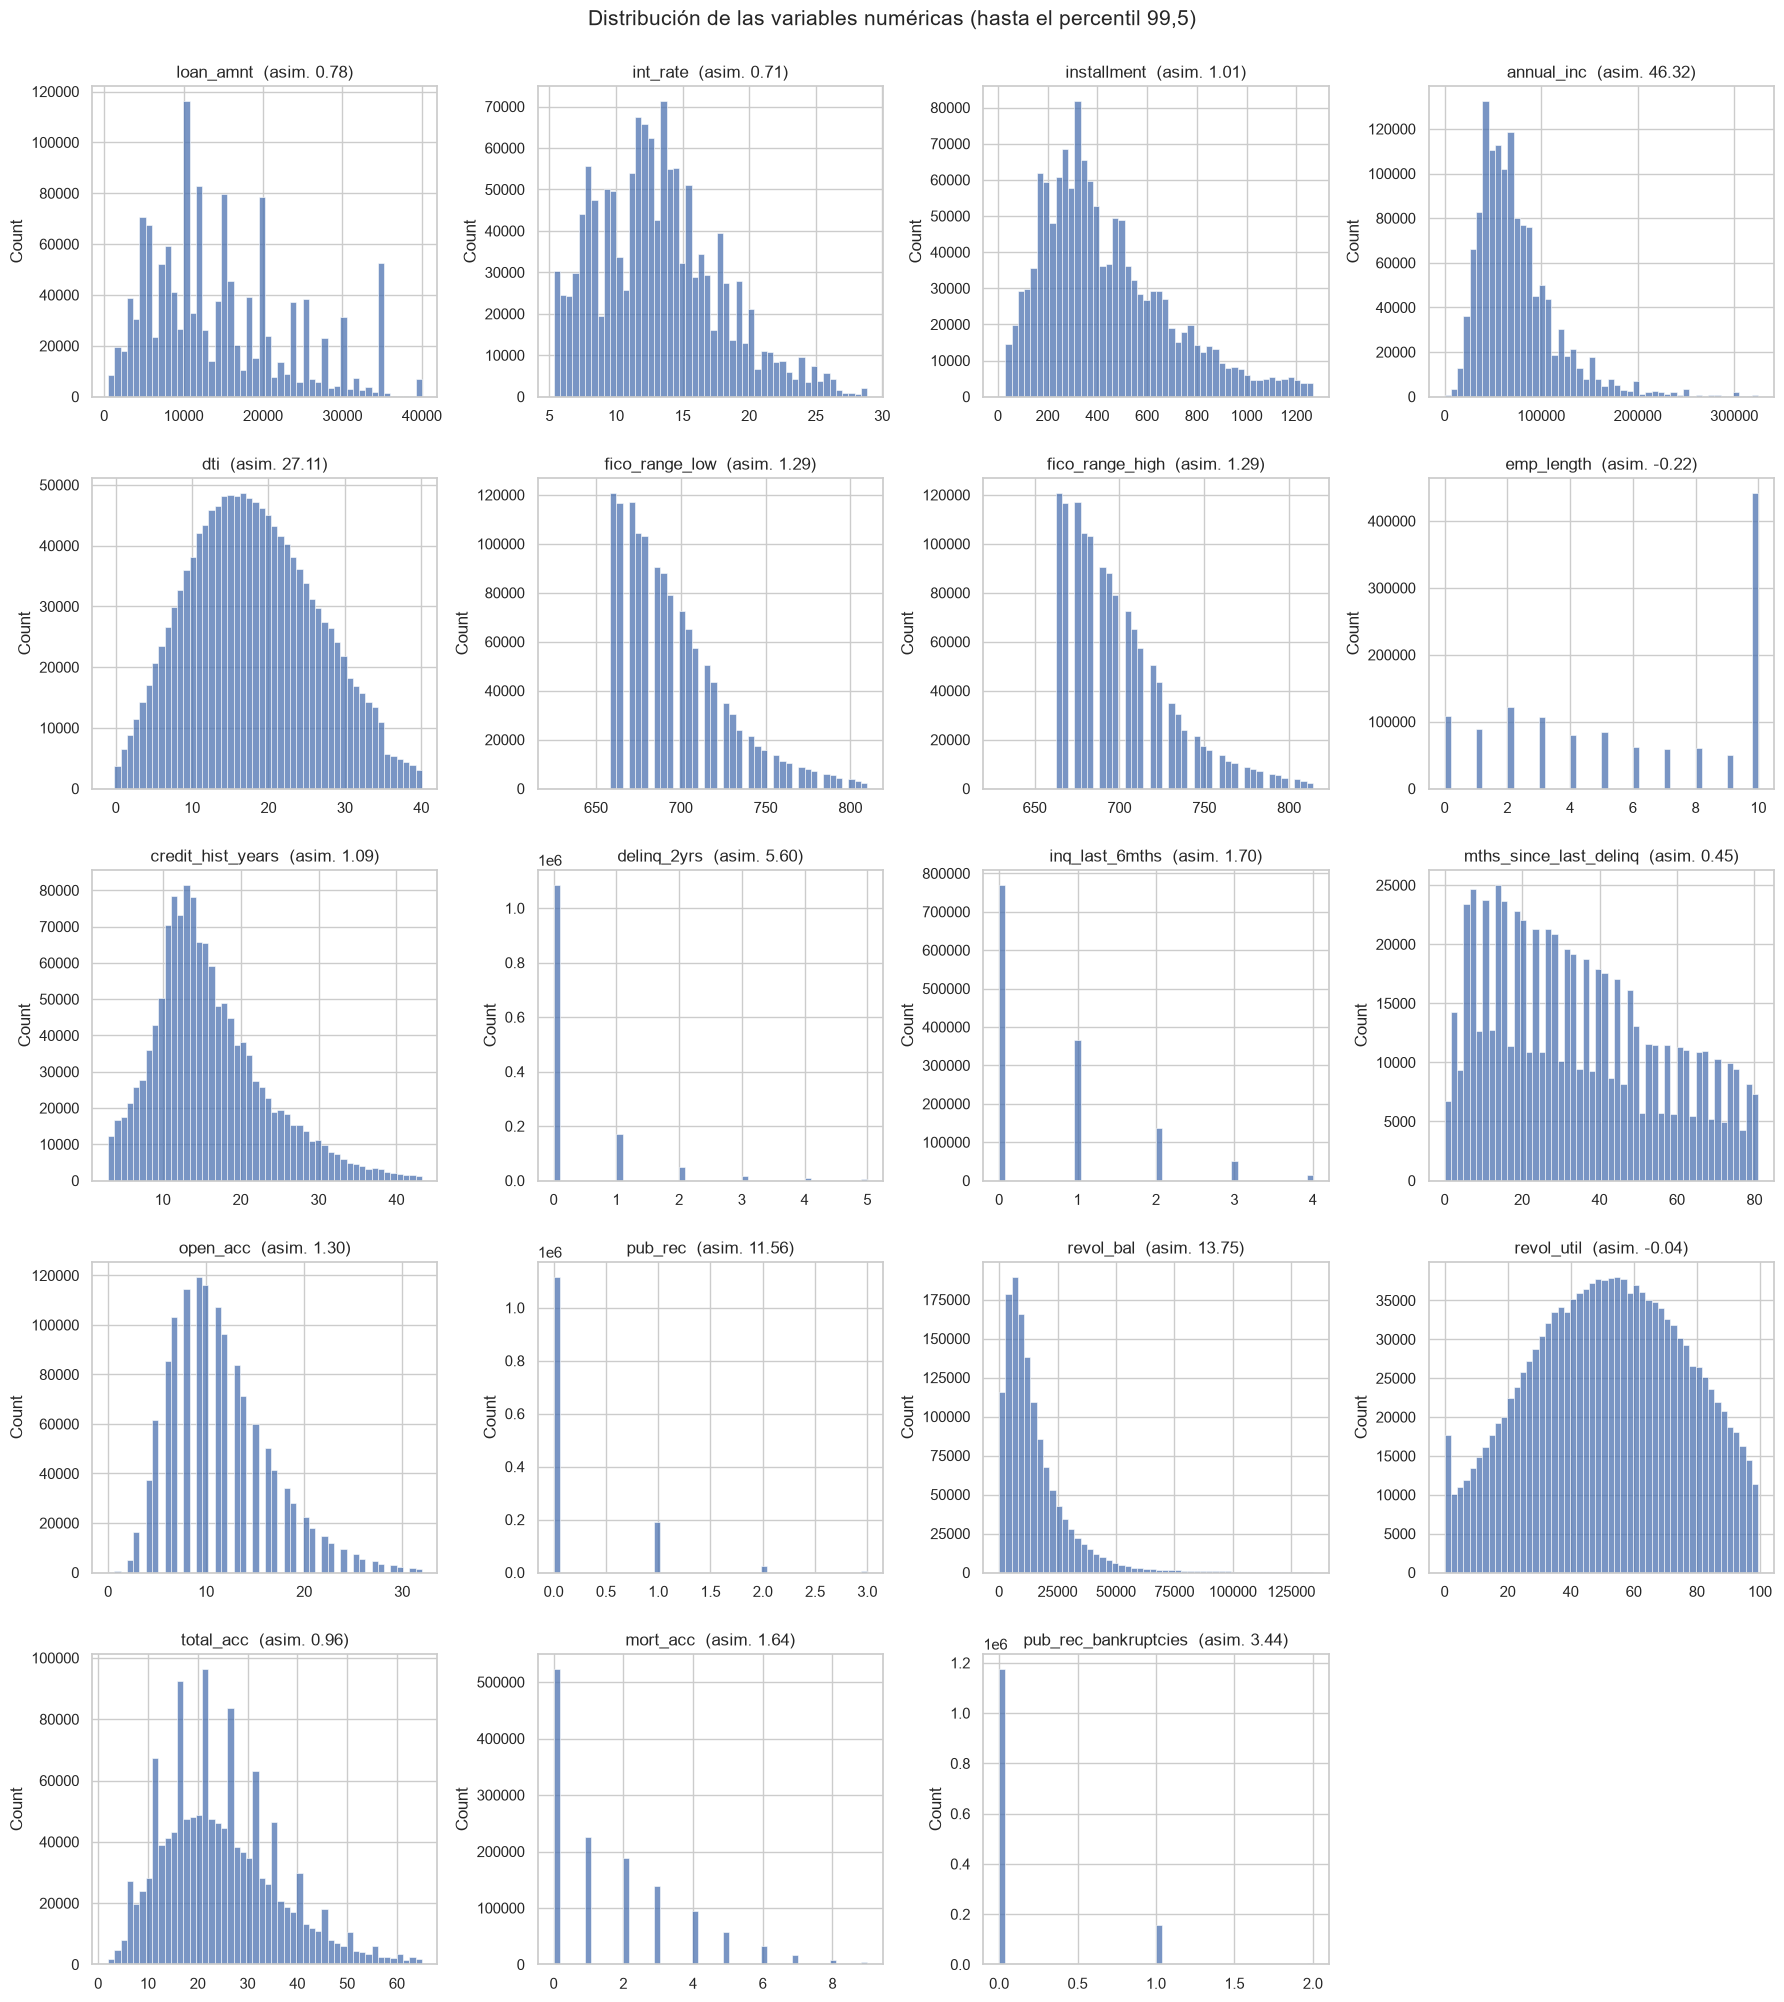

In [15]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, U.NUM_COLS):
    x = df[c].dropna()
    hi = x.quantile(0.995)
    sns.histplot(x[x <= hi], bins=50, ax=ax, color="#4C72B0")
    ax.set_title(f"{c}  (asim. {x.skew():.2f})")
    ax.set_xlabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Distribución de las variables numéricas (hasta el percentil 99,5)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

Los histogramas evidencian el carácter institucional de varias variables. `loan_amnt` concentra la masa en montos redondos (10.000, 12.000, 15.000, 20.000 y 35.000 dólares) e `int_rate` presenta picos asociados a los subgrados de Lending Club. `fico_range_*` comienza abruptamente cerca de 660 puntos, el mínimo de aceptación de la plataforma durante la mayor parte del periodo: la distribución está truncada por la política de crédito y no representa a la población general de solicitantes. `emp_length` es claramente bimodal por la acumulación en la categoría abierta "10+ años", que reúne alrededor de un tercio de los casos. Por último, `dti` y `revol_util` son aproximadamente simétricas dentro del percentil 99,5, lo que indica que su asimetría global se debe a un grupo reducido de valores extremos y no a la forma del cuerpo de la distribución.

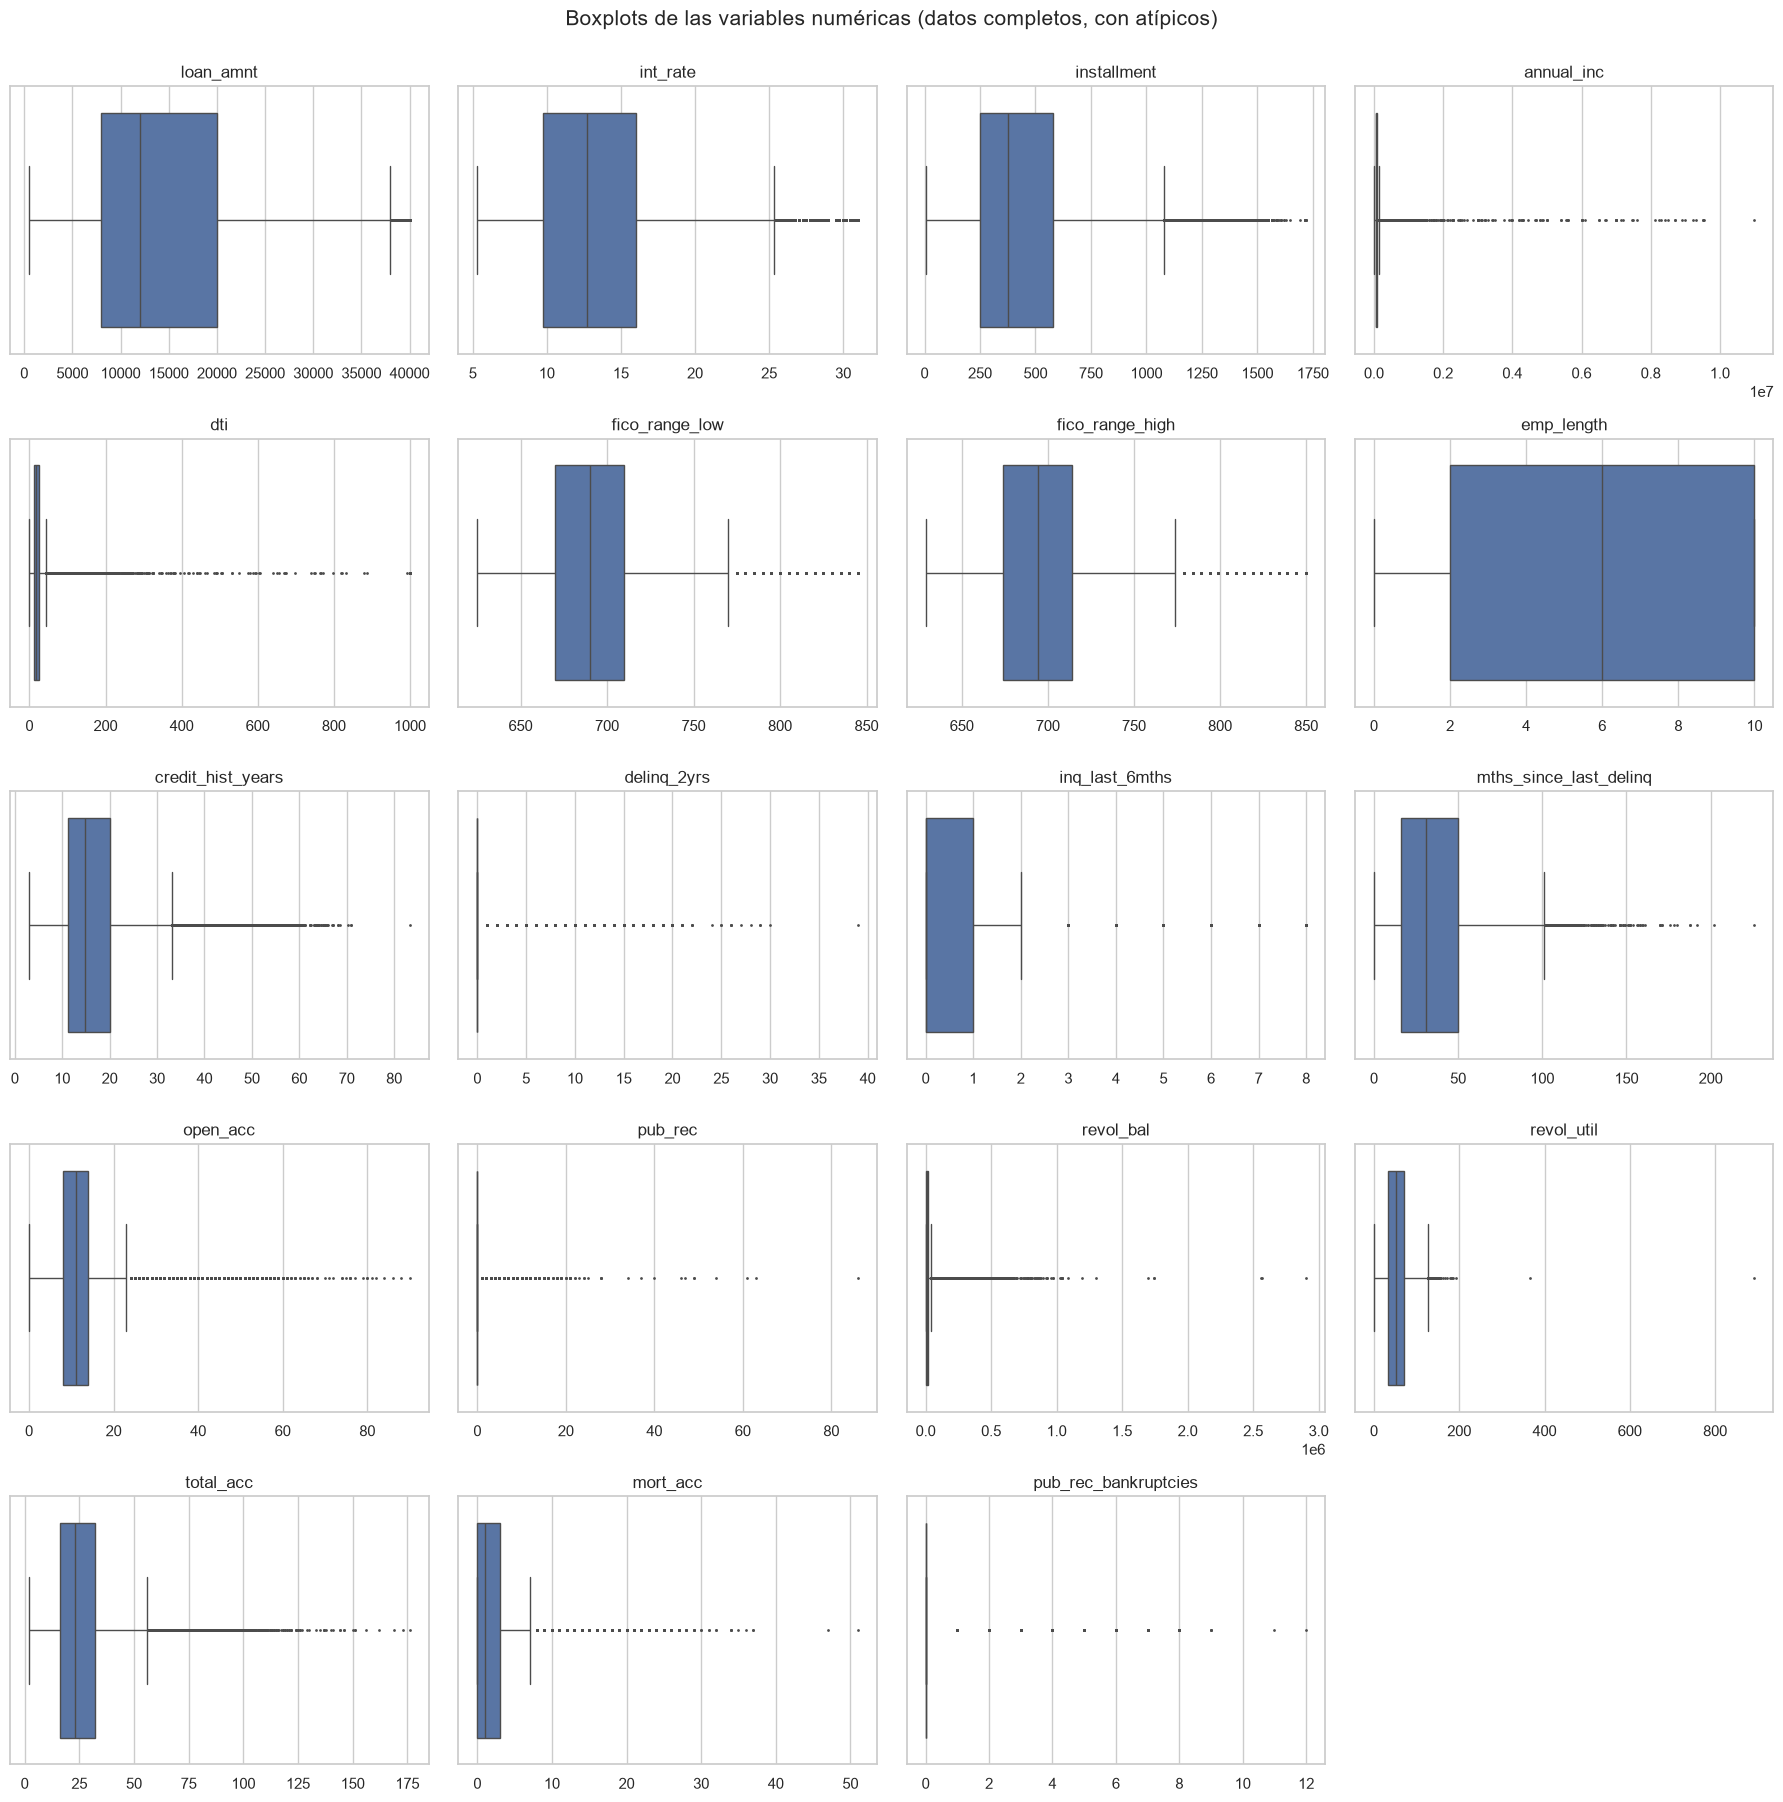

In [16]:
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
for ax, c in zip(axes.flat, U.NUM_COLS):
    sns.boxplot(x=df[c].dropna(), ax=ax, color="#4C72B0", fliersize=1)
    ax.set_title(c)
    ax.set_xlabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Boxplots de las variables numéricas (datos completos, con atípicos)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

Los diagramas de caja sobre la totalidad de los datos muestran la magnitud de esas colas. `annual_inc` alcanza 11 millones de dólares con una caja comprimida por debajo de 100 mil; `dti` y `revol_util` presentan valores aislados cercanos a 1000 y 900, y `revol_bal` llega a 2,9 millones. Aunque escasos, estos extremos dominarían la media y la varianza que estima el `StandardScaler`, y con ello el ajuste de los modelos lineales. Por ello se opta por recortar `dti` y `revol_util` a los percentiles 0,1 y 99,9 y por aplicar `log1p` a `annual_inc` y `revol_bal`. Los modelos basados en árboles son invariantes a estas transformaciones monótonas, de modo que la decisión no los perjudica.

**Normalidad.** Con $n \approx 1{,}3$ millones, cualquier prueba formal rechaza la normalidad ante desviaciones mínimas, y Shapiro-Wilk además solo es válida hasta $n = 5000$. Por eso se evalúa sobre todo la magnitud de la asimetría ($|g_1| < 0{,}5$ aproximadamente simétrica, $0{,}5$–$1$ moderada, $> 1$ severa). Como referencia se incluye:

* la prueba de D'Agostino-Pearson sobre todos los datos;
* Shapiro-Wilk sobre 5000 observaciones aleatorias, solo como ilustración.

Para cada variable se muestra también la asimetría tras aplicar `log1p` o Yeo-Johnson, para decidir si conviene transformarla.

In [17]:
rng = np.random.default_rng(U.SEED)
rows = []
for c in U.NUM_COLS:
    x = df[c].dropna().to_numpy(dtype=float)
    sw_p = stats.shapiro(rng.choice(x, 5000, replace=False)).pvalue
    dp_p = stats.normaltest(x).pvalue
    skew = stats.skew(x)
    skew_log = stats.skew(np.log1p(x)) if x.min() >= 0 else np.nan
    yj, _ = stats.yeojohnson(x)
    rows.append({"variable": c, "asimetría": skew, "asim. log1p": skew_log,
                 "asim. Yeo-Johnson": stats.skew(yj),
                 "p D'Agostino (n completo)": dp_p, "p Shapiro (n=5000)": sw_p})
norm = pd.DataFrame(rows).set_index("variable")
norm["clasificación"] = pd.cut(norm["asimetría"].abs(), [-1, 0.5, 1, np.inf],
                               labels=["≈ simétrica", "moderada", "severa"])
norm.sort_values("asimetría", key=abs, ascending=False)

,asimetría,asim. log1p,asim. Yeo-Johnson,p D'Agostino (n completo),p Shapiro (n=5000),clasificación
variable,,,,,,
annual_inc,46.318,-1.886,0.187,0.000,0.000,severa
dti,27.111,NaN,0.297,0.000,0.000,severa
revol_bal,13.750,-2.650,0.197,0.000,0.000,severa
pub_rec,11.556,2.345,1.763,0.000,0.000,severa
delinq_2yrs,5.604,2.331,1.559,0.000,0.000,severa
pub_rec_bankruptcies,3.441,2.493,2.272,0.000,0.000,severa
inq_last_6mths,1.696,0.814,0.401,0.000,0.000,severa
mort_acc,1.637,0.330,0.114,0.000,0.000,severa
open_acc,1.296,-0.133,0.001,0.000,0.000,severa


Como era previsible con $n \approx 1{,}3$ millones, ambas pruebas rechazan la normalidad en todas las variables ($p < 0{,}001$), incluso en aquellas casi simétricas como `revol_util` (asimetría de −0,04). La decisión, por tanto, se apoya en la magnitud del sesgo: trece de las diecinueve variables presentan asimetría severa. La transformación `log1p` reduce notablemente la de `annual_inc` (de 46,3 a −1,9) y la de `revol_bal` (de 13,8 a −2,7), mientras que Yeo-Johnson las lleva prácticamente a la simetría (0,19 y 0,20). Se prefiere `log1p` por su interpretabilidad y porque se reproduce de forma trivial en Spark. En los contadores discretos (`pub_rec`, `delinq_2yrs`), ninguna transformación corrige la asimetría, que obedece a la masa concentrada en cero; por ello se mantienen en su escala original.

### 1.2.2 Variables categóricas

Para cada variable se reportan la frecuencia absoluta y relativa de cada categoría y se marcan las categorías con menos del 1 % de las observaciones, candidatas a agruparse en `OTHER`.

In [18]:
from IPython.display import display

for c in U.CAT_COLS:
    vc = df[c].value_counts(dropna=False)
    t = pd.DataFrame({"n": vc, "%": 100 * vc / len(df)})
    t["< 1 %"] = np.where(t["%"] < 1, "sí", "")
    print(f"\n=== {c}: {df[c].nunique()} categorías, {df[c].isna().mean()*100:.2f}% nulos")
    display(t if len(t) <= 16 else t.head(16))


=== term: 2 categorías, 0.00% nulos


,n,%,< 1 %
term,,,
36 months,1020743,75.874,
60 months,324567,24.126,



=== grade: 7 categorías, 0.00% nulos


,n,%,< 1 %
grade,,,
B,392741,29.193,
C,381686,28.372,
A,235090,17.475,
D,200953,14.937,
E,93650,6.961,
F,32058,2.383,
G,9132,0.679,sí



=== home_ownership: 6 categorías, 0.00% nulos


...

,n,%,< 1 %
addr_state,,,
CA,196528,14.608,
TX,110169,8.189,
NY,109842,8.165,
FL,95606,7.107,
IL,51720,3.844,
NJ,48449,3.601,
PA,45522,3.384,
OH,43842,3.259,
GA,43376,3.224,



=== initial_list_status: 2 categorías, 0.00% nulos


,n,%,< 1 %
initial_list_status,,,
w,784010,58.277,
f,561300,41.723,



=== application_type: 2 categorías, 0.00% nulos


,n,%,< 1 %
application_type,,,
Individual,1319510,98.082,
Joint App,25800,1.918,


Las frecuencias revelan distribuciones muy concentradas: `debt_consolidation` y `credit_card` suman el 80 % de los propósitos, las solicitudes individuales representan el 98,1 % y las categorías `MORTGAGE` y `RENT` el 89,2 % de la tenencia de vivienda. Las categorías residuales `ANY`, `OTHER` y `NONE` de `home_ownership` reúnen apenas 478 préstamos y corresponden a códigos heredados de las primeras etapas de la plataforma, por lo que se agrupan en una sola clase.

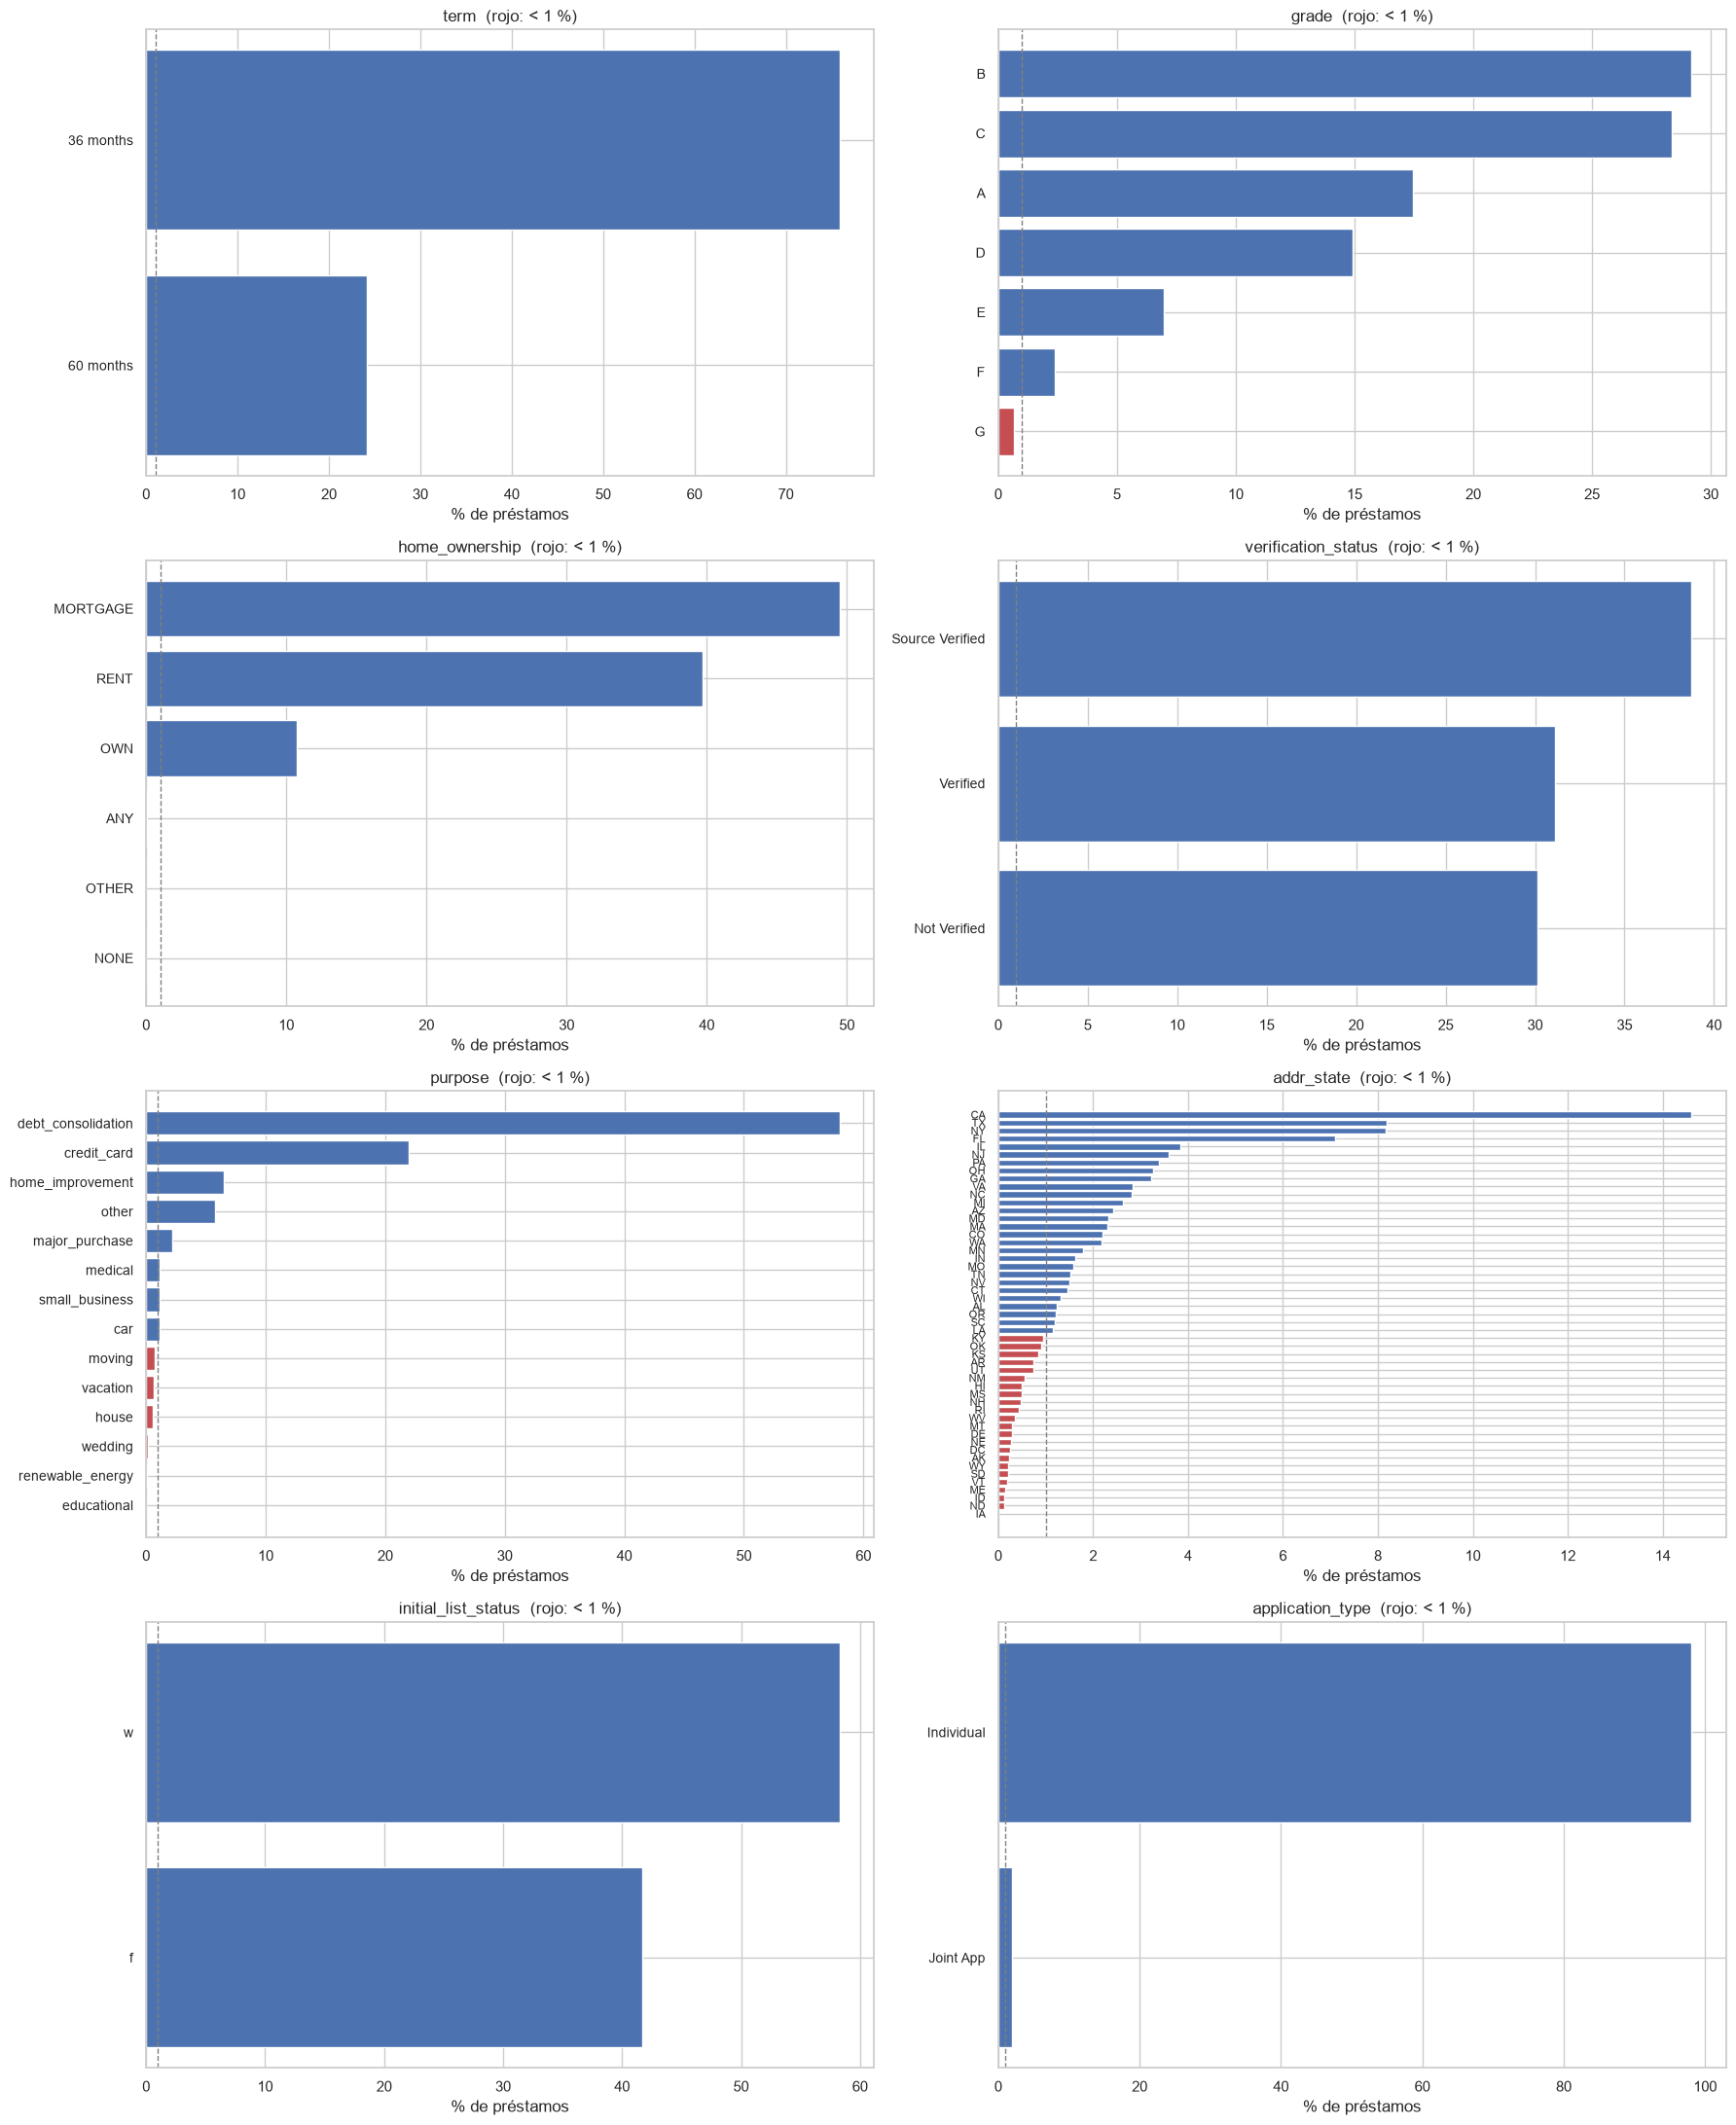

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
for ax, c in zip(axes.flat, U.CAT_COLS):
    vc = df[c].value_counts(normalize=True).mul(100).sort_values()
    colors = np.where(vc < 1, "#C44E52", "#4C72B0")
    ax.barh(vc.index.astype(str), vc.values, color=colors)
    ax.axvline(1, ls="--", c="grey", lw=1)
    ax.set_title(f"{c}  (rojo: < 1 %)")
    ax.set_xlabel("% de préstamos")
    ax.tick_params(axis="y", labelsize=8 if len(vc) > 20 else 10)
plt.tight_layout()
plt.show()

Los gráficos ponen de manifiesto la cola larga de `purpose` y de `addr_state`: seis propósitos y veintitrés estados tienen menos del 1 % de los préstamos. En `purpose` las categorías raras se agrupan en `other`. En `addr_state`, en cambio, se conservan los 51 niveles, porque la agrupación mezclaría estados con tasas de default muy distintas (sección 1.3.2) y el costo de 51 columnas binarias es moderado frente a 1,08 millones de observaciones de entrenamiento.

In [20]:
rare = {c: df[c].value_counts(normalize=True).loc[lambda s: s < 0.01].index.tolist() for c in U.CAT_COLS}
{c: v for c, v in rare.items() if v}

{'grade': ['G'],
 'home_ownership': ['ANY', 'OTHER', 'NONE'],
 'purpose': ['moving',
  'vacation',
  'house',
  'wedding',
  'renewable_energy',
  'educational'],
 'addr_state': ['KY',
  'OK',
  'KS',
  'AR',
  'UT',
  'NM',
  'HI',
  'MS',
  'NH',
  'RI',
  'WV',
  'MT',
  'DE',
  'NE',
  'DC',
  'AK',
  'WY',
  'SD',
  'VT',
  'ME',
  'ID',
  'ND',
  'IA']}

La lista confirma las categorías minoritarias identificadas en los gráficos. El grado G (0,68 %) no se agrupa, pues tiene un significado ordinal y la mayor tasa de default del conjunto. De todos modos, `grade` se excluye finalmente del modelado por su redundancia con `int_rate` (sección 1.3.3).

### 1.2.3 Variable objetivo `default`

,clase,n,%
0,Fully Paid (0),1076751,80.037
1,Charged Off (1),268559,19.963


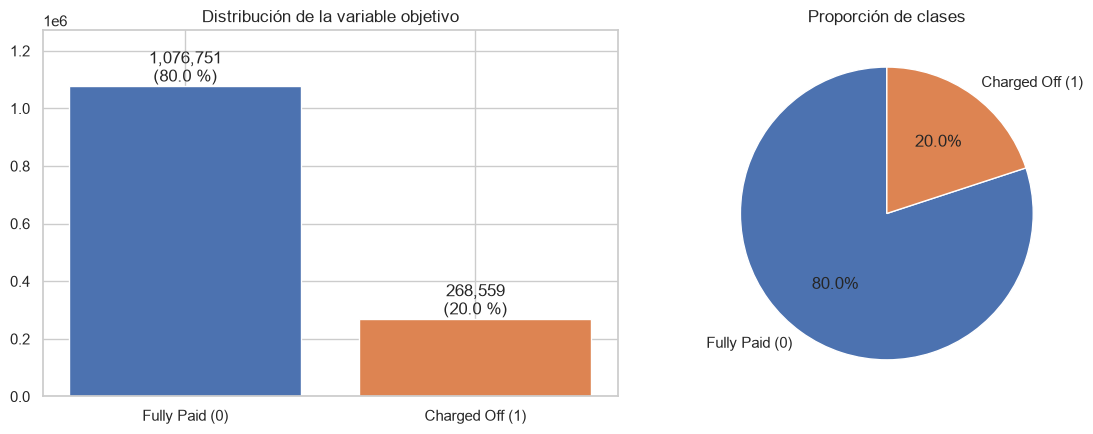

In [21]:
tc = df[U.TARGET].value_counts().sort_index()
target_tbl = pd.DataFrame({"clase": ["Fully Paid (0)", "Charged Off (1)"], "n": tc.values,
                           "%": 100 * tc.values / tc.sum()})
display(target_tbl)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(target_tbl["clase"], target_tbl["n"], color=[PALETTE[0], PALETTE[1]])
for i, (n, p) in enumerate(zip(target_tbl["n"], target_tbl["%"])):
    axes[0].text(i, n, f"{n:,}\n({p:.1f} %)", ha="center", va="bottom")
axes[0].set_ylim(0, target_tbl["n"].max() * 1.18)
axes[0].set_title("Distribución de la variable objetivo")
axes[1].pie(target_tbl["n"], labels=target_tbl["clase"], autopct="%1.1f%%",
            colors=[PALETTE[0], PALETTE[1]], startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de clases")
plt.tight_layout()
plt.show()

La variable objetivo presenta un desbalance moderado, con 19,96 % de préstamos en default (268.559 casos). No se trata de un desbalance extremo que obligue a remuestrear, pero sí basta para que la exactitud resulte engañosa (un clasificador trivial que nunca predijera default alcanzaría 80 %) y para que el umbral convencional de 0,5 produzca muy pocos positivos. En consecuencia, la partición y la validación cruzada se estratifican, la selección de modelos se basa en el ROC AUC y se reportan además el AUC-PR y el F1, métricas más sensibles al desempeño en la clase minoritaria.

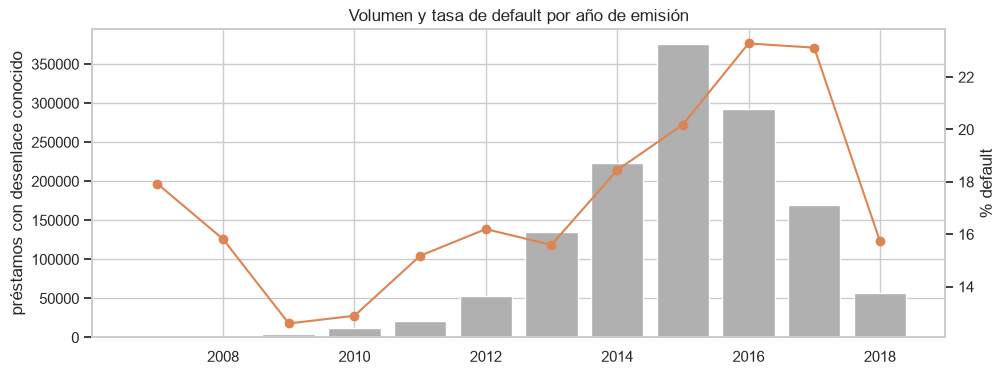

issue_d,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
size,251.000,"1,562.000","4,716.000","11,536.000","21,721.000","53,367.000","134,804.000","223,102.000","375,545.000","293,095.000","169,300.000","56,311.000"
pct_default,17.928,15.813,12.595,12.890,15.179,16.197,15.596,18.449,20.185,23.283,23.123,15.746


In [22]:
by_year = df.groupby(df["issue_d"].dt.year)[U.TARGET].agg(["size", "mean"])
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(by_year.index, by_year["size"], color="#B0B0B0")
ax1.set_ylabel("préstamos con desenlace conocido")
ax2 = ax1.twinx()
ax2.plot(by_year.index, 100 * by_year["mean"], "o-", color=PALETTE[1])
ax2.set_ylabel("% default")
ax2.grid(False)
ax1.set_title("Volumen y tasa de default por año de emisión")
plt.show()
by_year.assign(pct_default=100 * by_year["mean"]).drop(columns="mean").T

La tasa de default no es estable en el tiempo. Desciende de 17,9 % en 2007 a 12,6 % en 2009, en un periodo de volumen reducido y criterios de aprobación más estrictos tras la crisis financiera, y crece de forma sostenida hasta 23,3 % en 2016, a medida que la plataforma amplía su oferta hacia segmentos de mayor riesgo. El descenso a 15,7 % en 2018 no refleja una mejora de la cartera, sino un sesgo de selección por censura. El archivo termina en el cuarto trimestre de 2018, de modo que de las emisiones recientes solo se observan los préstamos que ya concluyeron: los prepagados anticipadamente y los que cayeron en default temprano. Por esta razón `issue_d` no se emplea como predictor. Cabe advertir además que un modelo entrenado con una partición aleatoria mezcla cohortes, y su desempeño podría deteriorarse en una validación temporal.

## 1.3 Análisis bidimensional

### 1.3.1 Variables numéricas frente a `default`

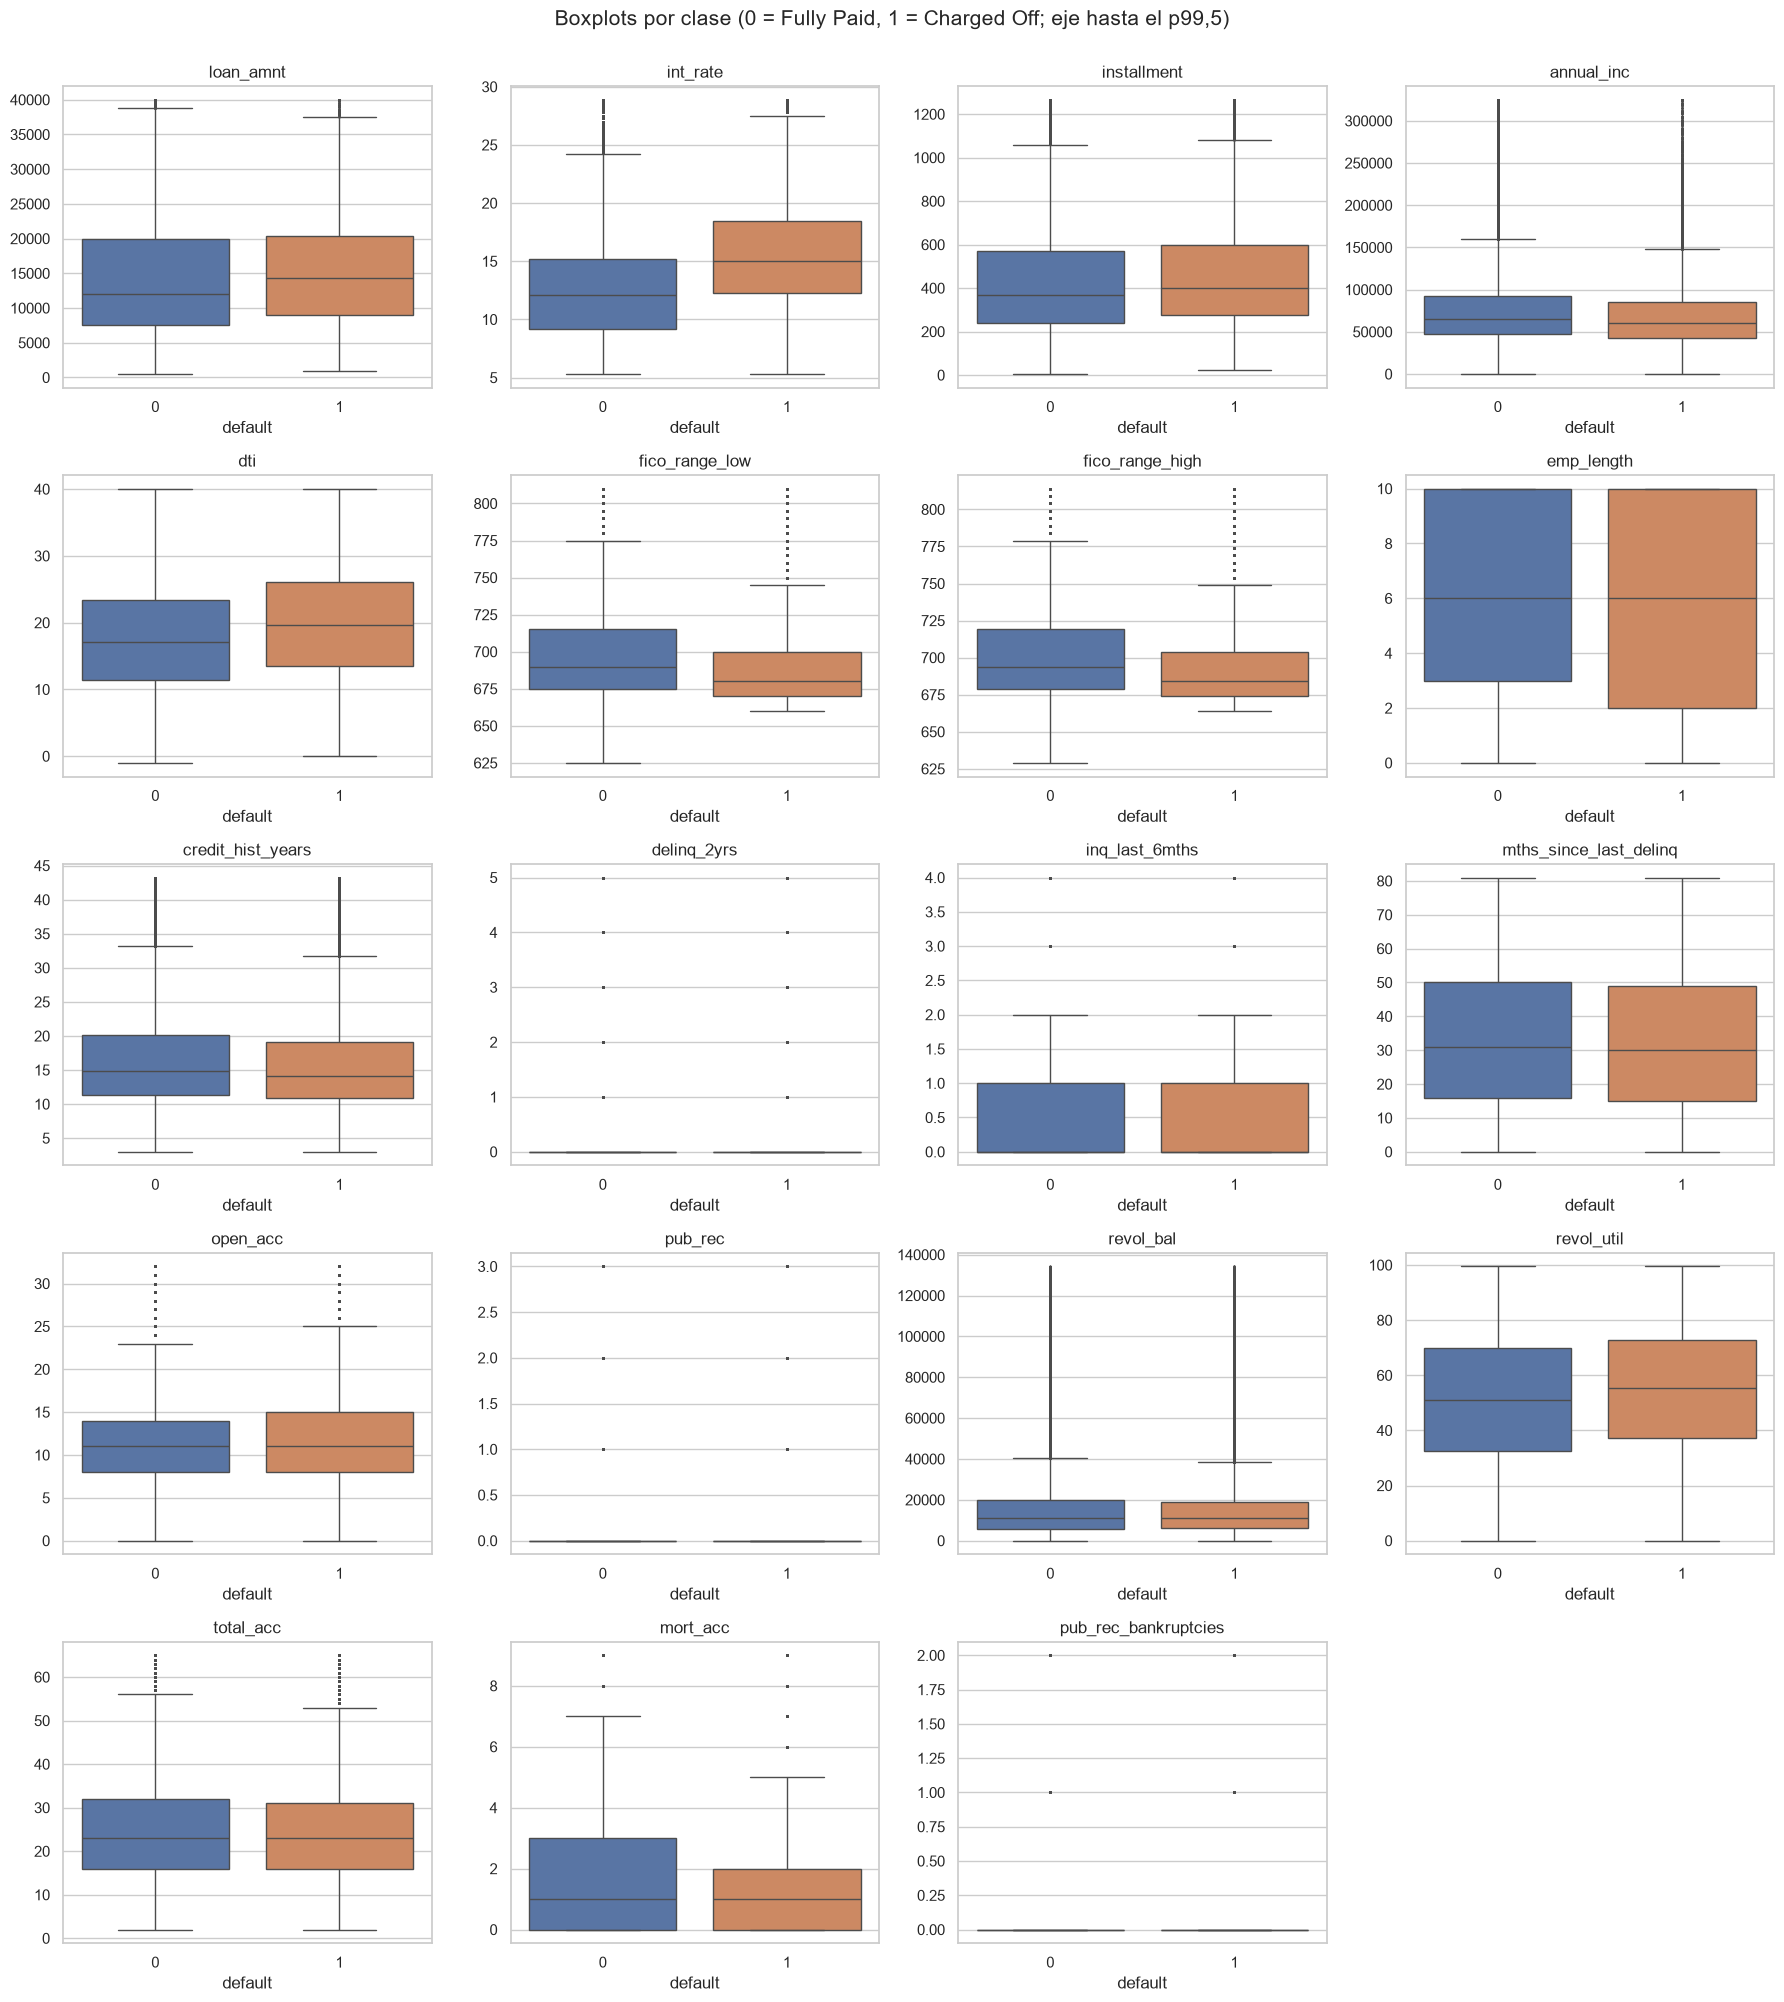

In [23]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, U.NUM_COLS):
    hi = df[c].quantile(0.995)
    sub = df.loc[df[c] <= hi, [c, U.TARGET]]
    sns.boxplot(data=sub, x=U.TARGET, y=c, ax=ax, hue=U.TARGET, palette=PALETTE, legend=False, fliersize=0.5)
    ax.set_title(c)
    ax.set_xlabel("default")
    ax.set_ylabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Boxplots por clase (0 = Fully Paid, 1 = Charged Off; eje hasta el p99,5)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

La comparación por clase muestra que la variable con mayor separación es `int_rate`: la mediana de los préstamos en default (15,05 %) se sitúa cerca del tercer cuartil de los pagados. En `fico_range_high` la caja de los defaults se desplaza hacia abajo y queda truncada en el mínimo de aceptación, y en `dti` y `revol_util` se desplaza moderadamente hacia arriba. En el resto de las variables las cajas se superponen casi por completo, lo que anticipa efectos individuales pequeños.

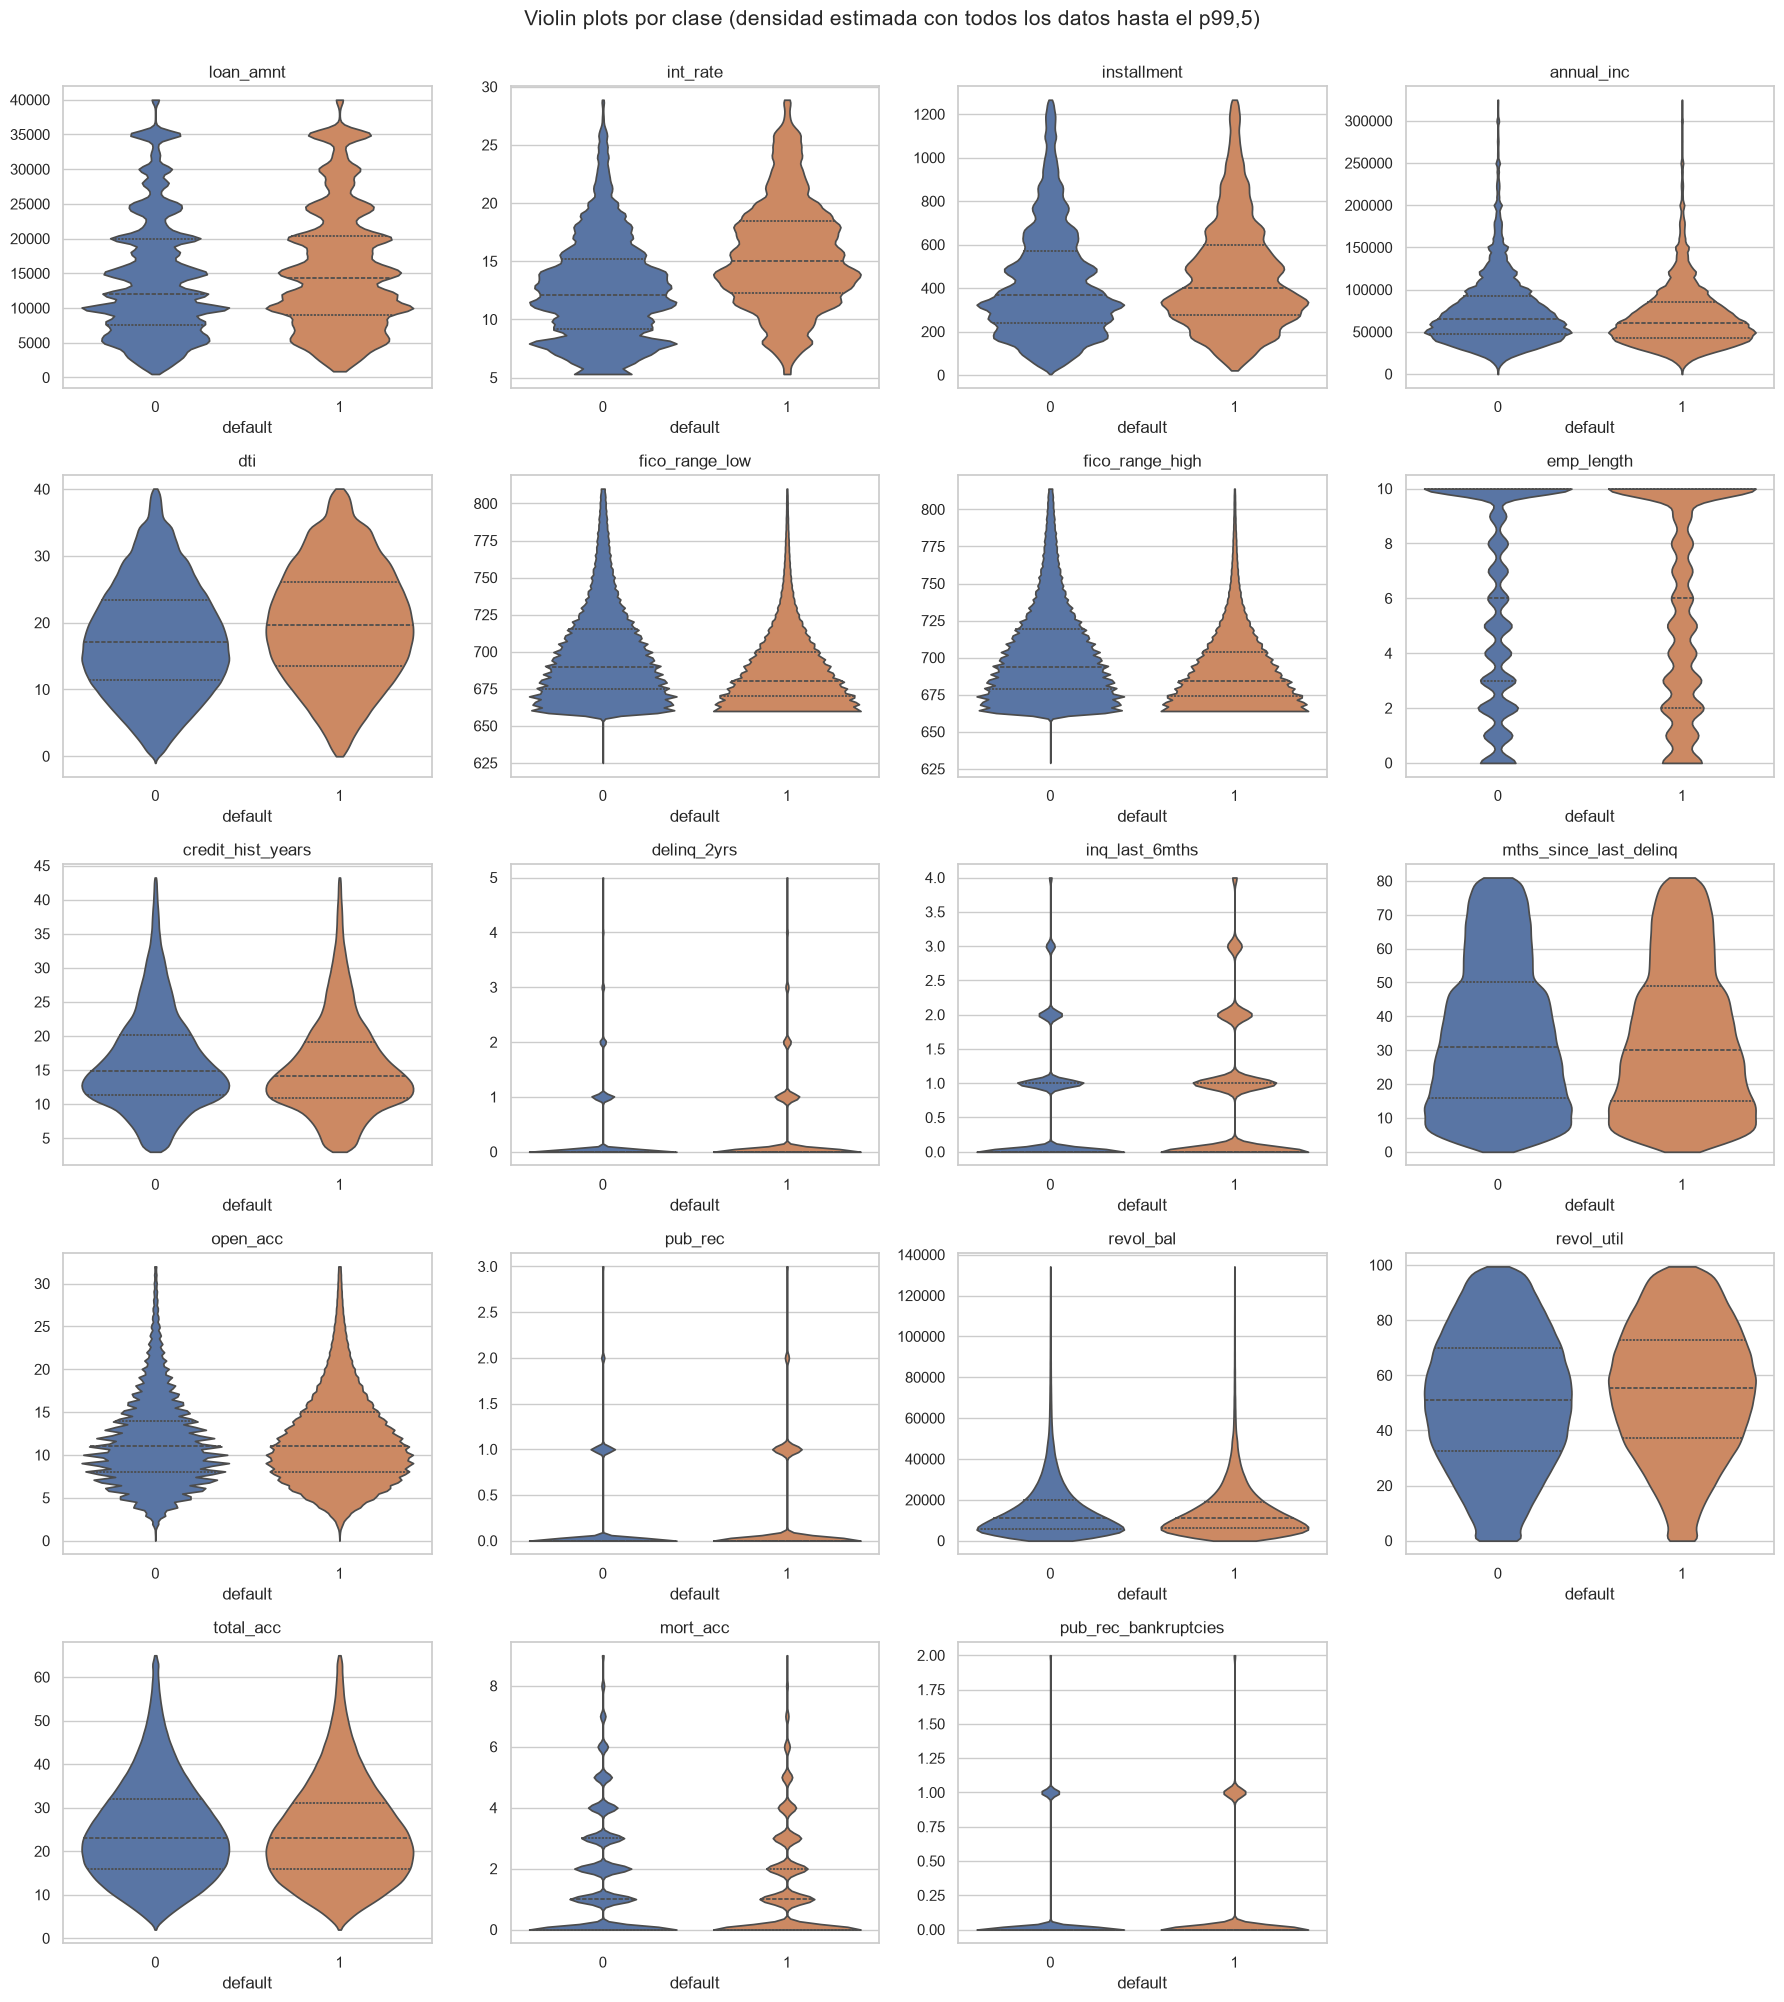

In [24]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, U.NUM_COLS):
    hi = df[c].quantile(0.995)
    sub = df.loc[df[c] <= hi, [c, U.TARGET]]
    sns.violinplot(data=sub, x=U.TARGET, y=c, ax=ax, hue=U.TARGET, palette=PALETTE, legend=False, cut=0, inner="quartile")
    ax.set_title(c)
    ax.set_xlabel("default")
    ax.set_ylabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Violin plots por clase (densidad estimada con todos los datos hasta el p99,5)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

Los violines confirman que las diferencias entre clases son de posición y no de forma. Las densidades de ambos grupos comparten la misma estructura multimodal en `loan_amnt` y `emp_length`, y solo en `int_rate` se aprecia un desplazamiento sustancial de toda la masa de probabilidad. Esta superposición generalizada indica que ningún predictor aislado separa adecuadamente las clases: se trata de un problema de discriminación intrínsecamente difícil, en el que un AUC cercano a 0,70 constituye un resultado razonable.

**Pruebas de diferencia entre clases.** Ninguna variable es normal (sección 1.2.1), así que la prueba principal es **Mann-Whitney U**. Se reporta también la **t de Welch**, que es robusta a varianzas distintas y válida asintóticamente con este $n$ por el teorema central del límite. Como tamaños de efecto se incluyen:

* la **correlación biserial por rangos**, $r_{rb} = 1 - 2U/(n_0 n_1)$;
* la **correlación punto-biserial** $r_{pb}$ con `default`.

Con más de un millón de observaciones casi cualquier diferencia resulta significativa ($p < 0{,}05$), por lo que el orden de relevancia se establece por el tamaño del efecto y no por el valor p.

In [25]:
rows = []
for c in U.NUM_COLS:
    sub = df[[c, U.TARGET]].dropna()
    x0 = sub.loc[sub[U.TARGET] == 0, c].to_numpy(float)
    x1 = sub.loc[sub[U.TARGET] == 1, c].to_numpy(float)
    mw = stats.mannwhitneyu(x1, x0, alternative="two-sided")
    tt = stats.ttest_ind(x1, x0, equal_var=False)
    rpb = stats.pointbiserialr(sub[U.TARGET], sub[c])
    rows.append({
        "variable": c, "media Fully Paid": x0.mean(), "media Charged Off": x1.mean(),
        "Δ medias (1−0)": x1.mean() - x0.mean(), "mediana 0": np.median(x0), "mediana 1": np.median(x1),
        "p Welch t": tt.pvalue, "p Mann-Whitney": mw.pvalue,
        "r rango-biserial": 1 - 2 * (len(x0) * len(x1) - mw.statistic) / (len(x0) * len(x1)),
        "r punto-biserial": rpb.statistic,
    })
biv_num = pd.DataFrame(rows).set_index("variable").sort_values("r punto-biserial", key=abs, ascending=False)
with pd.option_context("display.float_format", lambda v: f"{v:,.4g}"):
    display(biv_num)

,media Fully Paid,media Charged Off,Δ medias (1−0),mediana 0,mediana 1,p Welch t,p Mann-Whitney,r rango-biserial,r punto-biserial
variable,,,,,,,,,
int_rate,12.62,15.71,3.087,12.23,15.05,0,0,0.367,0.2588
fico_range_low,698.3,687.9,-10.41,690,680,0,0,-0.1868,-0.1307
fico_range_high,702.3,691.9,-10.41,694,684,0,0,-0.1868,-0.1307
dti,17.81,20.17,2.36,17.11,19.76,0,0,0.1542,0.08451
mort_acc,1.746,1.371,-0.3754,1,1,0,0,-0.1118,-0.07529
loan_amnt,1.413e+04,1.557e+04,"1,431",1.2e+04,1.435e+04,0,0,0.1022,0.0656
inq_last_6mths,0.6244,0.778,0.1536,0,0,0,0,0.08351,0.06545
revol_util,51.07,54.76,3.684,51.3,55.5,0,0,0.08591,0.06005
installment,431.3,465.1,33.82,368.3,402.8,0,0,0.08628,0.0517


Todas las diferencias resultan estadísticamente significativas (el mayor valor p es del orden de $10^{-23}$), lo que ilustra la trivialidad de la significancia con muestras de este tamaño. El tamaño del efecto, en cambio, ordena con claridad las variables. `int_rate` domina con amplitud (correlación biserial por rangos de 0,37 y punto-biserial de 0,26), seguida de `fico_range` (−0,19 y −0,13) y de `dti` (0,15 y 0,08). `mort_acc`, `loan_amnt`, `inq_last_6mths`, `revol_util`, `installment` y `annual_inc` forman un segundo grupo con efectos pequeños ($|r_{pb}|$ entre 0,04 y 0,08), y el resto tiene efectos despreciables ($|r_{pb}| < 0{,}035$). La coincidencia de signo y orden entre la correlación biserial por rangos, que no supone normalidad, y la punto-biserial indica que las conclusiones son robustas al supuesto distribucional.

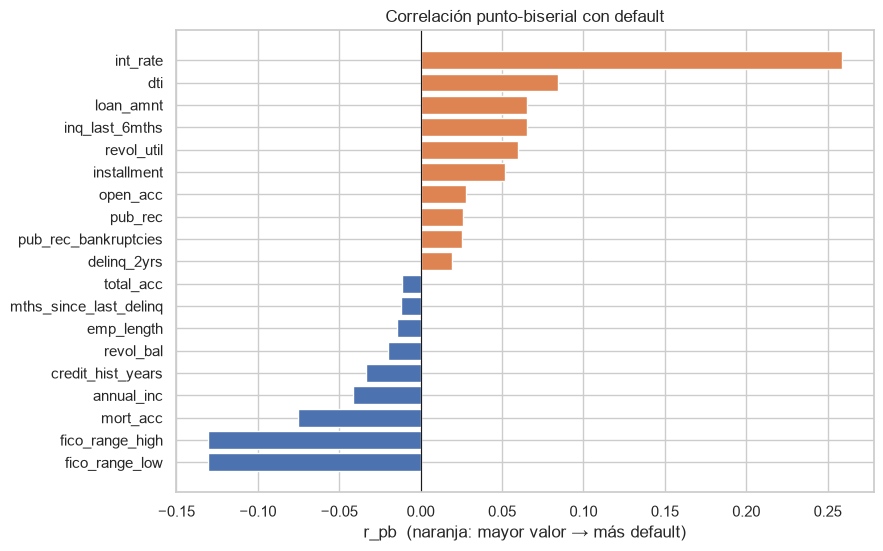

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
s = biv_num["r punto-biserial"].sort_values()
ax.barh(s.index, s.values, color=np.where(s > 0, PALETTE[1], PALETTE[0]))
ax.axvline(0, c="k", lw=0.8)
ax.set_title("Correlación punto-biserial con default")
ax.set_xlabel("r_pb  (naranja: mayor valor → más default)")
plt.show()

El gráfico sintetiza la dirección de los efectos. Un mayor costo del crédito, mayor endeudamiento, más consultas recientes, una mayor utilización del cupo revolvente y un monto solicitado más alto se asocian con más default. Un mejor puntaje FICO, más créditos hipotecarios, un ingreso mayor y un historial crediticio más largo actúan como factores protectores. Estos signos son coherentes con la teoría del riesgo de crédito, lo que respalda la validez de los datos.

### 1.3.2 Variables categóricas frente a `default`

Para cada variable se calculan la tasa de default por categoría (tabla de contingencia normalizada), la prueba chi-cuadrado de independencia y la V de Cramér como tamaño del efecto.

In [27]:
rows = []
for c in U.CAT_COLS:
    ct = pd.crosstab(df[c], df[U.TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({"variable": c, "categorías": ct.shape[0], "chi2": chi2, "gl": dof, "p-value": p,
                 "V de Cramér": U.cramers_v(df[c], df[U.TARGET])})
biv_cat = pd.DataFrame(rows).set_index("variable").sort_values("V de Cramér", ascending=False)
with pd.option_context("display.float_format", lambda v: f"{v:,.4g}"):
    display(biv_cat)

,categorías,chi2,gl,p-value,V de Cramér
variable,,,,,
grade,7,9.228e+04,6,0,0.2619
term,2,4.172e+04,1,0,0.1761
verification_status,3,1.139e+04,2,0,0.09199
home_ownership,6,"6,743",5,0,0.07077
purpose,14,"4,144",13,0,0.05541
addr_state,51,"3,404",50,0,0.04993
application_type,2,352.1,1,1.478e-78,0.01616
initial_list_status,2,71.32,1,3.041e-17,0.007232


La prueba chi-cuadrado rechaza la independencia en las ocho variables, pero la V de Cramér distingue tres niveles de asociación: fuerte en `grade` (0,26) y moderada en `term` (0,18); débil en `verification_status`, `home_ownership`, `purpose` y `addr_state` (entre 0,05 y 0,09), y prácticamente nula en `application_type` e `initial_list_status` (menos de 0,02). En esta última, pese a un valor p de $3 \times 10^{-17}$, la diferencia entre las tasas de default de sus dos categorías es inferior a un punto porcentual, sin relevancia práctica alguna.

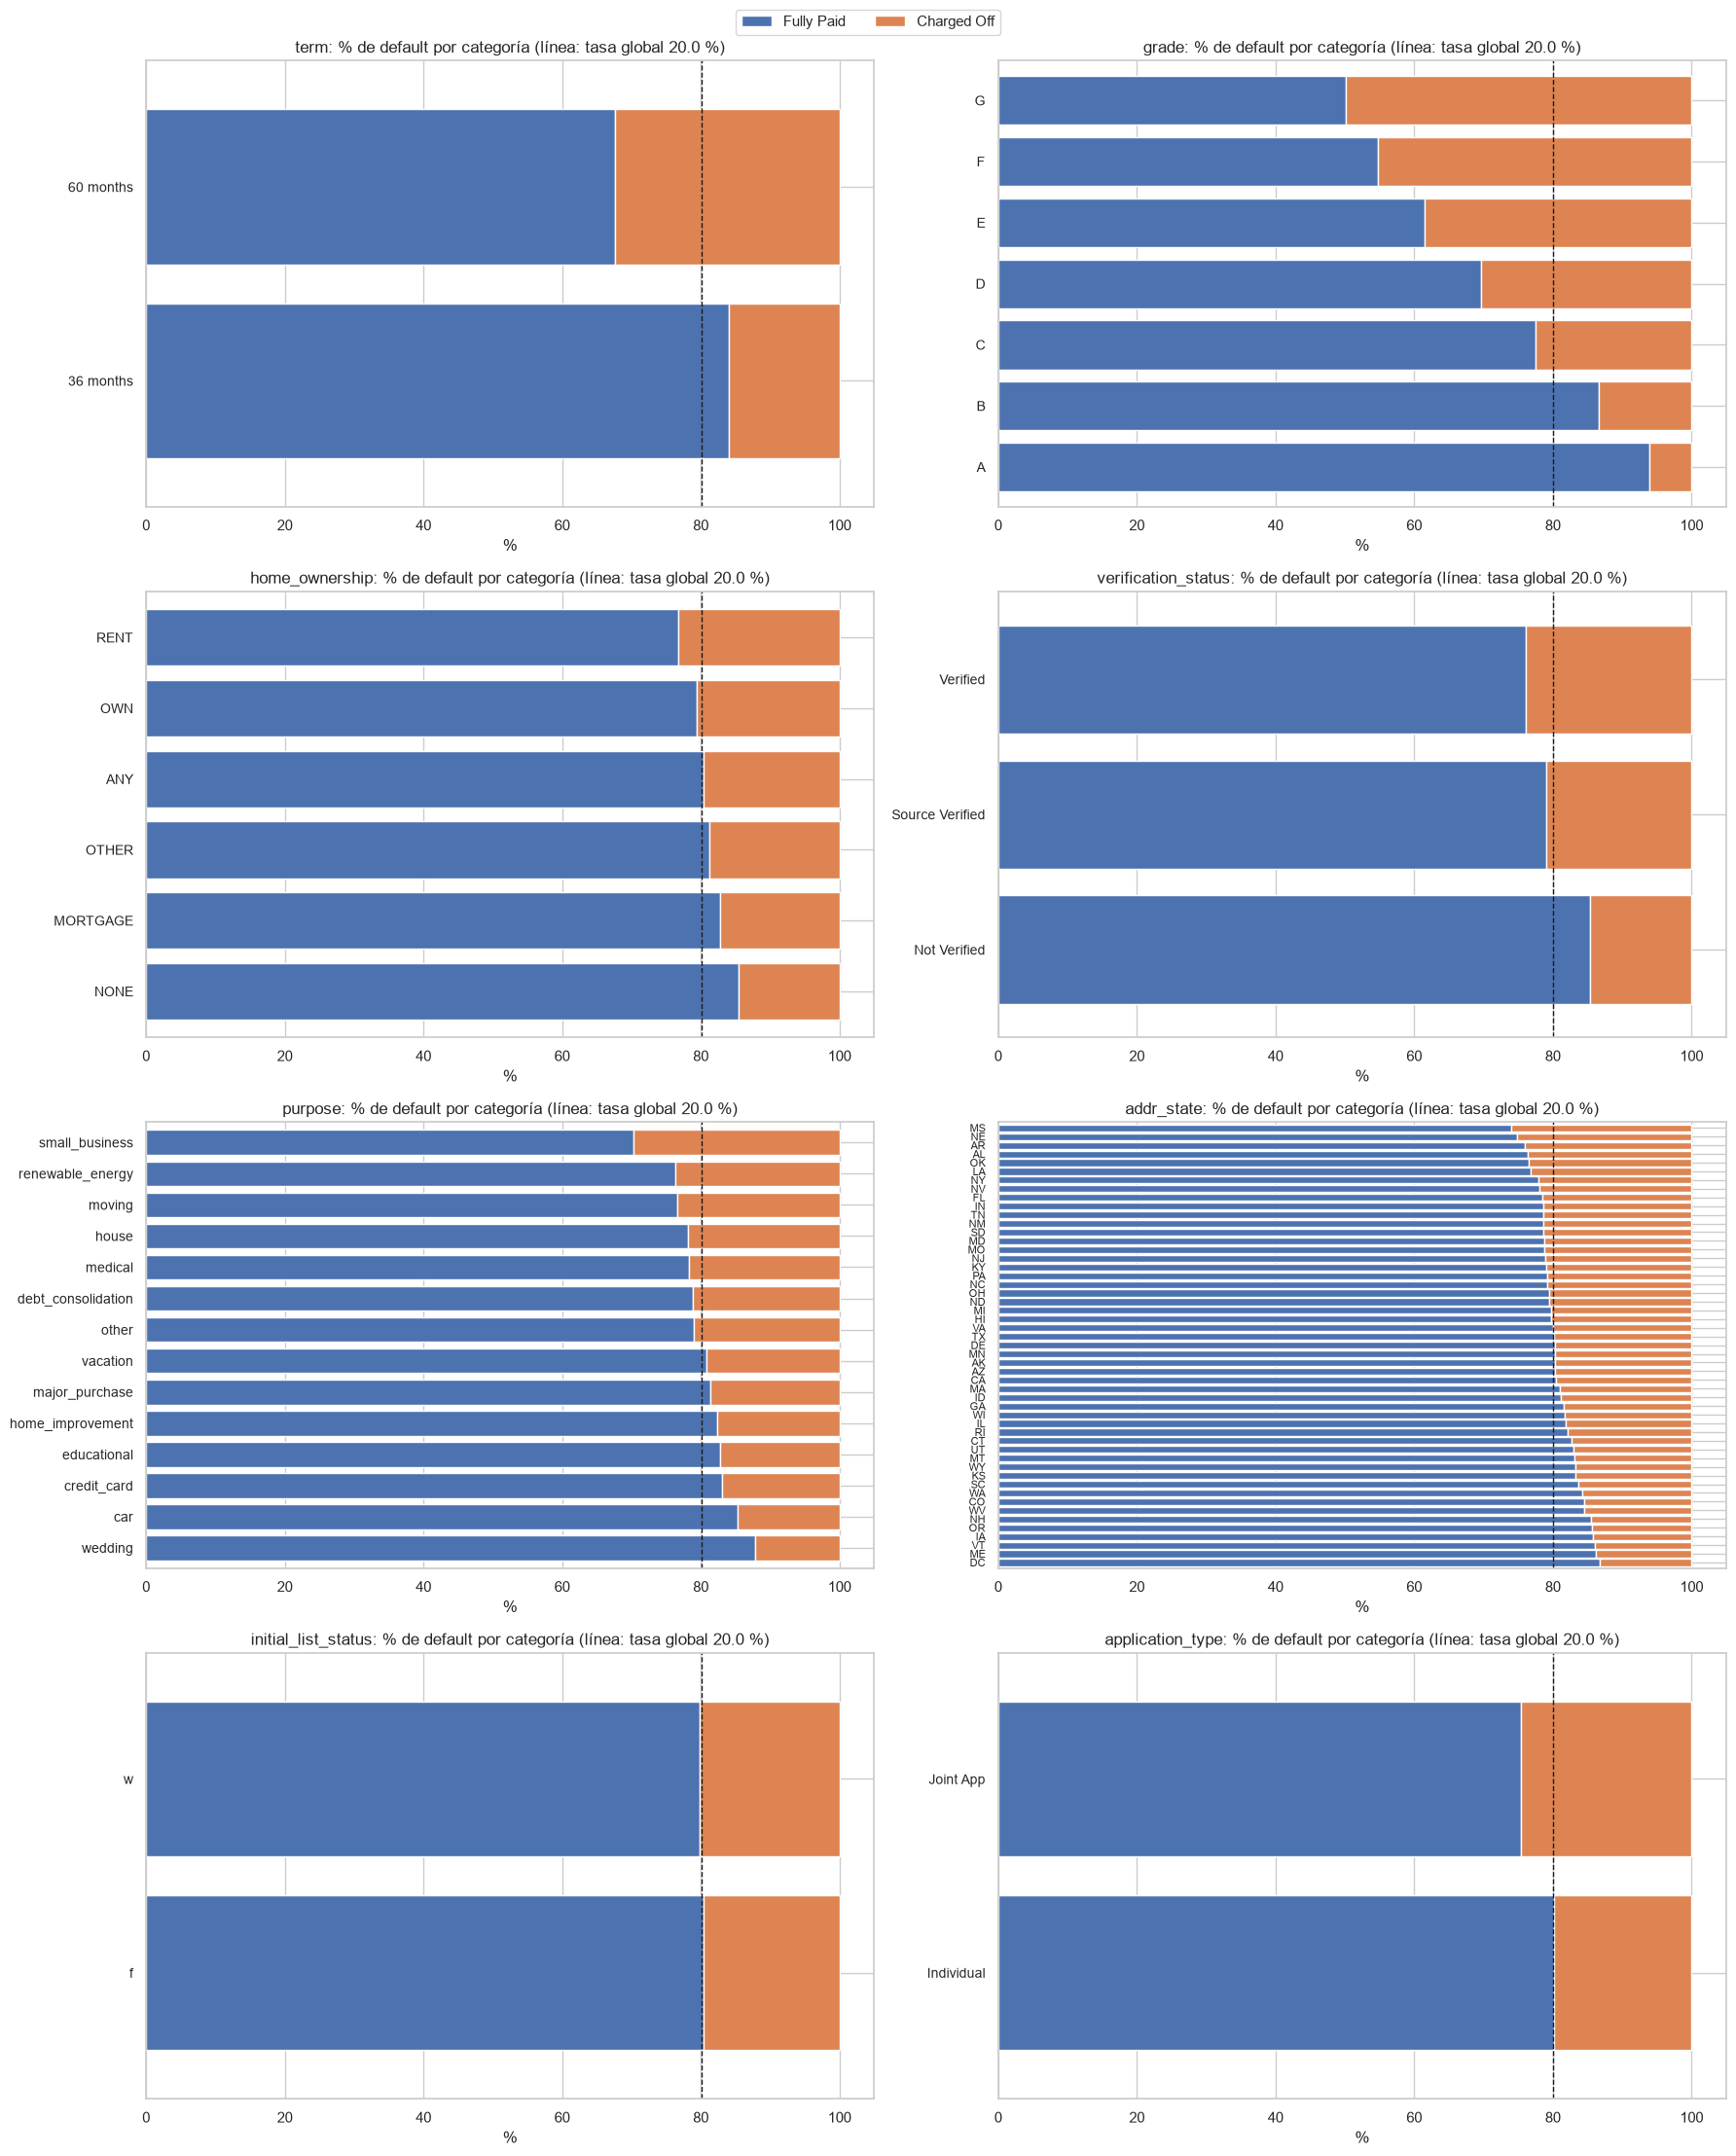

In [28]:
base_rate = df[U.TARGET].mean() * 100
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
for ax, c in zip(axes.flat, U.CAT_COLS):
    ct = pd.crosstab(df[c], df[U.TARGET], normalize="index").mul(100).sort_values(1)
    ct.plot.barh(stacked=True, ax=ax, color=[PALETTE[0], PALETTE[1]], width=0.8, legend=False)
    ax.axvline(100 - base_rate, c="k", ls="--", lw=1)
    ax.set_title(f"{c}: % de default por categoría (línea: tasa global {base_rate:.1f} %)")
    ax.set_xlabel("%")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8 if ct.shape[0] > 20 else 10)
handles, _ = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, ["Fully Paid", "Charged Off"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.show()

Las barras apiladas muestran el gradiente de riesgo más nítido del conjunto: la tasa de default crece de forma monótona desde cerca del 6 % en el grado A hasta el 50 % en el G, y en los préstamos a 60 meses es 1,6 veces la tasa global. Resulta contraintuitivo que los préstamos con ingresos verificados presenten más default (23,9 %) que los no verificados. La explicación más plausible es un sesgo de selección: la plataforma exige la verificación precisamente a los solicitantes de mayor riesgo o de mayor monto. En `purpose` destaca `small_business` (29,7 %), muy por encima del promedio, mientras que `wedding` y `car` quedan por debajo. En `addr_state` las tasas oscilan aproximadamente entre 13 % y 26 %, con Misisipi, Nebraska y Arkansas en el extremo superior.

In [29]:
# Categorías con al menos 1000 préstamos y tasa de default más alta
rows = []
for c in U.CAT_COLS:
    g = df.groupby(c, observed=True)[U.TARGET].agg(["size", "mean"])
    g = g[g["size"] >= 1000]
    for cat, r in g.iterrows():
        rows.append({"variable": c, "categoría": cat, "n": int(r["size"]), "% default": 100 * r["mean"],
                     "riesgo relativo": r["mean"] / (base_rate / 100)})
risk = pd.DataFrame(rows).sort_values("% default", ascending=False)
risk.head(15)

,variable,categoría,n,% default,riesgo relativo
8,grade,G,9132,49.934,2.501
7,grade,F,32058,45.202,2.264
6,grade,E,93650,38.478,1.928
1,term,60 months,324567,32.445,1.625
5,grade,D,200953,30.382,1.522
24,purpose,small_business,15416,29.709,1.488
51,addr_state,MS,6588,26.078,1.306
55,addr_state,NE,3586,25.181,1.261
80,application_type,Joint App,25800,24.589,1.232
29,addr_state,AR,10047,24.087,1.207


Restringiendo el análisis a categorías con al menos mil préstamos, las de mayor riesgo relativo son los grados G, F y E (2,5, 2,3 y 1,9 veces la tasa global), el plazo de 60 meses (1,6), el grado D (1,5) y el propósito `small_business` (1,5). Que los primeros lugares correspondan a `grade` y `term` confirma que la evaluación de riesgo de la propia plataforma concentra buena parte de la información predictiva disponible.

### 1.3.3 Relaciones entre variables independientes (multicolinealidad)

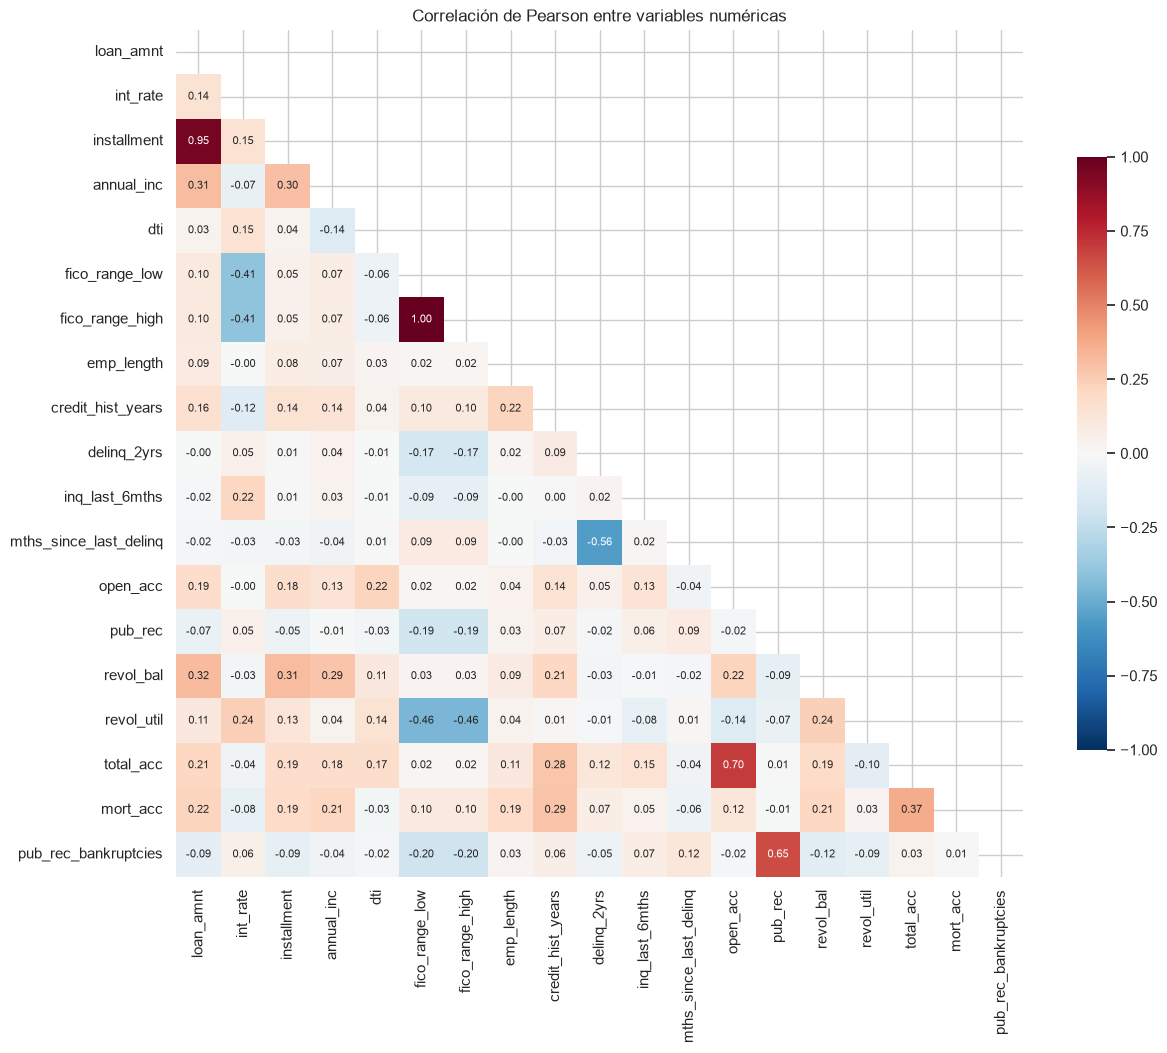

In [30]:
corr = df[U.NUM_COLS].corr(method="pearson")
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlación de Pearson entre variables numéricas")
plt.show()

La matriz de correlación de Pearson muestra que la mayoría de los pares de variables numéricas presenta correlaciones bajas ($|r| < 0{,}3$), lo que indica que aportan información en gran medida complementaria. Las excepciones se concentran en pares con una relación estructural evidente, que se detallan en la tabla siguiente.

In [31]:
pairs = (corr.where(~mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
pairs["|r|"] = pairs["r"].abs()
pairs.sort_values("|r|", ascending=False).head(10)

,var_1,var_2,r,|r|
20,fico_range_high,fico_range_low,1.000,1.000
1,installment,loan_amnt,0.953,0.953
132,total_acc,open_acc,0.701,0.701
166,pub_rec_bankruptcies,pub_rec,0.650,0.650
64,mths_since_last_delinq,delinq_2yrs,-0.556,0.556
110,revol_util,fico_range_low,-0.460,0.460
111,revol_util,fico_range_high,-0.460,0.460
11,fico_range_low,int_rate,-0.405,0.405
16,fico_range_high,int_rate,-0.405,0.405
152,mort_acc,total_acc,0.368,0.368


Los dos primeros pares son redundancias casi perfectas de origen mecánico: `fico_range_low` y `fico_range_high` difieren en una constante de cuatro puntos ($r = 1{,}00$), e `installment` es una función determinista de `loan_amnt`, `int_rate` y `term` ($r = 0{,}95$). Por ello se conserva una sola variable de cada par (`fico_range_high` y `loan_amnt`). Las correlaciones entre `total_acc` y `open_acc` (0,70) y entre `pub_rec` y `pub_rec_bankruptcies` (0,65) rozan el umbral de multicolinealidad, pero cada variable aporta un matiz distinto (cuentas históricas frente a vigentes; registros públicos en general frente a quiebras). Por eso se mantienen, y la regularización L2 de los modelos lineales controla la posible inestabilidad de los coeficientes.

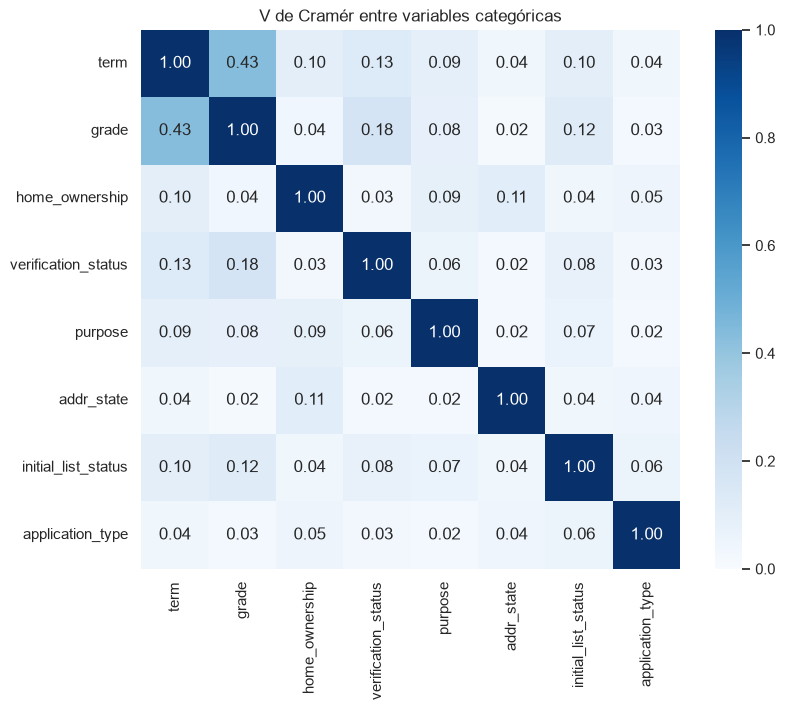

In [32]:
cv = pd.DataFrame(np.eye(len(U.CAT_COLS)), index=U.CAT_COLS, columns=U.CAT_COLS)
for i, a in enumerate(U.CAT_COLS):
    for b in U.CAT_COLS[i + 1:]:
        cv.loc[a, b] = cv.loc[b, a] = U.cramers_v(df[a], df[b])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cv, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("V de Cramér entre variables categóricas")
plt.show()

Entre las variables categóricas, la única asociación apreciable es la de `term` con `grade` ($V = 0{,}43$): los préstamos a 60 meses se concentran en los grados de menor calidad. El resto de los pares presenta valores de V inferiores a 0,2, de modo que no existe una redundancia que justifique excluir variables categóricas por este motivo.

**Asociación entre variables numéricas y categóricas.** El enunciado menciona redundancias del tipo `fico_range_high` ~ `int_rate`. Por eso también se revisa la asociación entre las variables numéricas y la categórica más ligada al riesgo, `grade`, mediante la razón de correlación $\eta$, que es la proporción de la varianza de la variable numérica explicada por la categoría.

In [33]:
def eta(cat, num):
    d = pd.DataFrame({"c": cat, "x": num}).dropna()
    m = d.groupby("c", observed=True)["x"].agg(["mean", "size"])
    ss_b = (m["size"] * (m["mean"] - d["x"].mean()) ** 2).sum()
    return np.sqrt(ss_b / ((d["x"] - d["x"].mean()) ** 2).sum())

eta_tbl = pd.DataFrame({c: [eta(df[g], df[c]) for g in ["grade", "term"]] for c in U.NUM_COLS},
                       index=["η con grade", "η con term"]).T.sort_values("η con grade", ascending=False)
eta_tbl.head(8)

,η con grade,η con term
int_rate,0.953,0.417
fico_range_low,0.485,0.002
fico_range_high,0.485,0.002
revol_util,0.273,0.064
inq_last_6mths,0.211,0.021
installment,0.171,0.143
loan_amnt,0.165,0.381
dti,0.151,0.059


La razón de correlación confirma la redundancia más importante del conjunto: `grade` explica el 91 % de la varianza de `int_rate` ($\eta = 0{,}953$, $\eta^2 = 0{,}91$), porque la tasa de interés se asigna a partir del grado y el subgrado. También explica una fracción menor de `fico_range` ($\eta = 0{,}49$) y de `revol_util` ($\eta = 0{,}27$). Como `int_rate` contiene la información de `grade` con mayor resolución, se conserva `int_rate` y se excluye `grade` del modelado.

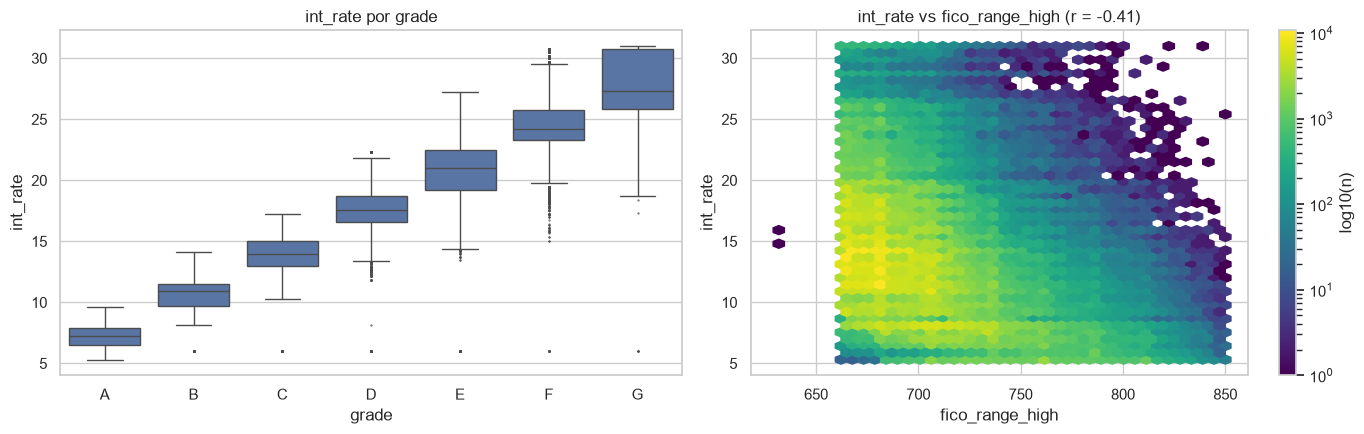

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="grade", y="int_rate", order=sorted(df["grade"].cat.categories), ax=axes[0],
            color="#4C72B0", fliersize=0.5)
axes[0].set_title("int_rate por grade")
hb = axes[1].hexbin(df["fico_range_high"], df["int_rate"], gridsize=40, bins="log", cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=axes[1], label="log10(n)")
axes[1].set_xlabel("fico_range_high")
axes[1].set_ylabel("int_rate")
axes[1].set_title(f"int_rate vs fico_range_high (r = {corr.loc['int_rate', 'fico_range_high']:.2f})")
plt.tight_layout()
plt.show()

El diagrama de caja muestra la escalera de tasas por grado, con rangos que apenas se solapan entre grados adyacentes. El diagrama hexagonal evidencia la relación negativa entre FICO e `int_rate` ($r = -0{,}41$): los puntajes altos obtienen tasas bajas, aunque con una dispersión considerable para un mismo puntaje. Esa dispersión indica que la tasa incorpora información adicional al FICO, como el plazo, el endeudamiento o el historial, y por ello ambas variables se conservan.

### 1.3.4 Visualizaciones avanzadas

**Pairplot o matriz de dispersión** de las cinco variables numéricas más asociadas con `default`, coloreado por clase. Se dibuja sobre una **submuestra aleatoria estratificada de 20 000 préstamos**, solo para que el gráfico sea legible (el enunciado permite submuestrear en este caso). La submuestra no interviene en ningún cálculo.

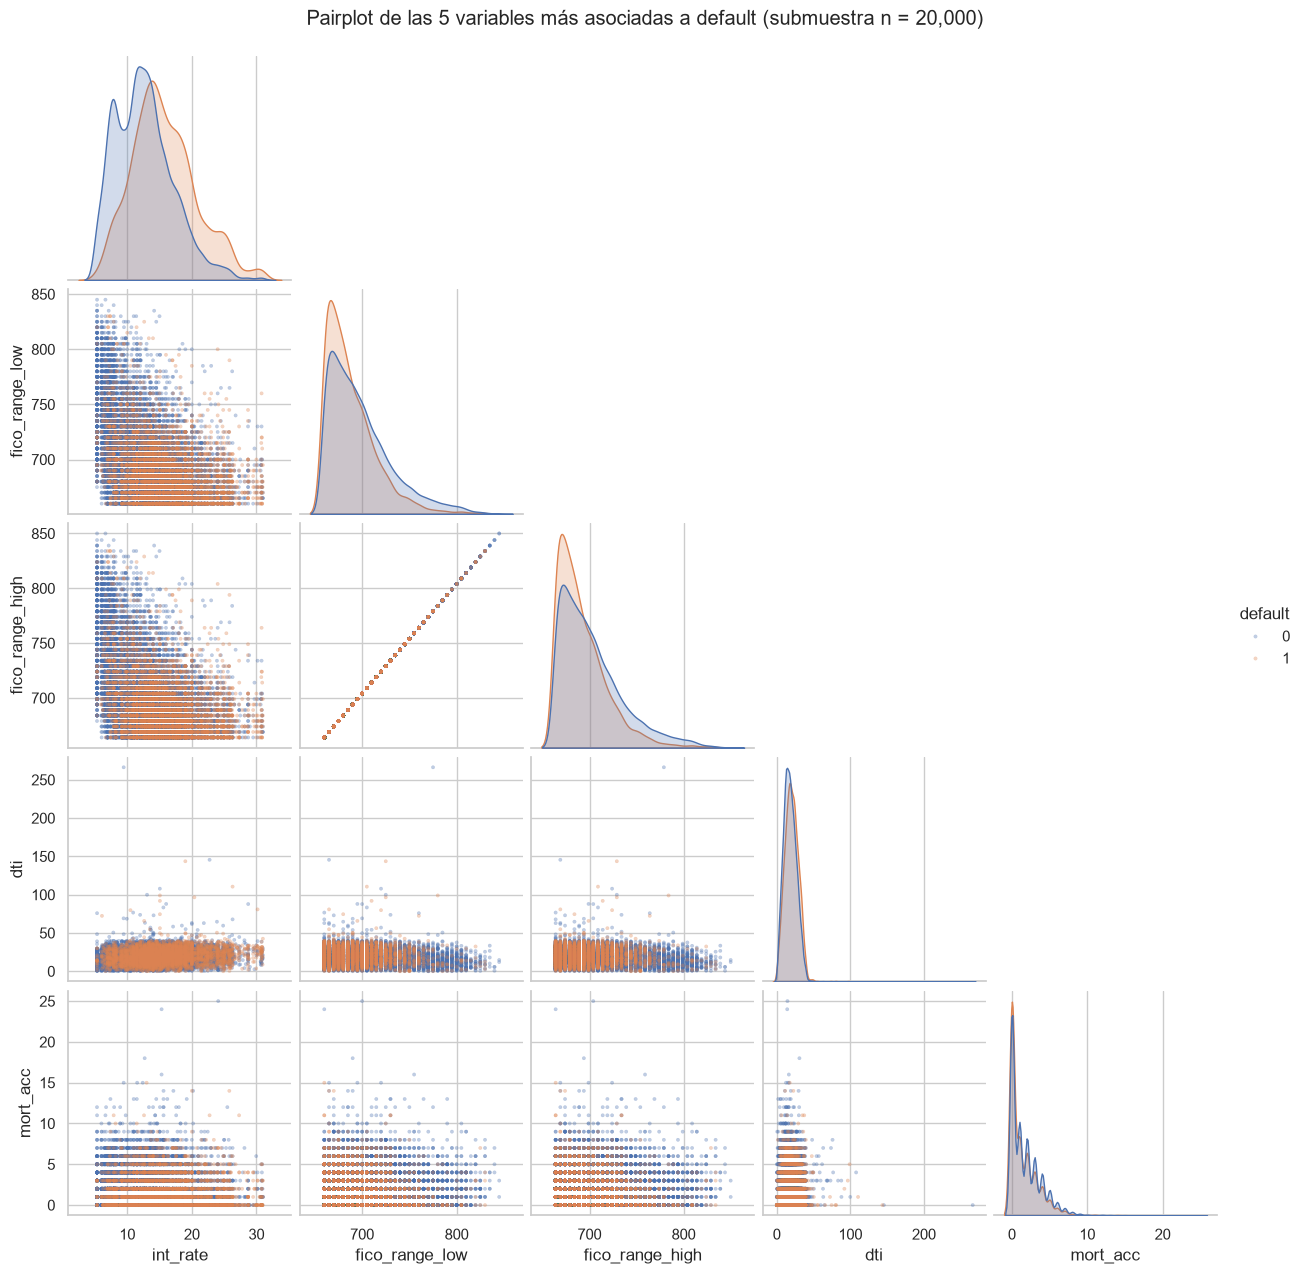

In [35]:
top5 = biv_num.index[:5].tolist()
sample = df.groupby(U.TARGET, group_keys=False).apply(
    lambda g: g.sample(frac=20_000 / len(df), random_state=U.SEED))
g = sns.pairplot(sample[top5 + [U.TARGET]], hue=U.TARGET, palette=PALETTE, corner=True,
                 plot_kws={"s": 6, "alpha": 0.35, "edgecolor": None}, diag_kws={"common_norm": False})
g.figure.suptitle(f"Pairplot de las 5 variables más asociadas a default (submuestra n = {len(sample):,})", y=1.02)
plt.show()

El *pairplot* confirma visualmente las relaciones descritas. La distribución marginal de `int_rate` en los préstamos en default está desplazada hacia la derecha, y la relación entre `fico_range_low` y `fico_range_high` es una recta perfecta. En los diagramas de dispersión, las dos clases se superponen extensamente, sin fronteras lineales ni no lineales evidentes en ningún par de variables. Se aprecian también la discretización de `fico_range` en saltos de cinco puntos y algunos valores de `dti` superiores a 100, casos aislados que motivan el recorte aplicado en el preprocesamiento.

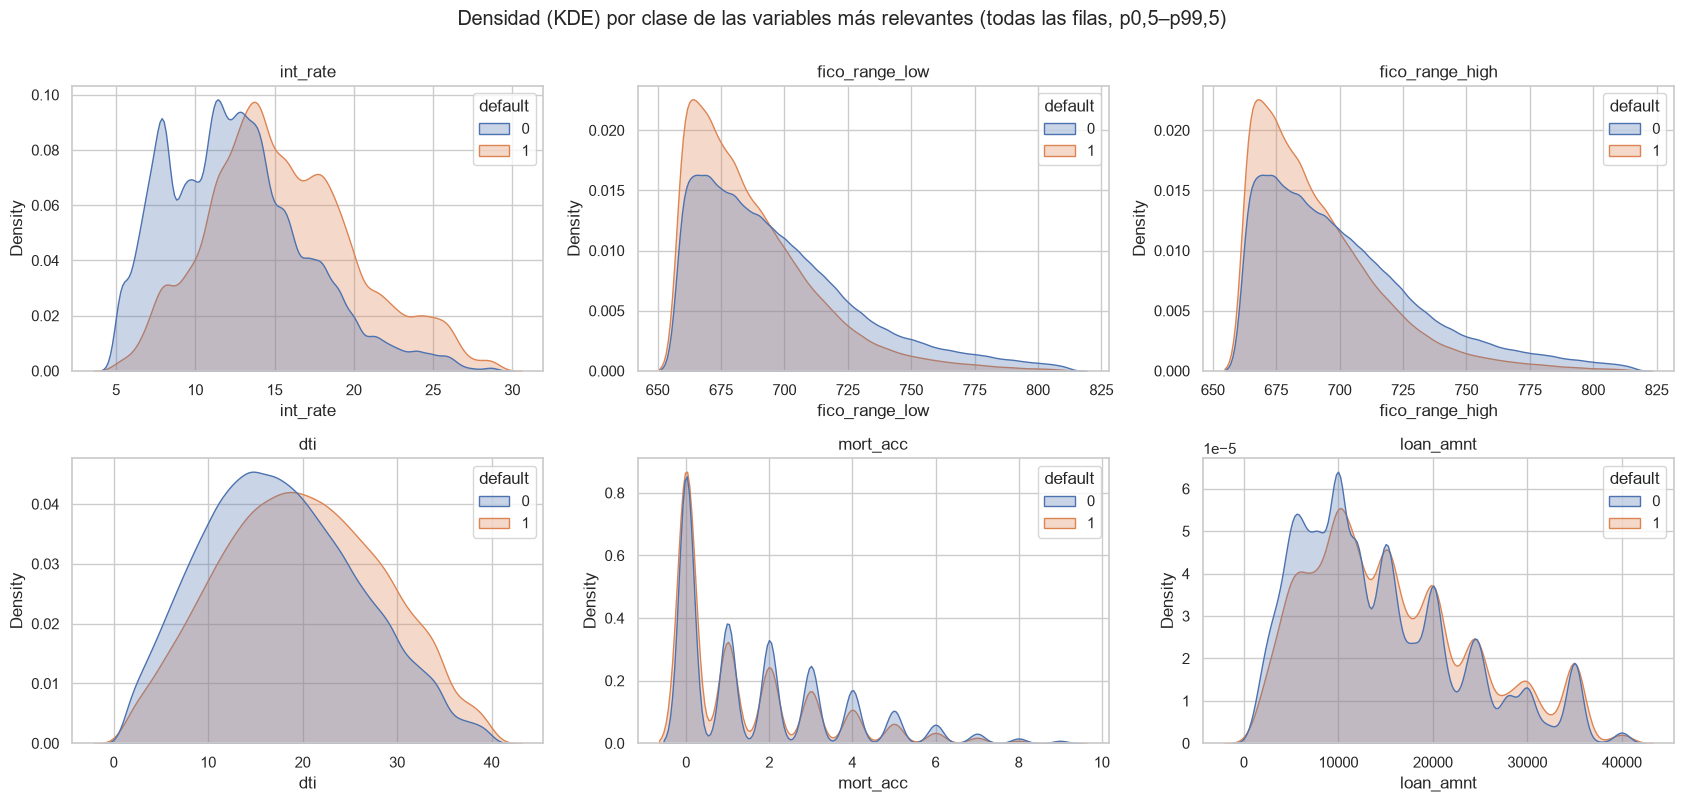

In [36]:
kde_vars = biv_num.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, c in zip(axes.flat, kde_vars):
    lo, hi = df[c].quantile([0.005, 0.995])
    sub = df.loc[df[c].between(lo, hi), [c, U.TARGET]]
    sns.kdeplot(data=sub, x=c, hue=U.TARGET, palette=PALETTE, common_norm=False, fill=True, alpha=0.3,
                ax=ax, bw_adjust=1.5, warn_singular=False)
    ax.set_title(c)
fig.suptitle("Densidad (KDE) por clase de las variables más relevantes (todas las filas, p0,5–p99,5)", y=1.0)
plt.tight_layout()
plt.show()

Las densidades por clase, estimadas con todas las observaciones, muestran que el desplazamiento de `int_rate` es el más marcado: los préstamos pagados tienen una moda cercana al 7 %, correspondiente al grado A, mientras que los defaults se concentran en torno al 14 % y exhiben una cola derecha mucho más pesada. En `fico_range`, los defaults acumulan su masa entre 660 y 690 puntos; en `dti` su densidad aparece desplazada unos tres puntos hacia valores mayores, y en `loan_amnt` y `mort_acc` las diferencias son perceptibles pero pequeñas, en coherencia con las correlaciones de la sección 1.3.1.

## 1.4 Valores faltantes

In [37]:
miss = pd.DataFrame({"n nulos": df[U.NUM_COLS + U.CAT_COLS].isna().sum()})
miss["% nulos"] = 100 * miss["n nulos"] / len(df)
miss = miss[miss["n nulos"] > 0].sort_values("% nulos", ascending=False)
miss

,n nulos,% nulos
mths_since_last_delinq,678743,50.453
emp_length,78511,5.836
mort_acc,47281,3.515
revol_util,857,0.064
pub_rec_bankruptcies,697,0.052
dti,374,0.028
inq_last_6mths,1,0.000


Solo siete de las variables analizadas tienen valores faltantes. `mths_since_last_delinq` (50,5 %) supera el umbral del 30 % y, como se discute más adelante, su ausencia es estructural. `emp_length` (5,8 %) y `mort_acc` (3,5 %) presentan tasas moderadas, y las cuatro variables restantes afectan a menos del 0,1 % de los préstamos, de modo que su tratamiento apenas influye en los resultados.

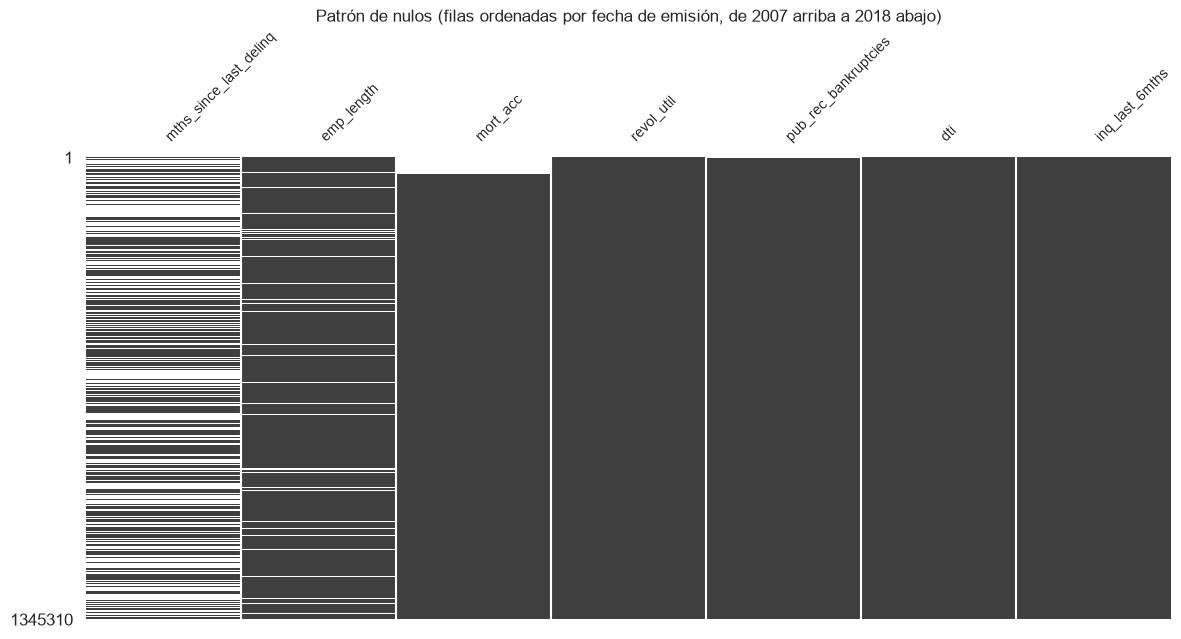

In [38]:
miss_cols = miss.index.tolist()
ordered = df.sort_values("issue_d")[miss_cols]
msno.matrix(ordered, figsize=(14, 6), fontsize=10, sparkline=False)
plt.title("Patrón de nulos (filas ordenadas por fecha de emisión, de 2007 arriba a 2018 abajo)")
plt.show()

La matriz de nulidad, con las filas ordenadas por fecha de emisión, revela que los faltantes no se distribuyen al azar a lo largo del tiempo. `mort_acc` falta en un bloque compacto al comienzo del periodo, correspondiente a los primeros años de la plataforma, mientras que `mths_since_last_delinq` y `emp_length` presentan faltantes dispersos en todo el horizonte.

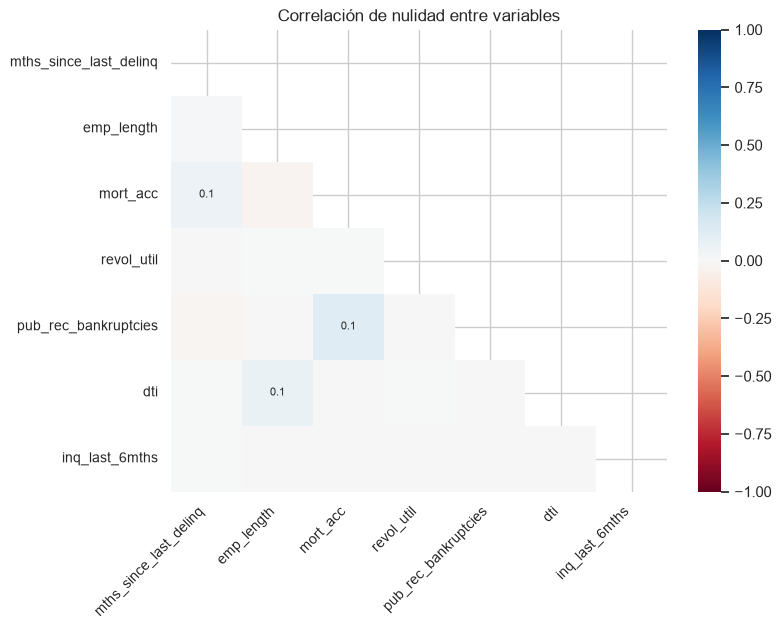

In [39]:
msno.heatmap(df[miss_cols], figsize=(8, 6), fontsize=10)
plt.title("Correlación de nulidad entre variables")
plt.show()

La correlación de nulidad entre pares de variables es prácticamente nula, con valores absolutos de 0,1 como máximo: la ausencia de un dato no predice la ausencia de otro. Los faltantes obedecen, por tanto, a mecanismos independientes en cada variable y pueden tratarse de forma individual.

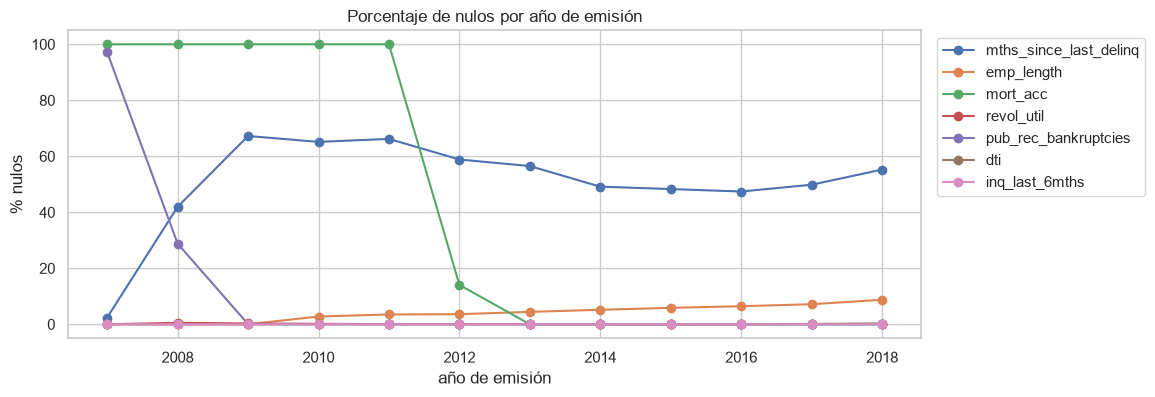

In [40]:
by_year_miss = df[miss_cols].isna().groupby(df["issue_d"].dt.year).mean().mul(100)
fig, ax = plt.subplots(figsize=(11, 4))
by_year_miss.plot(ax=ax, marker="o")
ax.set_ylabel("% nulos")
ax.set_xlabel("año de emisión")
ax.set_title("Porcentaje de nulos por año de emisión")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

La evolución anual precisa esos mecanismos. `mort_acc` falta en el 100 % de los préstamos de 2007 a 2011 y en el 14 % de los de 2012, y `pub_rec_bankruptcies` en los de 2007 y buena parte de 2008: son campos que la plataforma comenzó a registrar más tarde. La proporción de nulos de `emp_length` crece gradualmente desde cerca de cero hasta el 8,6 %, y la de `mths_since_last_delinq` oscila entre el 45 % y el 67 %, según la proporción de solicitantes sin antecedentes de mora en cada cohorte.

**¿Faltan los datos completamente al azar (MCAR)?** Bajo MCAR, que un valor falte no depende ni de las demás variables ni del target. Se hacen dos verificaciones:

1. **Relación con el target.** Se compara la tasa de default entre las filas con y sin nulo en cada variable, con una prueba chi-cuadrado.
2. **Relación con otras variables observadas.** El gráfico anterior ya muestra si la proporción de nulos cambia con el año de emisión.

La prueba global de Little (1988) no está disponible en las librerías del curso; con este $n$ las dos verificaciones anteriores bastan para descartar MCAR cuando hay dependencia.

In [41]:
rows = []
for c in miss_cols:
    isnull = df[c].isna()
    ct = pd.crosstab(isnull, df[U.TARGET])
    chi2, p, *_ = stats.chi2_contingency(ct)
    rows.append({"variable": c, "% nulos": isnull.mean() * 100,
                 "% default si nulo": df.loc[isnull, U.TARGET].mean() * 100,
                 "% default si observado": df.loc[~isnull, U.TARGET].mean() * 100,
                 "chi2": chi2, "p-value": p,
                 "V de Cramér (nulo vs año)": U.cramers_v(isnull, df["issue_d"].dt.year)})
mcar = pd.DataFrame(rows).set_index("variable")
with pd.option_context("display.float_format", lambda v: f"{v:,.4g}"):
    display(mcar)

,% nulos,% default si nulo,% default si observado,chi2,p-value,V de Cramér (nulo vs año)
variable,,,,,,
mths_since_last_delinq,50.45,19.26,20.68,420.3,2.084e-93,0.08582
emp_length,5.836,26.91,19.53,"2,521",0,0.05151
mort_acc,3.515,14.56,20.16,893.5,2.5e-196,0.9267
revol_util,0.0637,21,19.96,0.5181,0.4716,0.01213
pub_rec_bankruptcies,0.05181,16.93,19.96,3.827,0.05043,0.7253
dti,0.0278,18.98,19.96,0.1672,0.6826,0.03659
inq_last_6mths,7.433e-05,0,19.96,0,1,0


Los resultados descartan que los faltantes sean completamente aleatorios en las tres variables con más nulos. En `emp_length` la ausencia es informativa: la tasa de default sube de 19,5 % a 26,9 % cuando el dato falta, posiblemente porque corresponde a solicitantes sin empleo formal o con ingresos irregulares. En `mort_acc` la ausencia está determinada casi por completo por el año de emisión ($V = 0{,}93$), un mecanismo de tipo MAR, y su menor tasa de default (14,6 %) refleja el perfil de las cohortes tempranas. En `mths_since_last_delinq` el faltante es estructural, pues indica que el prestatario nunca estuvo en mora, y por ello se asocia a una tasa de default algo menor (19,3 % frente a 20,7 %). Las variables con menos del 0,1 % de nulos no muestran asociación significativa con el objetivo ($p > 0{,}05$), lo que es compatible con un mecanismo MCAR.

**Plan de tratamiento de faltantes**

Se usan los umbrales del enunciado: **más de 70 % de nulos → eliminar**; **más de 30 % → eliminar o tratamiento avanzado**. Por debajo se imputa con la mediana (numéricas, por su asimetría) o con la moda (categóricas). Si el nulo es informativo (no MCAR) se añade un indicador binario `<var>_missing`. Los imputadores se ajustan **solo con el conjunto de entrenamiento**.

In [42]:
def plan(c):
    p = miss.loc[c, "% nulos"]
    informative = mcar.loc[c, "p-value"] < 0.05 and abs(mcar.loc[c, "% default si nulo"] - mcar.loc[c, "% default si observado"]) > 1
    if p > 70:
        return "eliminar (>70 % nulos)"
    if p > 30:
        return "eliminar la variable (>30 % nulos); se evalúa un indicador de nulidad"
    base = "mediana" if c in U.NUM_COLS else "moda"
    return f"imputar {base}" + (" + indicador de nulidad" if informative else "")

miss_plan = miss.assign(tratamiento=[plan(c) for c in miss.index])
miss_plan

,n nulos,% nulos,tratamiento
mths_since_last_delinq,678743,50.453,eliminar la variable (>30 % nulos); se evalúa ...
emp_length,78511,5.836,imputar mediana + indicador de nulidad
mort_acc,47281,3.515,imputar mediana + indicador de nulidad
revol_util,857,0.064,imputar mediana
pub_rec_bankruptcies,697,0.052,imputar mediana
dti,374,0.028,imputar mediana
inq_last_6mths,1,0.000,imputar mediana


El plan resultante combina eliminación e imputación según el mecanismo identificado en cada caso. `mths_since_last_delinq` se elimina, pero su información principal se conserva mediante el indicador `has_delinq_history`. `emp_length` y `mort_acc` se imputan con la mediana y se acompañan de indicadores de nulidad, dado que su ausencia es informativa; el resto se imputa con la mediana, robusta frente a la asimetría descrita. Todas las medianas se estiman exclusivamente con el conjunto de entrenamiento (capítulo 2), para evitar cualquier fuga de información desde el conjunto de prueba.

## 1.5 Guardado del dataset de análisis

Se guarda en Parquet el dataset filtrado (id, fecha, target y variables analizadas), que el capítulo de preprocesamiento reutiliza en scikit-learn. PySpark volverá a leer el CSV original, como exige el enunciado.

In [43]:
df.to_parquet(U.EDA_PARQUET, index=False)
print(U.EDA_PARQUET, f"{U.EDA_PARQUET.stat().st_size / 1e6:.1f} MB")

C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\jbook_ml202330\data\lc_eda.parquet 37.6 MB


## 1.6 Resumen ejecutivo del EDA

El análisis se realizó sobre la totalidad del archivo `accepted_2007_to_2018Q4.csv` (2.260.701 registros y 151 columnas), del que se retuvieron los 1.345.310 préstamos con desenlace conocido: 80,04 % pagados por completo y 19,96 % en default. Ambos entornos de trabajo leen exactamente las mismas filas, siempre que Spark interprete las comillas según la norma RFC 4180 (`escape='"'`). De las 151 columnas se descartaron 38 por constituir fuga de información (pagos, recuperaciones, último FICO o acuerdos de liquidación, todos posteriores a la originación), 7 identificadores o campos de texto libre y 34 variables con más del 30 % de nulos. El análisis se concentró en 29 variables disponibles al originar el préstamo, más dos derivadas: la antigüedad del historial crediticio y la antigüedad laboral en años.

En cuanto a la calidad de los datos, los principales problemas son las colas extremas de `annual_inc`, `dti`, `revol_bal` y `revol_util`, que incluyen valores implausibles (ingresos nulos o de 11 millones, `dti` de 999, utilización de 892 %), y tres patrones de valores faltantes con mecanismos distintos. En `mths_since_last_delinq` la ausencia es estructural, porque el nulo indica ausencia de mora previa. En `emp_length` es informativa, pues el default sube a 26,9 % cuando falta. En `mort_acc` depende del periodo, ya que el campo no se registró antes de 2012. Ninguna variable es normal, y trece presentan asimetría severa.

La capacidad predictiva se concentra en pocas variables. La tasa de interés es, con amplitud, el predictor más asociado al default ($r_{pb} = 0{,}26$; correlación biserial por rangos de 0,37), seguida del grado (V = 0,26), el plazo (V = 0,18; 32,4 % de default a 60 meses) y el puntaje FICO ($r_{pb} = -0{,}13$). La razón deuda/ingreso, el número de hipotecas, el monto, las consultas recientes y la utilización revolvente aportan efectos pequeños pero consistentes, y variables como el estado de residencia, el tipo de solicitud o el estado de listado inicial tienen una asociación prácticamente nula. La superposición de las distribuciones de ambas clases en todas las variables anticipa un problema de discriminación difícil, con un techo de desempeño modesto.

Se identificaron además redundancias fuertes (`fico_range_low` y `fico_range_high`, $r = 1{,}00$; `installment` y `loan_amnt`, $r = 0{,}95$; `grade` e `int_rate`, $\eta = 0{,}95$), un desbalance moderado de clases y un efecto temporal marcado, con cohortes recientes censuradas que sesgan a la baja su tasa de default observada.

Estas observaciones fijan las decisiones del preprocesamiento. Se modelan dieciséis variables numéricas (`loan_amnt`, `int_rate`, `annual_inc`, `dti`, `fico_range_high`, `emp_length`, `credit_hist_years`, `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `revol_bal`, `revol_util`, `total_acc`, `mort_acc` y `pub_rec_bankruptcies`), tres indicadores (`has_delinq_history`, `emp_length_missing` y `mort_acc_missing`) y siete categóricas (`term`, `home_ownership`, `verification_status`, `purpose`, `addr_state`, `initial_list_status` y `application_type`). Se excluyen `fico_range_low`, `installment` y `grade` por redundancia, y `mths_since_last_delinq` e `issue_d` por las razones expuestas. Las categorías minoritarias de `home_ownership` y `purpose` se agrupan; `dti` y `revol_util` se recortan a los percentiles 0,1 y 99,9; `annual_inc` y `revol_bal` se transforman con `log1p`; los faltantes se imputan con la mediana, y las variables numéricas se estandarizan. Todos los parámetros se estiman únicamente con el conjunto de entrenamiento. El desbalance se aborda con partición y validación cruzada estratificadas, selección por ROC AUC, reporte de AUC-PR y un umbral de decisión fijado con datos de entrenamiento, sin remuestreo, para preservar la comparabilidad entre scikit-learn y PySpark.

# 2. Preprocesamiento

Este capítulo corresponde a la sección 9.10.4.2 del proyecto. Aplica las decisiones del resumen ejecutivo del EDA (sección 1.6) de forma **idéntica en scikit-learn y en PySpark**, partiendo en ambos casos del CSV original completo:

1. Se genera **una única partición 80/20 estratificada** y se guarda en disco. Los dos entornos la leen.
2. Se ajustan los transformadores **solo con el conjunto de entrenamiento** y después se aplican al de prueba.
3. Se verifica numéricamente que los dos entornos producen exactamente las mismas variables.

El código de las transformaciones está en `lc_utils.py` (`SkPreprocessor` y `spark_preprocess`), para que los capítulos de modelado usen exactamente el mismo preprocesamiento que se valida aquí.

In [44]:
import json
import os
import platform
import time
import warnings

import numpy as np
import pandas as pd
import psutil

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 2.1 Partición común de los datos

La prueba de DeLong compara los AUC calculados **sobre las mismas observaciones**, así que scikit-learn y PySpark deben evaluar exactamente el mismo conjunto de prueba. La partición se define una sola vez:

* con `train_test_split` sobre el identificador `id`;
* con `test_size=0.2`, `stratify=default` y `random_state=42`;
* y se guarda en `data/split.parquet` con las columnas `id` y `split`.

PySpark no usa `randomSplit`: lee este archivo y separa los conjuntos filtrando por `split`.

In [45]:
t0 = time.time()
df = U.load_model_frame()          # CSV completo -> filtro de desenlace -> variables del modelo
t_sk_load = time.time() - t0

split = U.make_split(df)
split.to_parquet(U.SPLIT_PARQUET, index=False)
df = df.merge(split, on="id", validate="one_to_one")
t_sk_split = time.time() - t0 - t_sk_load

print(f"Filas: {len(df):,} | lectura y construcción de variables: {t_sk_load:.1f} s | partición: {t_sk_split:.1f} s")
print("Archivo:", U.SPLIT_PARQUET)

Filas: 1,345,310 | lectura y construcción de variables: 31.1 s | partición: 4.9 s
Archivo: C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\jbook_ml202330\data\split.parquet


In [46]:
part = df.groupby("split")[U.TARGET].agg(n="size", defaults="sum", pct_default="mean")
part["pct_default"] *= 100
part["% de filas"] = 100 * part["n"] / part["n"].sum()
print("ids únicos:", split["id"].is_unique,
      "| intersección train/test:", len(set(split.loc[split.split == "train", "id"]) & set(split.loc[split.split == "test", "id"])))
part

ids únicos: True | intersección train/test: 0


,n,defaults,pct_default,% de filas
split,,,,
test,269062,53712,19.962685,20.0
train,1076248,214847,19.962592,80.0


La tasa de default es prácticamente la misma en los dos conjuntos, como corresponde a una partición estratificada. El conjunto de prueba tiene 269.062 préstamos: es el tamaño de muestra sobre el que se calculan después DeLong, McNemar y el bootstrap pareado.

## 2.2 Preprocesamiento con scikit-learn

| Paso | Variables | Transformación | Parámetro aprendido en *train* |
|---|---|---|---|
| Selección | 16 numéricas y 7 categóricas | se excluyen `fico_range_low`, `installment`, `grade` (redundantes), `mths_since_last_delinq` (50 % de nulos) e `issue_d` | — |
| Indicadores | `has_delinq_history`, `emp_length_missing`, `mort_acc_missing` | 1 si hay historial de mora o si el dato falta | — |
| Agrupación | `home_ownership`, `purpose` | `ANY`/`NONE`/`OTHER` → `OTHER`; categorías con menos del 1 % → `other` | — |
| Recorte | `dti`, `revol_util` | recorte (*clip*) a los percentiles 0,1 y 99,9 | percentiles |
| Transformación | `annual_inc`, `revol_bal` | `log1p` | — |
| Imputación | `emp_length`, `mort_acc`, `revol_util`, `pub_rec_bankruptcies`, `dti`, `inq_last_6mths` | mediana | medianas |
| Escalado | 16 numéricas y 3 indicadores | `StandardScaler` | media y desviación |
| Codificación | 7 categóricas | `OneHotEncoder(handle_unknown="ignore")`, una columna por categoría | categorías |

Los percentiles y las medianas se calculan como un **elemento de la muestra** (`method="inverted_cdf"`), que es la misma definición que usa Spark con `approxQuantile(..., relativeError=0)`. Así los dos entornos aprenden exactamente los mismos valores.

Las variables numéricas se escalan para todos los modelos. La regresión logística, LinearSVC y Naive Bayes gaussiano lo necesitan. Los árboles son invariantes a transformaciones monótonas, así que el escalado no les cambia nada. Usar una sola matriz para los seis modelos simplifica la comparación.

**Nota sobre la validación cruzada.** El enunciado exige `GridSearchCV` **sin `Pipeline`**. Por eso el preprocesamiento se ajusta con todo el conjunto de entrenamiento antes de la búsqueda, y los pliegues de validación comparten medianas, percentiles y medias con los de ajuste. El efecto es despreciable: son pocos parámetros estimados con más de un millón de filas. Además, afecta igual a los dos entornos, porque el `CrossValidator` de PySpark recibe también los datos ya transformados. El conjunto de prueba **no** participa en ningún ajuste.

In [47]:
train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

t0 = time.time()
prep = U.SkPreprocessor().fit(train_df)
X_train, X_test = prep.transform(train_df), prep.transform(test_df)
y_train, y_test = train_df[U.TARGET].to_numpy(), test_df[U.TARGET].to_numpy()
t_sk_fit = time.time() - t0
t_sk_total = t_sk_load + t_sk_split + t_sk_fit

print(f"X_train: {X_train.shape} | X_test: {X_test.shape} | dtype: {X_train.dtype}")
print(f"Memoria de X_train: {X_train.nbytes / 1e6:.0f} MB | ajuste y transformación: {t_sk_fit:.1f} s")

X_train: (1076248, 91) | X_test: (269062, 91) | dtype: float32
Memoria de X_train: 392 MB | ajuste y transformación: 3.6 s


In [48]:
pd.DataFrame(X_train[:5], columns=prep.feature_names_).iloc[:, :24].round(3)

,loan_amnt,int_rate,annual_inc,dti,fico_range_high,emp_length,credit_hist_years,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,has_delinq_history,emp_length_missing,mort_acc_missing,term_36 months,term_60 months,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN
0,-1.241,0.157,-0.293,-1.416,-0.665,1.126,-0.523,-0.362,0.367,-0.838,-0.356,-1.034,-0.903,-0.998,-0.329,-0.356,1.008,-0.249,-0.191,1.0,0.0,1.0,0.0,0.0
1,0.640,-0.516,-0.054,-0.855,-0.037,1.126,-0.123,-0.362,-0.698,-1.021,-0.356,-0.181,0.179,-0.581,1.704,-0.356,-0.992,-0.249,-0.191,0.0,1.0,1.0,0.0,0.0
2,-0.283,0.042,-1.136,-0.922,-0.194,-0.549,1.588,-0.362,-0.698,-1.203,-0.356,-0.088,0.677,-1.581,-0.837,-0.356,-0.992,-0.249,-0.191,1.0,0.0,0.0,0.0,0.0
3,0.640,-0.853,1.787,-0.406,-0.508,1.126,1.232,-0.362,-0.698,0.074,-0.356,1.783,1.335,0.168,1.196,-0.356,1.008,-0.249,-0.191,1.0,0.0,1.0,0.0,0.0
4,0.640,-0.996,0.471,-0.067,0.276,1.126,0.077,0.777,-0.698,-0.656,-0.356,-2.019,-1.883,-0.831,0.687,-0.356,1.008,-0.249,-0.191,1.0,0.0,1.0,0.0,0.0


In [49]:
learned_sk = pd.DataFrame({
    "parámetro": [f"clip {c} [p0,1 ; p99,9]" for c in U.CLIP_COLS] + [f"mediana {c}" for c in U.IMPUTE_COLS],
    "scikit-learn": [str(prep.clip_[c]) for c in U.CLIP_COLS] + [prep.median_[c] for c in U.IMPUTE_COLS],
})
ohe_sizes = {c: len(cats) for c, cats in zip(U.MODEL_CAT, prep.ohe_.categories_)}
print("Dummies por variable categórica:", ohe_sizes, "| total de variables:", len(prep.feature_names_))
learned_sk

Dummies por variable categórica: {'term': 2, 'home_ownership': 4, 'verification_status': 3, 'purpose': 8, 'addr_state': 51, 'initial_list_status': 2, 'application_type': 2} | total de variables: 91


,parámetro,scikit-learn
0,"clip dti [p0,1 ; p99,9]","(0.21, 65.98)"
1,"clip revol_util [p0,1 ; p99,9]","(0.0, 102.6)"
2,mediana emp_length,6.0
3,mediana mort_acc,1.0
4,mediana revol_util,52.2
5,mediana pub_rec_bankruptcies,0.0
6,mediana dti,17.62
7,mediana inq_last_6mths,0.0


In [50]:
# Se guardan los resúmenes que se comparan con PySpark y se libera la memoria antes de iniciar Spark.
sk_summary = {
    "n": {"train": len(train_df), "test": len(test_df)},
    "pct_default": {"train": 100 * y_train.mean(), "test": 100 * y_test.mean()},
    "mean": dict(zip(prep.feature_names_, X_train.mean(axis=0, dtype=np.float64))),
    "scaler_mean": dict(zip(U.SCALED_COLS, prep.scaler_.mean_)),
    "scaler_std": dict(zip(U.SCALED_COLS, prep.scaler_.scale_)),
}
del df, train_df, test_df, X_train, X_test, y_train, y_test

## 2.3 Preprocesamiento con PySpark

La `SparkSession` se crea con la configuración obligatoria del enunciado (`U.spark_session`). El flujo de `U.spark_preprocess` es:

1. **Leer el CSV completo** con `spark.read.csv(..., escape='"')` (ver sección 1.1), filtrar `Fully Paid`/`Charged Off` y construir con funciones de Spark SQL las mismas variables que en pandas: años de empleo, antigüedad crediticia, indicadores y agrupaciones.
2. **Unir con la partición común** (`data/split.parquet`) por `id` y separar `train` y `test` filtrando la columna `split`.
3. **Ajustar con train un `Pipeline`** con estas etapas:
   * `approxQuantile(…, 0.0)` para los límites de recorte (el resultado son 4 números);
   * `Imputer(strategy="median", relativeError=0.0)`;
   * `StringIndexer(handleInvalid="keep")` con `OneHotEncoder(dropLast=True)`;
   * `VectorAssembler` y `StandardScaler(withMean=True, withStd=True)` sobre las numéricas;
   * un `VectorAssembler` final con las dummies.
4. **Transformar train y test y cachearlos** con `.persist(StorageLevel.MEMORY_AND_DISK)` justo después del `VectorAssembler`, como exige el enunciado.

Durante todo el proceso los datos permanecen como DataFrame de Spark: **no se usa `.toPandas()` ni `.collect()`** sobre el dataset. Al driver solo llegan resultados agregados de tamaño fijo (cuantiles, medianas, conteos y el vector de medias de la sección 2.4).

In [51]:
spark = U.spark_session()
print("Spark", spark.version, "| master:", spark.sparkContext.master)
print({k: v for k, v in spark.sparkContext.getConf().getAll()
       if k in {"spark.sql.shuffle.partitions", "spark.default.parallelism", "spark.executor.memory",
                "spark.driver.memory", "spark.memory.fraction", "spark.memory.storageFraction"}})

Spark 3.5.5 | master: local[*]
{'spark.memory.fraction': '0.8', 'spark.default.parallelism': '400', 'spark.sql.shuffle.partitions': '400', 'spark.driver.memory': '8g', 'spark.executor.memory': '8g', 'spark.memory.storageFraction': '0.3'}


In [52]:
t0 = time.time()
res = U.spark_preprocess(spark)
t_spark_total = time.time() - t0
train_s, test_s, model_s = res["train"], res["test"], res["model"]
print(f"train: {res['n_train']:,} | test: {res['n_test']:,} | tiempo total (lectura + pipeline + caché): {t_spark_total:.1f} s")
print("Etapas del Pipeline:", [type(s).__name__ for s in model_s.stages])

train: 1,076,248 | test: 269,062 | tiempo total (lectura + pipeline + caché): 158.1 s
Etapas del Pipeline: ['ImputerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'OneHotEncoderModel', 'VectorAssembler', 'StandardScalerModel', 'VectorAssembler']


In [53]:
print("train cacheado:", train_s.is_cached, "|", train_s.storageLevel)
print("test  cacheado:", test_s.is_cached, "|", test_s.storageLevel)
train_s.printSchema()
train_s.show(3, truncate=110)

train cacheado: True | Disk Memory Serialized 1x Replicated
test  cacheado: True | Disk Memory Serialized 1x Replicated
root
 |-- id: long (nullable = true)
 |-- default: integer (nullable = false)
 |-- features: vector (nullable = true)



+--------+-------+--------------------------------------------------------------------------------------------------------------+
|      id|default|                                                                                                      features|
+--------+-------+--------------------------------------------------------------------------------------------------------------+
|68407277|      0|(91,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,25,30,74,88,89],[-1.2410524863584014,0.1568214644...|
|68341763|      0|(91,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21,25,31,50,88,90],[0.6398607239337363,-0.5159979584...|
|68426831|      0|(91,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,24,26,30,46,88,89],[-0.2833924067279532,0.0415408779...|
+--------+-------+--------------------------------------------------------------------------------------------------------------+
only showing top 3 rows



In [54]:
from pyspark.sql import functions as F

rates = {}
for name, d in [("train", train_s), ("test", test_s)]:
    r = d.agg(F.count("*").alias("n"), F.sum(U.TARGET).alias("defaults")).first()
    rates[name] = (r["n"], r["defaults"])
pd.DataFrame(rates, index=["n", "defaults"]).T.assign(pct_default=lambda t: 100 * t["defaults"] / t["n"])

,n,defaults,pct_default
train,1076248,214847,19.962592
test,269062,53712,19.962685


## 2.4 Verificación de la equivalencia entre entornos

Se comparan los parámetros aprendidos (límites de recorte, medianas, media y desviación del escalador) y la media de cada una de las 91 variables resultantes en el conjunto de entrenamiento. En Spark, la media se calcula con `Summarizer`, que devuelve un único vector agregado.

In [55]:
from pyspark.ml.stat import Summarizer

imp = model_s.stages[0].surrogateDF.first().asDict()
scaler_s = model_s.stages[-2]
rows = []
for c in U.CLIP_COLS:
    for k, q in enumerate(["p0,1", "p99,9"]):
        rows.append({"parámetro": f"clip {c} {q}", "scikit-learn": prep.clip_[c][k], "PySpark": res["bounds"][c][k]})
for c in U.IMPUTE_COLS:
    rows.append({"parámetro": f"mediana {c}", "scikit-learn": prep.median_[c], "PySpark": imp[c]})
for i, c in enumerate(U.SCALED_COLS):
    rows.append({"parámetro": f"media {c}", "scikit-learn": sk_summary["scaler_mean"][c], "PySpark": scaler_s.mean[i]})
    rows.append({"parámetro": f"desv. {c}", "scikit-learn": sk_summary["scaler_std"][c], "PySpark": scaler_s.std[i]})
params = pd.DataFrame(rows).set_index("parámetro")
params["Δ relativa"] = (params["PySpark"] - params["scikit-learn"]).abs() / params["scikit-learn"].abs().clip(lower=1e-12)
with pd.option_context("display.float_format", lambda v: f"{v:,.6g}"):
    display(params.sort_values("Δ relativa", ascending=False).head(12))
print("Máxima diferencia relativa:", params["Δ relativa"].max())

,scikit-learn,PySpark,Δ relativa
parámetro,,,
desv. mort_acc_missing,0.184447,0.184447,4.64577e-07
desv. fico_range_high,31.872,31.872,4.64577e-07
desv. dti,8.67494,8.67494,4.64577e-07
desv. emp_length,3.58139,3.58139,4.64577e-07
desv. emp_length_missing,0.234451,0.234451,4.64577e-07
desv. loan_amnt,"8,719.16","8,719.17",4.64577e-07
desv. revol_bal,1.2254,1.2254,4.64577e-07
desv. total_acc,12.0029,12.0029,4.64577e-07
desv. revol_util,24.4871,24.4871,4.64577e-07


Máxima diferencia relativa: 4.6457726208361726e-07


Los límites de recorte, las medianas y las medias coinciden exactamente. La única diferencia está en la desviación estándar del escalador y es del orden de $5 \times 10^{-7}$. Se debe a que Spark usa la desviación muestral ($n-1$) y scikit-learn la poblacional ($n$): el cociente entre ambas es $\sqrt{n/(n-1)} \approx 1 + 4{,}6 \times 10^{-7}$ con $n = 1.076.248$. No tiene efecto práctico en los modelos.

In [56]:
names_s = U.spark_feature_names(train_s)
mean_s = train_s.select(Summarizer.mean(F.col("features")).alias("m")).first()["m"].toArray()
cmp = pd.DataFrame({"scikit-learn": pd.Series(sk_summary["mean"]), "PySpark": pd.Series(mean_s, index=names_s)})
cmp["|Δ|"] = (cmp["PySpark"] - cmp["scikit-learn"]).abs()
print(f"Variables: scikit-learn {len(sk_summary['mean'])} | PySpark {len(names_s)} | mismos nombres: {set(names_s) == set(sk_summary['mean'])}")
print(f"Máxima |Δ| en la media de las variables transformadas (train): {cmp['|Δ|'].max():.2e}")
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    display(cmp.loc[[n for n in cmp.index if not n.startswith("addr_state")]])

Variables: scikit-learn 91 | PySpark 91 | mismos nombres: True
Máxima |Δ| en la media de las variables transformadas (train): 1.71e-08


,scikit-learn,PySpark,|Δ|
loan_amnt,-0.000000,-0.000000,0.000000
int_rate,-0.000000,0.000000,0.000000
annual_inc,-0.000000,0.000000,0.000000
dti,0.000000,-0.000000,0.000000
fico_range_high,-0.000000,0.000000,0.000000
emp_length,-0.000000,-0.000000,0.000000
credit_hist_years,0.000000,-0.000000,0.000000
delinq_2yrs,-0.000000,-0.000000,0.000000
inq_last_6mths,0.000000,-0.000000,0.000000
open_acc,0.000000,0.000000,0.000000


Los dos entornos producen **las mismas 91 variables**, con las mismas categorías, y medias idénticas hasta el orden de $10^{-8}$ (error de redondeo numérico). También coinciden el número de filas y la tasa de default de cada conjunto. Por lo tanto, cualquier diferencia en los resultados de los capítulos siguientes se deberá a los **algoritmos** de cada librería y no a los datos que reciben.

La tabla omite las 51 dummies de `addr_state` para abreviar; están incluidas en la comparación del máximo $|\Delta|$.

## 2.5 Tiempos de preprocesamiento y hardware

In [57]:
vm = psutil.virtual_memory()
hardware = {
    "procesador": platform.processor(),
    "núcleos físicos": psutil.cpu_count(logical=False),
    "núcleos lógicos": psutil.cpu_count(logical=True),
    "RAM total (GB)": round(vm.total / 1e9, 1),
    "sistema": f"{platform.system()} {platform.release()}",
    "Python": platform.python_version(),
    "Spark": spark.version,
}
times = pd.DataFrame({
    "entorno": ["scikit-learn", "PySpark"],
    "lectura CSV + variables (s)": [t_sk_load, np.nan],
    "partición (s)": [t_sk_split, np.nan],
    "ajuste + transformación (s)": [t_sk_fit, np.nan],
    "total (s)": [t_sk_total, t_spark_total],
})
display(pd.Series(hardware, name="valor").to_frame())
times

,valor
procesador,"Intel64 Family 6 Model 154 Stepping 4, Genuine..."
núcleos físicos,10
núcleos lógicos,12
RAM total (GB),16.8
sistema,Windows 10
Python,3.11.16
Spark,3.5.5


,entorno,lectura CSV + variables (s),partición (s),ajuste + transformación (s),total (s)
0,scikit-learn,31.133863,4.866243,3.568994,39.569099
1,PySpark,NaN,NaN,NaN,158.143229


En PySpark las etapas no se miden por separado. Como la evaluación es perezosa, la lectura del CSV, la unión con la partición, el ajuste del `Pipeline` y el llenado del caché se ejecutan en los mismos trabajos. El total de Spark incluye varias pasadas completas sobre los datos:

* los cuantiles exactos;
* las medianas exactas del `Imputer`;
* los siete `StringIndexer`;
* la media y la desviación del `StandardScaler`;
* la materialización del caché.

pandas, en cambio, resuelve cada paso con operaciones vectorizadas en memoria. Con 1,3 millones de filas, que caben en la RAM de un solo equipo, esa diferencia favorece a scikit-learn. Se retoma en la reflexión final.

In [58]:
timings_path = U.DATA_DIR / "timings.json"
timings = json.loads(timings_path.read_text(encoding="utf-8")) if timings_path.exists() else {}
timings["preprocesamiento"] = {"scikit-learn": t_sk_total, "PySpark": t_spark_total}
timings["hardware"] = hardware
timings_path.write_text(json.dumps(timings, indent=2, ensure_ascii=False), encoding="utf-8")

train_s.unpersist()
test_s.unpersist()
spark.stop()
print("Guardado:", timings_path)

Guardado: C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\jbook_ml202330\data\timings.json


# 3. Modelado con scikit-learn

Este capítulo corresponde a las secciones 9.10.4.3 y 9.10.4.4 del proyecto. Se entrenan los seis modelos con `GridSearchCV` **sin `Pipeline`**, con estos parámetros:

* `cv=3`, el mismo número de pliegues que el `CrossValidator` de PySpark;
* `scoring="roc_auc"`;
* `n_jobs=-1`.

Los modelos se entrenan sobre la matriz de entrenamiento del capítulo 2 y se evalúan en el conjunto de prueba común. Las puntuaciones continuas del conjunto de prueba se guardan para la prueba de DeLong.

In [59]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import lc_utils as U

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
U.MODELS_SK_DIR.mkdir(exist_ok=True)

## 3.1 Hardware y datos

Para interpretar los tiempos, se declara el hardware en el que se ejecutan ambos entornos (registrado en el capítulo 2). scikit-learn paraleliza la búsqueda de hiperparámetros entre los núcleos lógicos del procesador con `n_jobs=-1`; Spark corre en modo `local[*]` sobre los mismos núcleos.

In [60]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
display(pd.Series(timings["hardware"], name="valor").to_frame())

data = U.sk_train_test()
X_train, X_test, y_train, y_test = data["X_train"], data["X_test"], data["y_train"], data["y_test"]
feature_names = data["prep"].feature_names_
n_train = len(y_train)
prevalence = y_train.mean()
print(f"X_train {X_train.shape}, X_test {X_test.shape}, prevalencia de default en train = {prevalence:.4f}")

,valor
procesador,"Intel64 Family 6 Model 154 Stepping 4, Genuine..."
núcleos físicos,10
núcleos lógicos,12
RAM total (GB),16.8
sistema,Windows 10
Python,3.11.16
Spark,3.5.5


X_train (1076248, 91), X_test (269062, 91), prevalencia de default en train = 0.1996


## 3.2 Modelos y espacios de búsqueda

| Modelo | Clase de scikit-learn | Espacio de búsqueda |
|---|---|---|
| Regresión logística | `LogisticRegression(solver="lbfgs")`, penalización L2 | $C = 1/(\text{regParam} \cdot n)$, con regParam $\in \{10^{-6}, 10^{-5}, 10^{-4}\}$ y $n = 1.076.248$ |
| Árbol de decisión | `DecisionTreeClassifier` | `max_depth` $\in \{5, 10, 15\}$ |
| Bosque aleatorio | `RandomForestClassifier` | `n_estimators` $\in \{10, 50, 100\}$ × `max_depth` $\in \{5, 10, 15\}$ |
| Gradient boosting | `GradientBoostingClassifier(learning_rate=0.1)` | `n_estimators` $\in \{50, 100\}$ × `max_depth` $\in \{3, 5\}$ |
| SVM lineal | `LinearSVC(loss="hinge")` | el mismo $C$ que la regresión logística |
| Naive Bayes | `GaussianNB` | sin búsqueda (configuración por defecto) |

**Equivalencias con PySpark**, que se discuten con detalle en el capítulo 4:

* La regresión logística de scikit-learn minimiza $C\sum_i \ell_i + \tfrac12\lVert w\rVert^2$. La de Spark minimiza $\tfrac1n\sum_i \ell_i + \tfrac{\text{regParam}}{2}\lVert w\rVert^2$. Las dos coinciden cuando $C = 1/(\text{regParam}\cdot n)$. Esa relación es aproximada durante la validación cruzada, porque cada pliegue de ajuste tiene $2n/3$ filas y no $n$.
* `LinearSVC(loss="hinge")` reproduce la pérdida de Spark. El valor por defecto de scikit-learn es la hinge al cuadrado.
* **Pliegues.** `StratifiedKFold(3, shuffle=True, random_state=42)` asigna los pliegues al azar con semilla fija, como hace `CrossValidator` con `seed`. Los pliegues concretos de cada entorno no son idénticos, pero ambos se evalúan sobre el mismo conjunto de prueba.
* **Semillas.** Los modelos estocásticos (árbol, bosque y boosting) usan `random_state=42`.
* **Paralelismo.** En el bosque se usa `n_jobs=1` dentro del estimador. El paralelismo lo aporta `GridSearchCV(n_jobs=-1)`, que ejecuta combinaciones y pliegues simultáneamente sin sobresuscribir los núcleos.

In [61]:
C_grid = [1 / (r * n_train) for r in U.REG_PARAMS]
specs = {
    "LogReg": (LogisticRegression(solver="lbfgs", max_iter=1000), {"C": C_grid}),
    "DecisionTree": (DecisionTreeClassifier(random_state=U.SEED), {"max_depth": [5, 10, 15]}),
    "RandomForest": (RandomForestClassifier(random_state=U.SEED, n_jobs=1),
                     {"n_estimators": [10, 50, 100], "max_depth": [5, 10, 15]}),
    "GradBoost": (GradientBoostingClassifier(learning_rate=0.1, random_state=U.SEED),
                  {"n_estimators": [50, 100], "max_depth": [3, 5]}),
    "LinearSVC": (LinearSVC(loss="hinge", max_iter=1000, random_state=U.SEED), {"C": C_grid}),
    "NaiveBayes": (GaussianNB(), {}),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=U.SEED)
pd.DataFrame({"regParam (PySpark)": U.REG_PARAMS, "C (scikit-learn)": C_grid})

,regParam (PySpark),C (scikit-learn)
0,0.000001,0.929154
1,0.000010,0.092915
2,0.000100,0.009292


## 3.3 Entrenamiento con `GridSearchCV`

Para cada modelo se registran:

* `best_params_`, `best_score_` (AUC medio de validación cruzada) y `best_estimator_`;
* el **tiempo de entrenamiento**, que incluye la validación cruzada completa y el reajuste final con todo el conjunto de entrenamiento;
* el **tiempo de predicción** sobre el conjunto de prueba.

La puntuación continua es `predict_proba(X)[:, 1]`. En LinearSVC, que no produce probabilidades, se usa `decision_function(X)`.

**Umbral de decisión.** Con 20 % de default, el umbral por defecto (0,5 para probabilidades, 0 para LinearSVC) hace que casi nunca se prediga la clase minoritaria. Por eso las métricas que dependen de un umbral (accuracy, precision, recall, F1 y la prueba de McNemar) usan un umbral fijado **solo con el conjunto de entrenamiento**: el cuantil $1-\pi$ de las puntuaciones en train, donde $\pi = 0{,}1996$ es la prevalencia de default en train. Con ese umbral, la proporción de préstamos marcados como default en entrenamiento es igual a la tasa real. El conjunto de prueba no interviene en su elección. Al final se incluyen también las métricas con el umbral por defecto.

In [62]:
def scores(model, X):
    return model.decision_function(X) if isinstance(model, LinearSVC) else model.predict_proba(X)[:, 1]

results, cv_tables = {}, {}
test_scores = pd.DataFrame({"id": data["id_test"], U.TARGET: y_test})
train_scores = {}

for name, (estimator, grid) in specs.items():
    t0 = time.time()
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        gs = GridSearchCV(estimator, grid, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True)
        gs.fit(X_train, y_train)
    t_train = time.time() - t0
    n_conv = sum(issubclass(x.category, ConvergenceWarning) for x in w)

    t0 = time.time()
    s_test = scores(gs.best_estimator_, X_test)
    t_pred = time.time() - t0
    s_train = scores(gs.best_estimator_, X_train)

    thr = U.prevalence_threshold(s_train, prevalence)
    default_thr = 0.0 if name == "LinearSVC" else 0.5
    results[name] = {
        "best_params": {k: float(v) if isinstance(v, float) else v for k, v in gs.best_params_.items()},
        "cv_auc": gs.best_score_, "train_time_s": t_train, "predict_time_s": t_pred,
        "threshold": thr, "default_threshold": default_thr, "convergence_warnings": n_conv,
        "train": U.binary_metrics(y_train, s_train, thr),
        "test": U.binary_metrics(y_test, s_test, thr),
        "test_default_threshold": U.binary_metrics(y_test, s_test, default_thr),
    }
    cv_tables[name] = pd.DataFrame(gs.cv_results_)
    test_scores[name] = s_test
    train_scores[name] = s_train
    joblib.dump(gs.best_estimator_, U.MODELS_SK_DIR / f"{name}.joblib", compress=3)
    print(f"{name:13s} entrenamiento {t_train:7.1f} s | predicción {t_pred:5.2f} s | AUC CV {gs.best_score_:.4f} "
          f"| AUC test {results[name]['test']['roc_auc']:.4f} | {gs.best_params_}"
          + (f" | avisos de convergencia: {n_conv}" if n_conv else ""), flush=True)

test_scores.to_parquet(U.SCORES_SK, index=False)
_ = U.RESULTS_SK.write_text(json.dumps(results, indent=2))

LogReg        entrenamiento    25.4 s | predicción  0.02 s | AUC CV 0.7132 | AUC test 0.7135 | {'C': 0.9291538753149833}


DecisionTree  entrenamiento   136.2 s | predicción  0.05 s | AUC CV 0.7009 | AUC test 0.7029 | {'max_depth': 10}


RandomForest  entrenamiento  1544.8 s | predicción  4.30 s | AUC CV 0.7149 | AUC test 0.7151 | {'max_depth': 15, 'n_estimators': 100}


GradBoost     entrenamiento  7506.0 s | predicción  2.63 s | AUC CV 0.7194 | AUC test 0.7198 | {'max_depth': 5, 'n_estimators': 100}


LinearSVC     entrenamiento  1412.7 s | predicción  0.21 s | AUC CV 0.4866 | AUC test 0.4611 | {'C': 0.9291538753149833} | avisos de convergencia: 1


NaiveBayes    entrenamiento    12.4 s | predicción  0.34 s | AUC CV 0.6393 | AUC test 0.6390 | {}


## 3.4 Resultados de la validación cruzada

In [63]:
rows = []
for name, t in cv_tables.items():
    for _, r in t.iterrows():
        params = {k.replace("param_", ""): r[k] for k in t.columns if k.startswith("param_")}
        rows.append({"modelo": name, "hiperparámetros": ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}"
                                                                for k, v in params.items()) or "(por defecto)",
                     "AUC CV medio": r["mean_test_score"], "desv. AUC CV": r["std_test_score"],
                     "tiempo medio de ajuste por pliegue (s)": r["mean_fit_time"], "ranking": r["rank_test_score"]})
cv_all = pd.DataFrame(rows)
cv_all.style.format({"AUC CV medio": "{:.4f}", "desv. AUC CV": "{:.4f}",
                     "tiempo medio de ajuste por pliegue (s)": "{:.1f}"}).hide(axis="index") \
    .apply(lambda r: ["font-weight: bold" if r["ranking"] == 1 else "" for _ in r], axis=1)

modelo,hiperparámetros,AUC CV medio,desv. AUC CV,tiempo medio de ajuste por pliegue (s),ranking
LogReg,C=0.9292,0.7132,0.0007,12.7,1
LogReg,C=0.09292,0.7132,0.0007,11.9,2
LogReg,C=0.009292,0.7132,0.0008,11.9,3
DecisionTree,max_depth=5,0.6956,0.0007,48.8,2
DecisionTree,max_depth=10,0.7009,0.0009,73.5,1
DecisionTree,max_depth=15,0.6685,0.0016,85.4,3
RandomForest,"max_depth=5, n_estimators=10",0.6980,0.0014,58.2,9
RandomForest,"max_depth=5, n_estimators=50",0.6991,0.0014,258.2,8
RandomForest,"max_depth=5, n_estimators=100",0.7005,0.0011,487.9,7
RandomForest,"max_depth=10, n_estimators=10",0.7078,0.0012,105.3,5


In [64]:
best = pd.DataFrame({
    name: {"mejores hiperparámetros": r["best_params"] or "(por defecto)", "AUC CV (best_score_)": r["cv_auc"],
           "tiempo de entrenamiento (s)": r["train_time_s"], "tiempo de predicción (s)": r["predict_time_s"],
           "umbral (train)": r["threshold"]}
    for name, r in results.items()}).T
best

,mejores hiperparámetros,AUC CV (best_score_),tiempo de entrenamiento (s),tiempo de predicción (s),umbral (train)
LogReg,{'C': 0.9291538753149833},0.71321,25.367117,0.024968,0.289404
DecisionTree,{'max_depth': 10},0.700913,136.172428,0.052123,0.294025
RandomForest,"{'max_depth': 15, 'n_estimators': 100}",0.714871,1544.834219,4.295818,0.282356
GradBoost,"{'max_depth': 5, 'n_estimators': 100}",0.719416,7506.046316,2.625311,0.295864
LinearSVC,{'C': 0.9291538753149833},0.486618,1412.731536,0.211276,-1.0
NaiveBayes,(por defecto),0.639307,12.407178,0.340811,0.932804


## 3.5 Métricas en entrenamiento y prueba

In [65]:
def metrics_table(key):
    return pd.DataFrame({n: r[key] for n, r in results.items()}).T

metrics = pd.concat({"train": metrics_table("train"), "test": metrics_table("test")}, axis=1)
metrics.style.format("{:.4f}").highlight_max(axis=0, subset=[("test", "roc_auc"), ("test", "pr_auc"), ("test", "f1")],
                                             props="font-weight: bold; background-color: #d9ead3")

In [66]:
print("Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):")
metrics_table("test_default_threshold").style.format("{:.4f}")

Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):


,accuracy,precision,recall,f1,roc_auc,pr_auc
LogReg,0.8025,0.5329,0.0877,0.1506,0.7135,0.3768
DecisionTree,0.8011,0.5138,0.0647,0.1150,0.7029,0.3592
RandomForest,0.8025,0.5989,0.0316,0.0601,0.7151,0.3808
GradBoost,0.8040,0.5684,0.0751,0.1326,0.7198,0.3885
LinearSVC,0.8004,0.0000,0.0000,0.0000,0.4611,0.1824
NaiveBayes,0.6385,0.2925,0.5716,0.3870,0.6390,0.2833


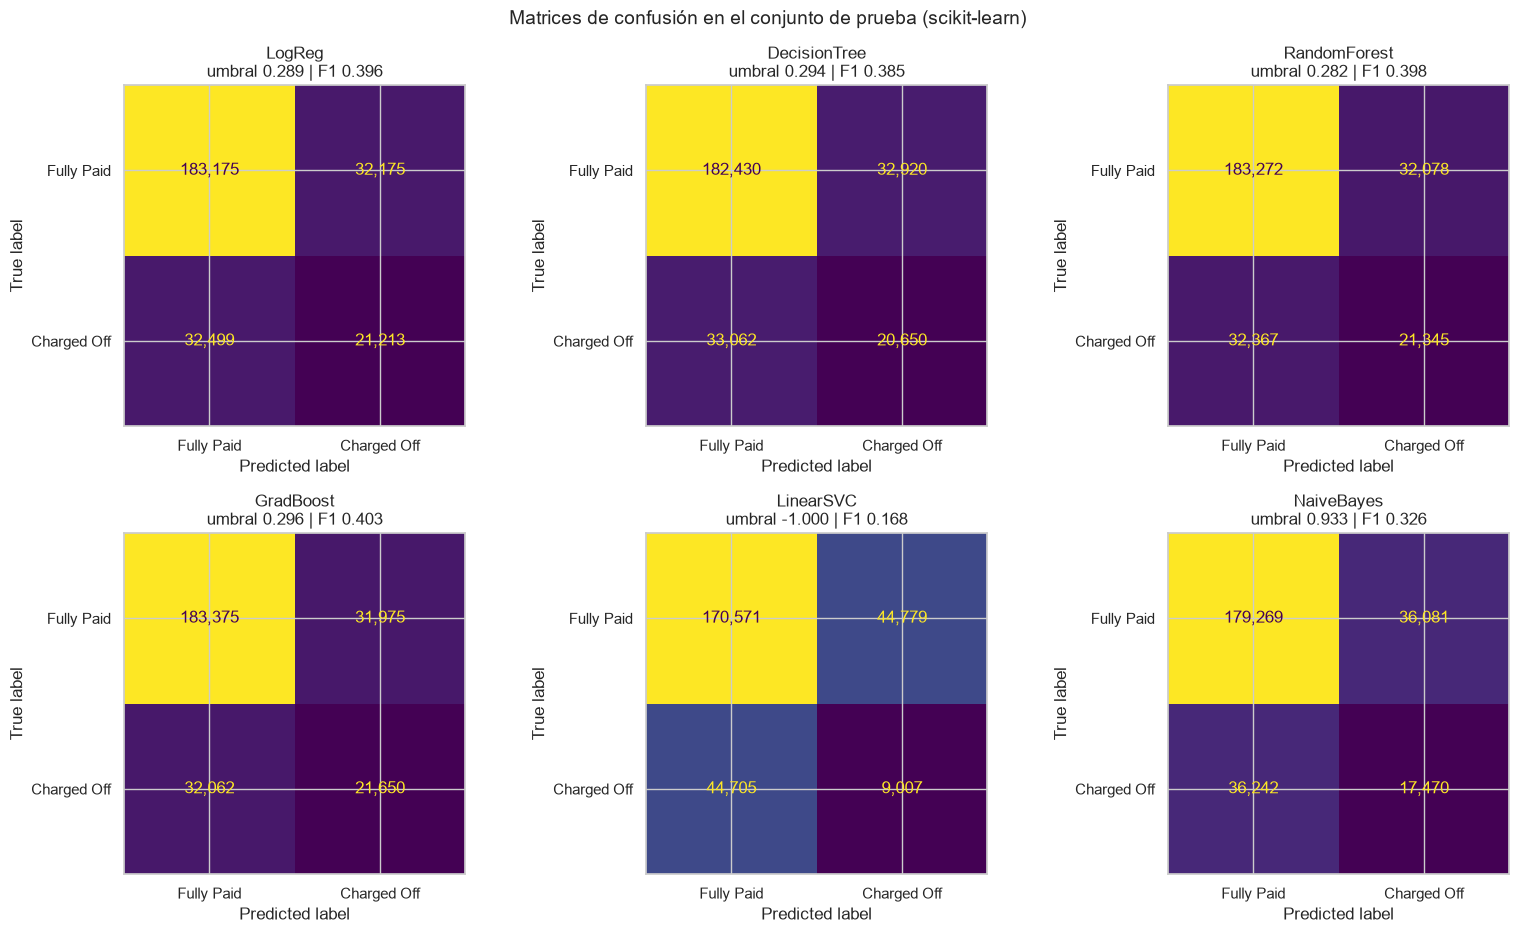

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for ax, name in zip(axes.flat, U.MODELS):
    pred = (test_scores[name] >= results[name]["threshold"]).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Fully Paid", "Charged Off"]).plot(ax=ax, colorbar=False, values_format=",")
    ax.set_title(f"{name}\numbral {results[name]['threshold']:.3f} | F1 {results[name]['test']['f1']:.3f}")
fig.suptitle("Matrices de confusión en el conjunto de prueba (scikit-learn)", fontsize=14)
plt.tight_layout()
plt.show()

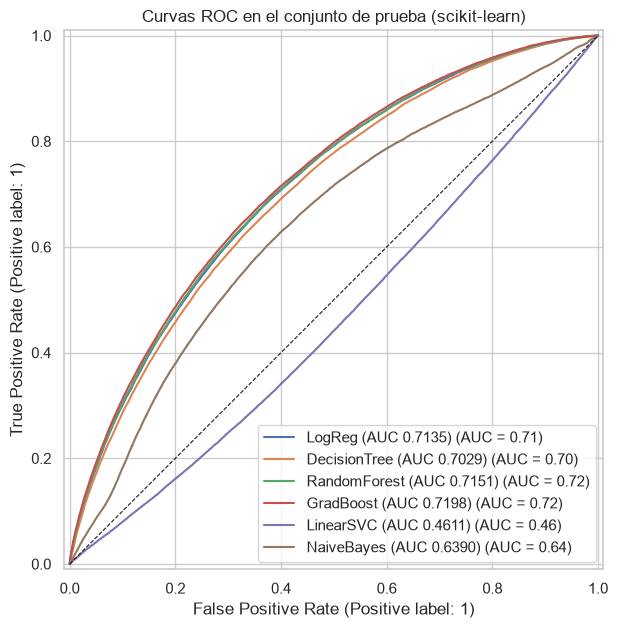

In [68]:
fig, ax = plt.subplots(figsize=(8, 7))
for name in U.MODELS:
    RocCurveDisplay.from_predictions(y_test, test_scores[name], ax=ax,
                                     name=f"{name} (AUC {results[name]['test']['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("Curvas ROC en el conjunto de prueba (scikit-learn)")
plt.show()

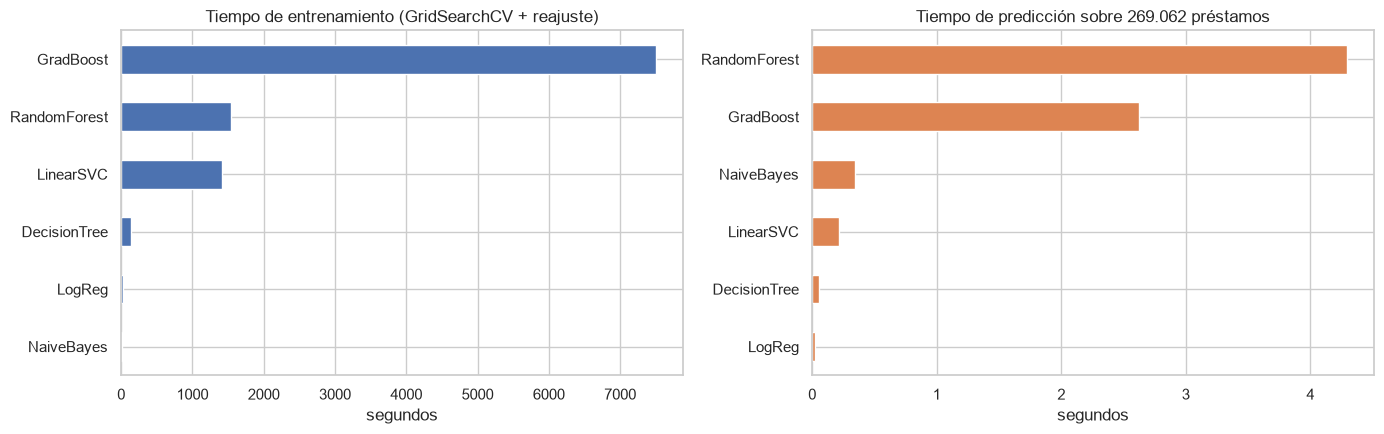

,entrenamiento con validación cruzada,predicción (test)
LogReg,25.37,0.02
DecisionTree,136.17,0.05
RandomForest,1544.83,4.30
GradBoost,7506.05,2.63
LinearSVC,1412.73,0.21
NaiveBayes,12.41,0.34


In [69]:
tt = pd.DataFrame({"entrenamiento con validación cruzada": {n: r["train_time_s"] for n, r in results.items()},
                   "predicción (test)": {n: r["predict_time_s"] for n, r in results.items()}})
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tt["entrenamiento con validación cruzada"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("segundos")
axes[0].set_title("Tiempo de entrenamiento (GridSearchCV + reajuste)")
tt["predicción (test)"].sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_xlabel("segundos")
axes[1].set_title("Tiempo de predicción sobre 269.062 préstamos")
plt.tight_layout()
plt.show()
tt.round(2)

## 3.6 Diagnóstico de `LinearSVC(loss="hinge")`

scikit-learn solo resuelve la pérdida hinge mediante el **problema dual** (liblinear, descenso por coordenadas). Además, liblinear **regulariza el intercepto**, que trata como una variable más con valor `intercept_scaling=1`. Para entender el resultado de LinearSVC, se compara con dos referencias entrenadas en todo el conjunto de entrenamiento. **No forman parte de los seis modelos**:

* `SGDClassifier(loss="hinge", alpha=regParam)`: la misma pérdida hinge optimizada en el **primal** y sin regularizar el intercepto. Es la formulación más cercana a la de Spark.
* `LinearSVC(loss="squared_hinge", dual=False)`: la pérdida por defecto de scikit-learn, resuelta en el primal.

In [70]:
best_reg = 1 / (results["LinearSVC"]["best_params"]["C"] * n_train)
svc = joblib.load(U.MODELS_SK_DIR / "LinearSVC.joblib")
refs = {
    "LinearSVC hinge (dual, modelo del proyecto)": svc,
    "SGDClassifier hinge (primal)": SGDClassifier(loss="hinge", alpha=best_reg, max_iter=50, tol=1e-4,
                                                  random_state=U.SEED).fit(X_train, y_train),
    "LinearSVC squared_hinge (primal)": LinearSVC(loss="squared_hinge", dual=False,
                                                  C=results["LinearSVC"]["best_params"]["C"]).fit(X_train, y_train),
}
diag = []
for name, m in refs.items():
    s = m.decision_function(X_test)
    diag.append({"modelo": name, "AUC test": roc_auc_score(y_test, s), "‖w‖": np.linalg.norm(m.coef_),
                 "intercepto": float(np.ravel(m.intercept_)[0]), "% test con decisión > 0": 100 * (s > 0).mean()})
pd.DataFrame(diag).set_index("modelo").round(4)

,AUC test,‖w‖,intercepto,% test con decisión > 0
modelo,,,,
"LinearSVC hinge (dual, modelo del proyecto)",0.4611,0.4624,-0.3098,0.0000
SGDClassifier hinge (primal),0.6273,9.5938,-15.5710,0.3304
LinearSVC squared_hinge (primal),0.7135,0.5505,-0.1767,1.2759


## 3.7 Resumen del capítulo

El mejor desempeño en scikit-learn corresponde a `GradientBoostingClassifier` con 100 árboles de profundidad 5, que en el conjunto de prueba alcanza un AUC de 0,7198, un AUC-PR de 0,3885 y un F1 de 0,403. Le siguen el bosque aleatorio (0,7151) y la regresión logística (0,7135). La ventaja de los modelos no lineales sobre el modelo lineal es de apenas 0,006 puntos de AUC, un resultado coherente con el EDA: la señal predictiva se concentra en unas pocas variables (`int_rate`, `term` y el puntaje FICO) cuya relación con el default es esencialmente monótona y aditiva, y un modelo lineal ya la captura en su mayor parte. En todos los modelos, salvo LinearSVC, el AUC de validación cruzada difiere del de prueba en menos de 0,003, lo que confirma que la validación fue un estimador fiable del desempeño fuera de muestra y que la partición aleatoria estratificada produjo conjuntos con la misma distribución. El único sobreajuste apreciable es el del bosque de profundidad 15, cuyo AUC de entrenamiento (0,782) supera en 0,067 al de prueba. La validación cruzada lo selecciona igualmente porque su desempeño de validación sigue siendo el mejor de su espacio de búsqueda.

La elección del umbral resulta determinante para las métricas de clasificación. Con el umbral convencional de 0,5, el recall en prueba se sitúa entre el 3 % y el 9 %, porque los modelos rara vez asignan probabilidades superiores a 0,5 a un problema con 20 % de prevalencia. El umbral fijado en entrenamiento, que iguala la tasa de positivos predichos con la prevalencia, equilibra la precisión y el recall en torno a 0,40 en los mejores modelos. Naive Bayes requiere un umbral de 0,93, síntoma de probabilidades mal calibradas: el supuesto de independencia condicional se viola con variables tan correlacionadas como las de este problema.

LinearSVC con pérdida hinge obtiene un AUC de 0,461, inferior al de un clasificador aleatorio, y su función de decisión es negativa para todos los préstamos. El diagnóstico de la sección 3.6 permite separar dos causas. La primera es propia de la pérdida: con clases muy solapadas y desbalanceadas, el óptimo de la pérdida hinge tiende a una solución casi degenerada, con coeficientes cercanos a cero y un intercepto que clasifica a todos los casos como pagados. La segunda es propia del optimizador: la formulación dual de liblinear, que además regulariza el intercepto, no conserva la dirección de los coeficientes que ordena correctamente a los prestatarios. La misma pérdida optimizada en el primal (`SGDClassifier`) recupera un AUC de 0,627, y la pérdida hinge al cuadrado alcanza 0,7135, prácticamente igual que la regresión logística. En este caso, la validación cruzada solo pudo escoger el valor de $C$ menos desfavorable entre alternativas igualmente inadecuadas.

En términos de cómputo, el entrenamiento completo con validación cruzada tomó 2 h 57 min, de los cuales el 71 % (2 h 5 min) correspondió a gradient boosting. `GradientBoostingClassifier` construye cada árbol de forma secuencial y en un solo hilo, de modo que el único paralelismo disponible es el que ofrece `GridSearchCV` al ajustar simultáneamente combinaciones y pliegues. LinearSVC consumió 24 minutos porque el dual no converge con $C = 0{,}93$, mientras que la regresión logística y Naive Bayes requirieron segundos. En la prueba preliminar, `HistGradientBoostingClassifier` entrenó 100 iteraciones en 22 segundos, con un AUC de validación de 0,718, frente a unos 11 minutos del ajuste equivalente con `GradientBoostingClassifier`. Aunque el enunciado admitía esa sustitución, se conservó el estimador original por fidelidad a la especificación. La diferencia de tiempos se retoma en la reflexión final.

# 4. Modelado con PySpark

Este capítulo corresponde a la sección 9.10.4.5 del proyecto. Se entrenan los mismos seis modelos con `pyspark.ml.classification`, con los mismos espacios de búsqueda y el mismo criterio de selección (ROC AUC). Se respetan todas las condiciones del enunciado:

* **Búsqueda de hiperparámetros:** exclusivamente con `ParamGridBuilder` y `CrossValidator(numFolds=3)`, sin bucles manuales sobre combinaciones.
* **Criterio de selección:** `BinaryClassificationEvaluator(metricName="areaUnderROC")`.
* **Configuración:** la `SparkSession` obligatoria (`spark.sql.shuffle.partitions=400`, `spark.default.parallelism=400`, `spark.driver.memory=8g`, …).
* **Datos:**
  * se lee el CSV completo;
  * se usa la partición común (`split.parquet`), no `randomSplit`;
  * los DataFrames se cachean después del `VectorAssembler`.
* **Transferencia al driver:** no se usa `.toPandas()` ni `.collect()` sobre el dataset. Solo al terminar el entrenamiento y la predicción se transfieren las columnas `id`, `default` y la puntuación del conjunto de prueba, y ese tiempo se reporta por separado.

**Dos decisiones de ejecución**, justificadas en la sección 4.6:

1. **12 particiones.** Los DataFrames de modelado se reducen con `coalesce` a **12 particiones**, una por núcleo lógico, antes de cachearlos. La configuración de la sesión no cambia.
2. **`cacheNodeIds=True`** en los modelos de árbol.

En una primera ejecución con las 400 particiones heredadas de `spark.sql.shuffle.partitions`, la regresión logística tardó 40 minutos y el árbol de decisión 31. El bosque aleatorio avanzó 7 de 27 ajustes en 1 h 38 min, hasta que la JVM se quedó sin memoria y se cayó. Además, **cada modelo se entrena en una sesión de Spark (JVM) nueva** y sus resultados se guardan al terminar, para que un fallo de memoria en un modelo no invalide los demás.

In [71]:
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark import StorageLevel
from pyspark.ml.classification import (DecisionTreeClassifier, GBTClassifier, LinearSVC, LogisticRegression,
                                       NaiveBayes, RandomForestClassifier)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import functions as F

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
U.SPARK_PARTIAL_DIR.mkdir(exist_ok=True)
lab, feat = U.TARGET, "features"

## 4.1 Sesión de Spark, hardware y datos

Se usa el mismo equipo que en scikit-learn. Spark corre en modo `local[*]`: un único proceso JVM que actúa como driver y ejecutor y usa todos los núcleos lógicos. Por eso `spark.executor.memory` no tiene efecto y la memoria disponible la fija `spark.driver.memory=8g`.

In [72]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
display(pd.Series(timings["hardware"], name="valor").to_frame())

spark = U.spark_session()
conf = dict(spark.sparkContext.getConf().getAll())
print("Spark", spark.version, "| master:", spark.sparkContext.master)
print({k: conf[k] for k in ["spark.sql.shuffle.partitions", "spark.default.parallelism", "spark.executor.memory",
                            "spark.driver.memory", "spark.memory.fraction", "spark.memory.storageFraction"]})

t0 = time.time()
res = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)
t_prep = time.time() - t0
train, test = res["train"], res["test"]
prevalence = train.agg(F.mean(lab)).first()[0]
print(f"train {res['n_train']:,} | test {res['n_test']:,} | preprocesamiento {t_prep:.1f} s | particiones: "
      f"train {train.rdd.getNumPartitions()}, test {test.rdd.getNumPartitions()} | cacheados: {train.is_cached}, {test.is_cached}")
print(f"prevalencia de default en train = {prevalence:.4f}")
U.spark_shutdown(spark)

,valor
procesador,"Intel64 Family 6 Model 154 Stepping 4, Genuine..."
núcleos físicos,10
núcleos lógicos,12
RAM total (GB),16.8
sistema,Windows 10
Python,3.11.16
Spark,3.5.5


Spark 3.5.5 | master: local[*]
{'spark.sql.shuffle.partitions': '400', 'spark.default.parallelism': '400', 'spark.executor.memory': '8g', 'spark.driver.memory': '8g', 'spark.memory.fraction': '0.8', 'spark.memory.storageFraction': '0.3'}


train 1,076,248 | test 269,062 | preprocesamiento 100.6 s | particiones: train 12, test 12 | cacheados: True, True
prevalencia de default en train = 0.1996


## 4.2 Modelos, espacios de búsqueda y equivalencias

| Modelo | Clase de `pyspark.ml.classification` | Espacio de búsqueda | Parámetros fijos |
|---|---|---|---|
| Regresión logística | `LogisticRegression` | `regParam` $\in \{10^{-6}, 10^{-5}, 10^{-4}\}$ | `elasticNetParam=0` (L2), `standardization=False` |
| Árbol de decisión | `DecisionTreeClassifier` | `maxDepth` $\in \{5, 10, 15\}$ | `maxBins=32`, `seed=42`, `cacheNodeIds=True` |
| Bosque aleatorio | `RandomForestClassifier` | `numTrees` $\in \{10, 50, 100\}$ × `maxDepth` $\in \{5, 10, 15\}$ | `maxBins=32`, `seed=42`, `cacheNodeIds=True` |
| Gradient boosting | `GBTClassifier` | `maxIter` $\in \{50, 100\}$ × `maxDepth` $\in \{3, 5\}$ | `stepSize=0.1`, `maxBins=32`, `seed=42`, `cacheNodeIds=True` |
| SVM lineal | `LinearSVC` | `regParam` $\in \{10^{-6}, 10^{-5}, 10^{-4}\}$ | `standardization=False` |
| Naive Bayes | `NaiveBayes` | sin búsqueda | `modelType="gaussian"` |

`cacheNodeIds=True` **no cambia el modelo**. En cada nivel del árbol, Spark tiene que saber en qué nodo cae cada fila. Por defecto lo recalcula recorriendo el árbol parcial para cada fila; con `cacheNodeIds` guarda ese identificador en un RDD cacheado y solo lo actualiza. El ahorro crece con la profundidad.

**Consideraciones de equivalencia con scikit-learn**

* **Regularización.** Ambos entornos usan L2 (`elasticNetParam=0` en Spark). Spark minimiza $\tfrac1n\sum\ell_i + \tfrac{\lambda}{2}\lVert w\rVert^2$ y scikit-learn $C\sum\ell_i + \tfrac12\lVert w\rVert^2$. La relación $C = 1/(\lambda n)$ es aproximada: $C$ pondera la *suma* de las pérdidas y `regParam` su *promedio*, y en validación cruzada cada pliegue tiene $2n/3$ filas.
* **`standardization=False`.** Por defecto, Spark estandariza internamente **todas** las columnas, dummies incluidas, antes de aplicar la penalización. scikit-learn penaliza los coeficientes en la escala en que recibe los datos. Como las numéricas ya llegan estandarizadas (capítulo 2), se desactiva la estandarización interna para que la penalización actúe sobre la misma escala en ambos entornos.
* **Intercepto.** Ninguno de los dos entornos lo regulariza en la regresión logística. En LinearSVC, liblinear (scikit-learn) sí lo regulariza y Spark no (ver sección 3.6).
* **LinearSVC.** Spark minimiza la pérdida hinge en el primal con OWL-QN. scikit-learn usa `loss="hinge"`, que solo admite el dual de liblinear.
* **Árboles.** Spark discretiza cada variable continua en a lo sumo `maxBins=32` intervalos (cuantiles aproximados) y solo evalúa cortes en esos bordes; scikit-learn evalúa todos los cortes exactos. Además, `featureSubsetStrategy="auto"` (raíz cuadrada del número de variables) y el *bootstrap* equivalen a los valores por defecto de `RandomForestClassifier` en scikit-learn.
* **Naive Bayes.** Se usa la variante gaussiana, porque la multinomial y la de Bernoulli no admiten los valores negativos que produce el `StandardScaler`.
* **Pliegues.** `CrossValidator(seed=42)` asigna los pliegues al azar. Los pliegues no coinciden con los de `StratifiedKFold` de scikit-learn, pero el conjunto de prueba sí es el mismo.

In [73]:
TREE_FIXED = dict(maxBins=32, seed=U.SEED, cacheNodeIds=True)

def make_spec(name):
    # Los estimadores de Spark se crean dentro de cada sesión (envuelven un objeto de la JVM).
    if name == "LogReg":
        est = LogisticRegression(featuresCol=feat, labelCol=lab, elasticNetParam=0.0, standardization=False, maxIter=100)
        return est, ParamGridBuilder().addGrid(est.regParam, U.REG_PARAMS).build()
    if name == "DecisionTree":
        est = DecisionTreeClassifier(featuresCol=feat, labelCol=lab, **TREE_FIXED)
        return est, ParamGridBuilder().addGrid(est.maxDepth, [5, 10, 15]).build()
    if name == "RandomForest":
        est = RandomForestClassifier(featuresCol=feat, labelCol=lab, **TREE_FIXED)
        return est, ParamGridBuilder().addGrid(est.numTrees, [10, 50, 100]).addGrid(est.maxDepth, [5, 10, 15]).build()
    if name == "GradBoost":
        est = GBTClassifier(featuresCol=feat, labelCol=lab, stepSize=0.1, **TREE_FIXED)
        return est, ParamGridBuilder().addGrid(est.maxIter, [50, 100]).addGrid(est.maxDepth, [3, 5]).build()
    if name == "LinearSVC":
        est = LinearSVC(featuresCol=feat, labelCol=lab, standardization=False, maxIter=100)
        return est, ParamGridBuilder().addGrid(est.regParam, U.REG_PARAMS).build()
    if name == "NaiveBayes":
        est = NaiveBayes(featuresCol=feat, labelCol=lab, modelType="gaussian")
        return est, ParamGridBuilder().build()   # una sola combinación: configuración por defecto

n_combos = {"LogReg": 3, "DecisionTree": 3, "RandomForest": 9, "GradBoost": 4, "LinearSVC": 3, "NaiveBayes": 1}
pd.DataFrame({n: {"combinaciones": k, "ajustes en CV (3 pliegues) + reajuste": 3 * k + 1} for n, k in n_combos.items()}).T

,combinaciones,ajustes en CV (3 pliegues) + reajuste
LogReg,3,10
DecisionTree,3,10
RandomForest,9,28
GradBoost,4,13
LinearSVC,3,10
NaiveBayes,1,4


## 4.3 Entrenamiento con `CrossValidator`

Para cada modelo, en una sesión de Spark nueva:

1. **Preprocesamiento.** Se lee el CSV y se aplica el `Pipeline` del capítulo 2, ajustado con train. Su tiempo se registra aparte y no se suma al entrenamiento.
2. **Validación cruzada.** `CrossValidator(numFolds=3, seed=42)` evalúa cada combinación con `BinaryClassificationEvaluator(areaUnderROC)` y reajusta la mejor con todo el conjunto de entrenamiento. El **tiempo de entrenamiento** incluye la validación cruzada completa.
3. **Puntuación continua.** Es el segundo elemento de la columna `probability` o, en LinearSVC, de `rawPrediction`, extraído con `vector_to_array`. El `BinaryClassificationEvaluator` se configura sobre esa misma columna.
4. **Predicción.** Se transforma el conjunto de prueba y se materializa en caché con `count()`. Por la evaluación perezosa de Spark, esto es lo que obliga a calcular todas las predicciones, y define el **tiempo de predicción**.
5. **Umbral.** Se aplica el mismo criterio que en scikit-learn: el cuantil $1-\pi$ de las puntuaciones de train, calculado con `approxQuantile` (error relativo $10^{-4}$) sin salir de Spark.
6. **Métricas.** Accuracy, precision, recall y F1 se obtienen de la matriz de confusión, calculada con una agregación distribuida. ROC AUC y AUC-PR se calculan con `BinaryClassificationEvaluator`.
7. **Transferencia.** Se transfieren al driver **solo** `id`, `default` y la puntuación del conjunto de prueba (269.062 × 3 valores), con un tiempo medido aparte.
8. **Guardado.** Los resultados del modelo se guardan en `data/pyspark_by_model/`. Si el notebook se vuelve a ejecutar y el archivo de un modelo ya existe, se carga en lugar de reentrenarlo, con sus tiempos originales. La salida indica en cada caso si el modelo se entrenó o se cargó.

In [74]:
def score_col(name):
    return (vector_to_array("rawPrediction")[1] if name == "LinearSVC" else vector_to_array("probability")[1]).alias("score")


def spark_metrics(scored, thr):
    # Matriz de confusión con una sola agregación distribuida; al driver llegan 4 números.
    pred = (F.col("score") >= F.lit(thr)).cast("int")
    y = F.col(lab)
    c = scored.agg(
        F.sum(((pred == 1) & (y == 1)).cast("long")).alias("tp"), F.sum(((pred == 1) & (y == 0)).cast("long")).alias("fp"),
        F.sum(((pred == 0) & (y == 0)).cast("long")).alias("tn"), F.sum(((pred == 0) & (y == 1)).cast("long")).alias("fn"),
    ).first().asDict()
    tp, fp, tn, fn = (c[k] for k in ["tp", "fp", "tn", "fn"])
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn)
    ev = BinaryClassificationEvaluator(rawPredictionCol="score", labelCol=lab)
    return {
        "accuracy": (tp + tn) / (tp + fp + tn + fn), "precision": prec, "recall": rec,
        "f1": 2 * prec * rec / (prec + rec) if prec + rec else 0.0,
        "roc_auc": ev.setMetricName("areaUnderROC").evaluate(scored),
        "pr_auc": ev.setMetricName("areaUnderPR").evaluate(scored),
        "confusion": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    }


def param_str(pm):
    return {p.name: pm[p] for p in pm}


def train_one(name):
    spark = U.spark_session()
    t0 = time.time()
    res = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)
    t_prep = time.time() - t0
    train, test = res["train"], res["test"]
    prevalence = train.agg(F.mean(lab)).first()[0]

    est, grid = make_spec(name)
    evaluator = BinaryClassificationEvaluator(labelCol=lab, metricName="areaUnderROC",
                                              rawPredictionCol="rawPrediction" if name == "LinearSVC" else "probability")
    cv = CrossValidator(estimator=est, estimatorParamMaps=grid, evaluator=evaluator, numFolds=3, seed=U.SEED)
    t0 = time.time()
    cv_model = cv.fit(train)
    t_train = time.time() - t0
    best_model = cv_model.bestModel

    t0 = time.time()
    test_scored = best_model.transform(test).select("id", lab, score_col(name)).persist(StorageLevel.MEMORY_AND_DISK)
    test_scored.count()
    t_pred = time.time() - t0

    train_scored = best_model.transform(train).select(lab, score_col(name)).persist(StorageLevel.MEMORY_AND_DISK)
    thr = train_scored.approxQuantile("score", [1 - prevalence], 1e-4)[0]
    i_best = int(np.argmax(cv_model.avgMetrics))
    out = {
        "best_params": param_str(grid[i_best]), "cv_auc": cv_model.avgMetrics[i_best],
        "preprocess_time_s": t_prep, "train_time_s": t_train, "predict_time_s": t_pred,
        "threshold": thr, "default_threshold": 0.0 if name == "LinearSVC" else 0.5,
        "train": spark_metrics(train_scored, thr), "test": spark_metrics(test_scored, thr),
        "cv_table": {"params": [str(param_str(pm) or "(por defecto)") for pm in grid],
                     "auc_mean": list(cv_model.avgMetrics), "auc_std": list(cv_model.stdMetrics)},
    }
    out["test_default_threshold"] = spark_metrics(test_scored, out["default_threshold"])

    # Transferencia permitida: solo id, default y la puntuación del conjunto de prueba.
    t0 = time.time()
    local = test_scored.toPandas().rename(columns={"score": name})
    out["transfer_time_s"] = time.time() - t0
    U.spark_shutdown(spark)
    return out, local


results, test_local = {}, None
for name in U.MODELS:
    f_json, f_pq = U.SPARK_PARTIAL_DIR / f"{name}.json", U.SPARK_PARTIAL_DIR / f"{name}.parquet"
    if f_json.exists() and f_pq.exists():
        r, local = json.loads(f_json.read_text()), pd.read_parquet(f_pq)
        origin = "cargado de data/pyspark_by_model (tiempos de su ejecución original)"
    else:
        r, local = train_one(name)
        f_json.write_text(json.dumps(r, indent=2, default=float))
        local.to_parquet(f_pq, index=False)
        origin = "entrenado en esta ejecución"
    results[name] = r
    test_local = local if test_local is None else test_local.merge(local.drop(columns=lab), on="id")
    print(f"{name:13s} entrenamiento {r['train_time_s']:7.1f} s | predicción {r['predict_time_s']:5.1f} s | "
          f"transferencia {r['transfer_time_s']:4.1f} s | AUC CV {r['cv_auc']:.4f} | AUC test {r['test']['roc_auc']:.4f} "
          f"| {r['best_params']} | {origin}", flush=True)

test_local = test_local.sort_values("id").reset_index(drop=True)
test_local.to_parquet(U.SCORES_SPARK, index=False)
_ = U.RESULTS_SPARK.write_text(json.dumps(results, indent=2, default=float))

LogReg        entrenamiento   662.9 s | predicción   1.4 s | transferencia  2.7 s | AUC CV 0.7133 | AUC test 0.7135 | {'regParam': 0.0001} | cargado de data/pyspark_by_model (tiempos de su ejecución original)


DecisionTree  entrenamiento   219.3 s | predicción   1.3 s | transferencia  2.3 s | AUC CV 0.7002 | AUC test 0.7002 | {'maxDepth': 10} | cargado de data/pyspark_by_model (tiempos de su ejecución original)


RandomForest  entrenamiento  6306.3 s | predicción 100.5 s | transferencia 28.2 s | AUC CV 0.7139 | AUC test 0.7137 | {'numTrees': 100, 'maxDepth': 15} | cargado de data/pyspark_by_model (tiempos de su ejecución original)


GradBoost     entrenamiento  4845.5 s | predicción   3.7 s | transferencia  4.4 s | AUC CV 0.7187 | AUC test 0.7195 | {'maxIter': 100, 'maxDepth': 5} | entrenado en esta ejecución


LinearSVC     entrenamiento  1268.9 s | predicción   1.3 s | transferencia  2.0 s | AUC CV 0.6381 | AUC test 0.6300 | {'regParam': 1e-06} | entrenado en esta ejecución


NaiveBayes    entrenamiento   174.2 s | predicción   1.3 s | transferencia  2.0 s | AUC CV 0.6400 | AUC test 0.6395 | {} | entrenado en esta ejecución


## 4.4 Resultados de la validación cruzada

In [75]:
cv_all = pd.concat({n: pd.DataFrame({"hiperparámetros": r["cv_table"]["params"], "AUC CV medio": r["cv_table"]["auc_mean"],
                                     "desv. AUC CV": r["cv_table"]["auc_std"]}) for n, r in results.items()},
                   names=["modelo", "i"]).reset_index(level=1, drop=True)
cv_all.style.format({"AUC CV medio": "{:.4f}", "desv. AUC CV": "{:.4f}"})

,hiperparámetros,AUC CV medio,desv. AUC CV
modelo,,,
LogReg,{'regParam': 1e-06},0.7132,0.0003
LogReg,{'regParam': 1e-05},0.7132,0.0003
LogReg,{'regParam': 0.0001},0.7133,0.0003
DecisionTree,{'maxDepth': 5},0.6501,0.0070
DecisionTree,{'maxDepth': 10},0.7002,0.0009
DecisionTree,{'maxDepth': 15},0.6739,0.0011
RandomForest,"{'numTrees': 10, 'maxDepth': 5}",0.6689,0.0028
RandomForest,"{'numTrees': 10, 'maxDepth': 10}",0.7015,0.0002
RandomForest,"{'numTrees': 10, 'maxDepth': 15}",0.7038,0.0004


In [76]:
pd.DataFrame({
    n: {"mejores hiperparámetros": r["best_params"] or "(por defecto)", "AUC CV": r["cv_auc"],
        "tiempo de entrenamiento (s)": r["train_time_s"], "tiempo de predicción (s)": r["predict_time_s"],
        "tiempo de transferencia (s)": r["transfer_time_s"], "umbral (train)": r["threshold"]}
    for n, r in results.items()}).T

,mejores hiperparámetros,AUC CV,tiempo de entrenamiento (s),tiempo de predicción (s),tiempo de transferencia (s),umbral (train)
LogReg,{'regParam': 0.0001},0.713251,662.915215,1.359995,2.720584,0.288995
DecisionTree,{'maxDepth': 10},0.700155,219.311822,1.343633,2.283455,0.286603
RandomForest,"{'numTrees': 100, 'maxDepth': 15}",0.713913,6306.320292,100.522244,28.213332,0.28032
GradBoost,"{'maxIter': 100, 'maxDepth': 5}",0.718749,4845.499149,3.688366,4.405245,0.294094
LinearSVC,{'regParam': 1e-06},0.638122,1268.877505,1.293345,2.042808,-1.0
NaiveBayes,(por defecto),0.640016,174.221719,1.31417,2.025078,0.933944


## 4.5 Métricas en entrenamiento y prueba

Las métricas de esta tabla se calculan íntegramente en Spark. `BinaryClassificationEvaluator` estima el área bajo la curva con un máximo de 1000 umbrales (`numBins`), así que su AUC es una aproximación muy cercana al exacto. Las pruebas estadísticas del capítulo 5 usan el AUC exacto, calculado con las puntuaciones transferidas. Por eso, al final de esta sección se comparan ambos.

In [77]:
def metrics_table(key):
    return pd.DataFrame({n: {k: v for k, v in r[key].items() if k != "confusion"} for n, r in results.items()}).T

metrics = pd.concat({"train": metrics_table("train"), "test": metrics_table("test")}, axis=1)
metrics.style.format("{:.4f}").highlight_max(axis=0, subset=[("test", "roc_auc"), ("test", "pr_auc"), ("test", "f1")],
                                             props="font-weight: bold; background-color: #d9ead3")

In [78]:
print("Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):")
metrics_table("test_default_threshold").style.format("{:.4f}")

Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):


,accuracy,precision,recall,f1,roc_auc,pr_auc
LogReg,0.8025,0.5319,0.0867,0.1491,0.7135,0.3768
DecisionTree,0.8008,0.5083,0.0707,0.1242,0.7002,0.3577
RandomForest,0.8025,0.5970,0.0320,0.0608,0.7137,0.3788
GradBoost,0.8036,0.5523,0.0850,0.1473,0.7195,0.3871
LinearSVC,0.8004,0.0000,0.0000,0.0000,0.6300,0.3004
NaiveBayes,0.6355,0.2917,0.5780,0.3877,0.6395,0.2834


In [79]:
from sklearn.metrics import roc_auc_score

auc_check = pd.DataFrame({
    "AUC Spark (evaluador, numBins=1000)": {n: results[n]["test"]["roc_auc"] for n in U.MODELS},
    "AUC exacto (puntuaciones transferidas)": {n: roc_auc_score(test_local[U.TARGET], test_local[n]) for n in U.MODELS},
})
auc_check["diferencia"] = auc_check.iloc[:, 0] - auc_check.iloc[:, 1]
auc_check.style.format("{:.5f}")

,"AUC Spark (evaluador, numBins=1000)",AUC exacto (puntuaciones transferidas),diferencia
LogReg,0.71348,0.71348,-0.00000
DecisionTree,0.70020,0.70020,0.00000
RandomForest,0.71372,0.71372,-0.00000
GradBoost,0.71946,0.71946,0.00000
LinearSVC,0.62996,0.62996,0.00000
NaiveBayes,0.63945,0.63946,-0.00000


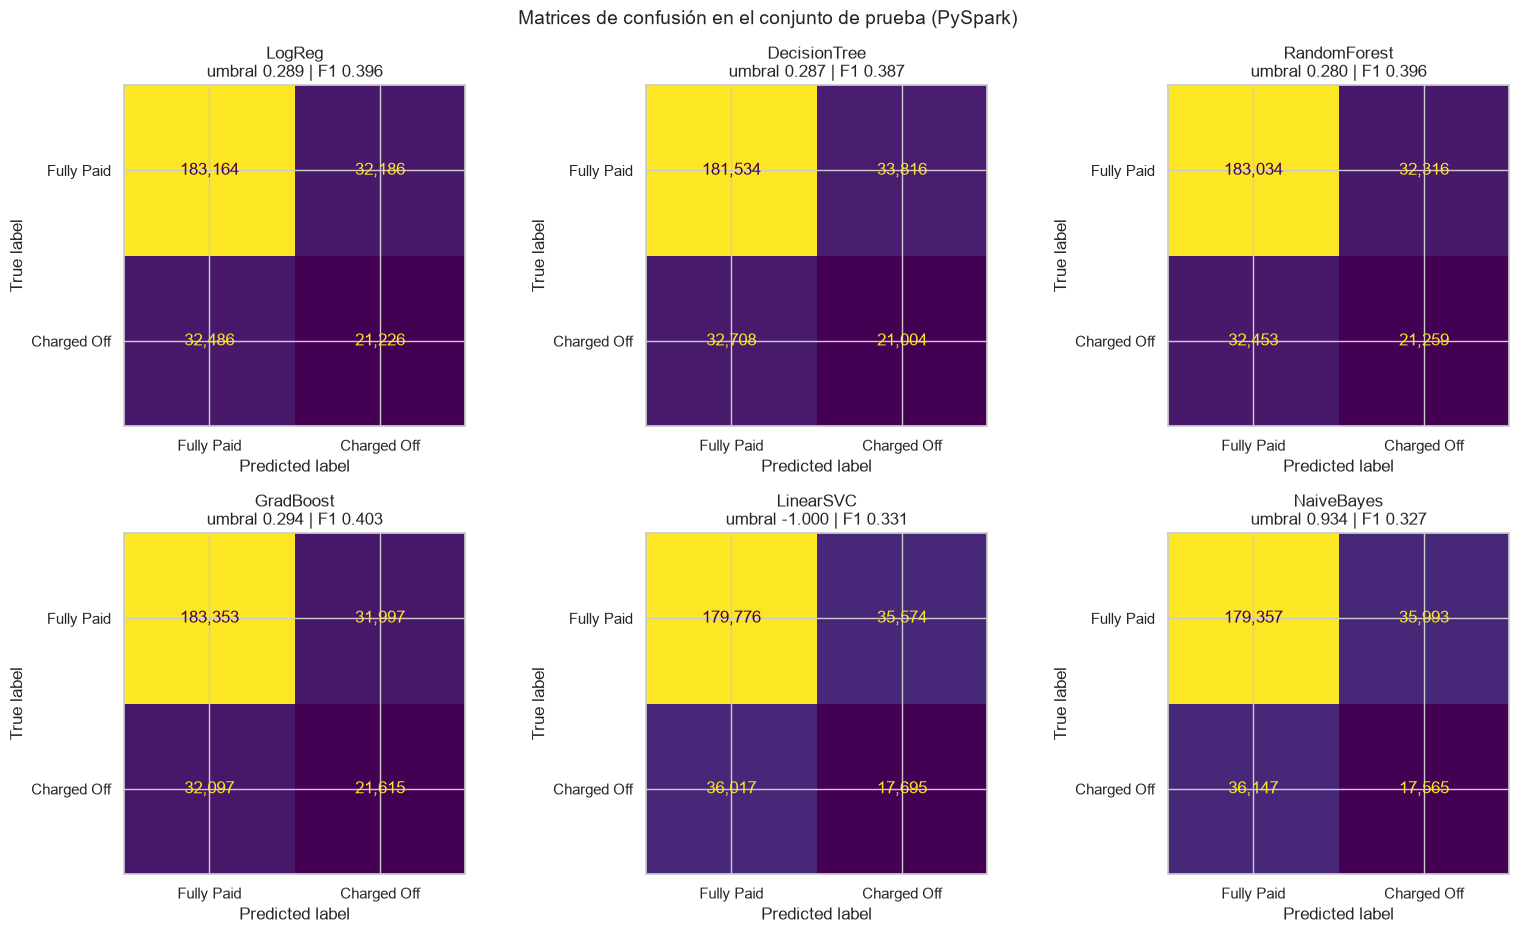

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for ax, name in zip(axes.flat, U.MODELS):
    c = results[name]["test"]["confusion"]
    cm = np.array([[c["tn"], c["fp"]], [c["fn"], c["tp"]]])
    ConfusionMatrixDisplay(cm, display_labels=["Fully Paid", "Charged Off"]).plot(ax=ax, colorbar=False, values_format=",")
    ax.set_title(f"{name}\numbral {results[name]['threshold']:.3f} | F1 {results[name]['test']['f1']:.3f}")
fig.suptitle("Matrices de confusión en el conjunto de prueba (PySpark)", fontsize=14)
plt.tight_layout()
plt.show()

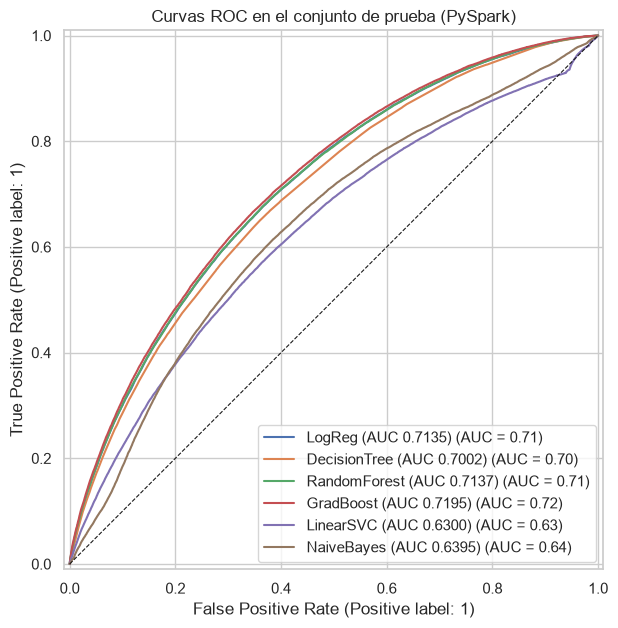

In [81]:
fig, ax = plt.subplots(figsize=(8, 7))
for name in U.MODELS:
    RocCurveDisplay.from_predictions(test_local[U.TARGET], test_local[name], ax=ax,
                                     name=f"{name} (AUC {auc_check.loc[name].iloc[1]:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("Curvas ROC en el conjunto de prueba (PySpark)")
plt.show()

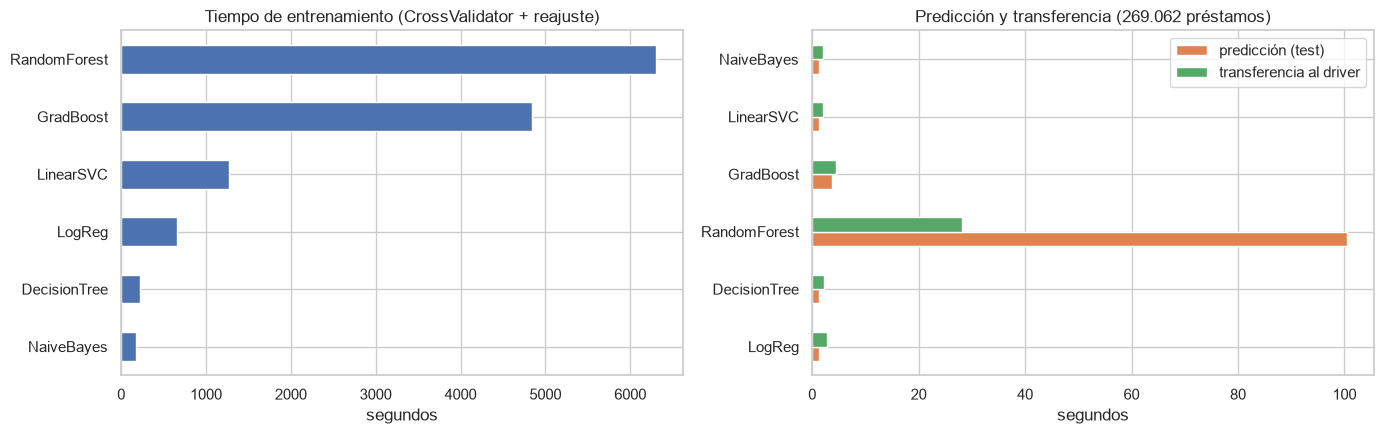

,entrenamiento con validación cruzada,predicción (test),transferencia al driver,preprocesamiento (en cada sesión)
LogReg,662.92,1.36,2.72,112.85
DecisionTree,219.31,1.34,2.28,164.86
RandomForest,6306.32,100.52,28.21,165.35
GradBoost,4845.50,3.69,4.41,103.41
LinearSVC,1268.88,1.29,2.04,177.14
NaiveBayes,174.22,1.31,2.03,112.36


In [82]:
tt = pd.DataFrame({"entrenamiento con validación cruzada": {n: r["train_time_s"] for n, r in results.items()},
                   "predicción (test)": {n: r["predict_time_s"] for n, r in results.items()},
                   "transferencia al driver": {n: r["transfer_time_s"] for n, r in results.items()},
                   "preprocesamiento (en cada sesión)": {n: r["preprocess_time_s"] for n, r in results.items()}})
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tt["entrenamiento con validación cruzada"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("segundos")
axes[0].set_title("Tiempo de entrenamiento (CrossValidator + reajuste)")
tt[["predicción (test)", "transferencia al driver"]].plot.barh(ax=axes[1], color=["#DD8452", "#55A868"])
axes[1].set_xlabel("segundos")
axes[1].set_title("Predicción y transferencia (269.062 préstamos)")
plt.tight_layout()
plt.show()
tt.round(2)

## 4.6 Efecto de las condiciones de ejecución en el rendimiento

Este experimento justifica las dos decisiones de ejecución del capítulo y responde a la pregunta de la reflexión sobre el efecto de las condiciones obligatorias. Se mide con dos modelos de referencia, entrenados sobre el conjunto de entrenamiento completo:

**Particiones y `cacheNodeIds`.** Un `RandomForestClassifier(numTrees=10, maxDepth=10)` en cuatro variantes:

* 400 particiones, que son las que hereda la unión con la partición común por `spark.sql.shuffle.partitions=400`;
* 12 particiones, una por núcleo;
* cada una de las dos anteriores, con y sin `cacheNodeIds`.

**Caché.** Una `LogisticRegression(regParam=1e-5, maxIter=10)` con el DataFrame cacheado frente a sin cachear. Sin caché, cada una de las 10 iteraciones del optimizador vuelve a leer el CSV y a recalcular el preprocesamiento.

In [83]:
spark = U.spark_session()
res400 = U.spark_preprocess(spark)                      # 400 particiones heredadas de la unión
t400 = res400["train"]
t12 = t400.coalesce(U.SPARK_MODEL_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)
t12.count()

def timed(fn, reps=1):
    ts = []
    for _ in range(reps):
        t0 = time.time()
        fn()
        ts.append(time.time() - t0)
    return float(np.mean(ts))

rf = lambda **kw: RandomForestClassifier(featuresCol=feat, labelCol=lab, numTrees=10, maxDepth=10, maxBins=32,
                                         seed=U.SEED, **kw)
exp_rf = pd.Series({
    "400 particiones": timed(lambda: rf().fit(t400)),
    "400 particiones + cacheNodeIds": timed(lambda: rf(cacheNodeIds=True).fit(t400)),
    "12 particiones": timed(lambda: rf().fit(t12)),
    "12 particiones + cacheNodeIds (configuración usada)": timed(lambda: rf(cacheNodeIds=True).fit(t12)),
}, name="tiempo de ajuste (s)").to_frame()
exp_rf["aceleración vs. 400 particiones"] = exp_rf.iloc[0, 0] / exp_rf.iloc[:, 0]
exp_rf.round(2)

,tiempo de ajuste (s),aceleración vs. 400 particiones
400 particiones,377.07,1.00
400 particiones + cacheNodeIds,380.87,0.99
12 particiones,47.15,8.00
12 particiones + cacheNodeIds (configuración usada),36.39,10.36


In [84]:
lr10 = LogisticRegression(featuresCol=feat, labelCol=lab, elasticNetParam=0.0, standardization=False,
                          regParam=1e-5, maxIter=10)
raw_train = U.spark_load_model_frame(spark).filter(F.col("split") == "train")
uncached = res400["model"].transform(U.spark_clip_log(raw_train, res400["bounds"])).select("id", lab, feat)
exp_cache = pd.Series({
    "cacheado, 12 particiones (configuración usada)": timed(lambda: lr10.fit(t12), reps=3),
    "cacheado, 400 particiones": timed(lambda: lr10.fit(t400), reps=3),
    "sin caché (recalcula desde el CSV en cada pasada)": timed(lambda: lr10.fit(uncached), reps=1),
}, name="tiempo de ajuste (s)").to_frame()
exp_cache["relativo a la configuración usada"] = exp_cache.iloc[:, 0] / exp_cache.iloc[0, 0]
t12.unpersist()
U.spark_shutdown(spark)
exp_cache.round(2)

,tiempo de ajuste (s),relativo a la configuración usada
"cacheado, 12 particiones (configuración usada)",8.38,1.00
"cacheado, 400 particiones",51.33,6.13
sin caché (recalcula desde el CSV en cada pasada),117.13,13.98


**Interpretación del experimento**

El número de particiones es el factor dominante del rendimiento en modo local. Con las 400 particiones que hereda la unión con la partición común, a través de `spark.sql.shuffle.partitions=400`, el bosque de referencia tarda ocho veces más que con 12 particiones, y la regresión logística seis veces más. En un único equipo con 12 núcleos lógicos, 400 particiones de unas 2700 filas obligan a lanzar 400 tareas en cada pasada sobre los datos y, en el caso de los árboles, a crear y combinar 400 agregadores de estadísticas mediante `treeAggregate`. El costo de coordinación supera así al cómputo útil. Ese valor es razonable en un clúster con cientos de núcleos, pero no en una sola máquina. Con 12 particiones, `cacheNodeIds` reduce el tiempo en un 23 % adicional, hasta una aceleración total de 10,4 veces; con 400 particiones no aporta ninguna mejora, porque el costo por tarea oculta el ahorro. El caché, por último, resulta imprescindible: sin él, cada una de las diez iteraciones de la regresión logística vuelve a leer el CSV de 1,7 GB y a repetir el preprocesamiento, y el ajuste se vuelve catorce veces más lento. En una validación cruzada con cien iteraciones por ajuste, esa penalización se multiplicaría.

## 4.7 Resumen del capítulo

En PySpark, el mejor modelo vuelve a ser gradient boosting (`GBTClassifier`, 100 iteraciones y profundidad 5), con un AUC de 0,7195, un AUC-PR de 0,387 y un F1 de 0,403. Coincide con scikit-learn tanto en el modelo ganador como en sus hiperparámetros. Le siguen el bosque aleatorio (0,7137) y la regresión logística (0,7135). La concordancia entre entornos es notable. La regresión logística obtiene el mismo AUC con cuatro decimales, aunque la validación cruzada eligió un `regParam` distinto en cada entorno ($10^{-4}$ frente a $10^{-6}$), lo que indica que el AUC de validación es prácticamente plano en esa región de regularización. En los modelos de árboles, las diferencias son de 0,002 a 0,003 puntos de AUC, atribuibles a la discretización en `maxBins=32` y a la aleatoriedad del *bootstrap*; su significancia se evalúa en el capítulo 5. El AUC que calcula `BinaryClassificationEvaluator` con 1000 umbrales coincide con el exacto hasta la cuarta cifra decimal en los seis modelos, y el bosque de profundidad 15 vuelve a ser el único con una brecha apreciable entre entrenamiento y prueba (0,774 frente a 0,714).

LinearSVC constituye la gran excepción: alcanza un AUC de 0,630 en Spark, frente a 0,461 en scikit-learn. Spark minimiza la pérdida hinge en el primal con OWL-QN y sin regularizar el intercepto, y reproduce casi exactamente la referencia primal de la sección 3.6 (0,627). Su función de decisión, sin embargo, también es negativa para todos los préstamos, de modo que con el umbral nulo no predice ningún default. La pérdida hinge sigue siendo inadecuada para este problema desbalanceado; la formulación de Spark únicamente preserva mejor el ordenamiento.

El entrenamiento completo con validación cruzada tomó 3 h 45 min, frente a 2 h 57 min en scikit-learn. PySpark solo fue más rápido en gradient boosting (81 frente a 125 minutos) y, marginalmente, en LinearSVC. En la regresión logística fue 26 veces más lento (11 minutos frente a 25 segundos) y en Naive Bayes 14 veces más lento. Con un único equipo y datos que caben en memoria, cada pasada de Spark paga costos fijos de planificación, serialización y coordinación. En los algoritmos que realizan muchas pasadas baratas, como las cien iteraciones de L-BFGS de la regresión logística, ese costo domina; en los que realizan pocas pasadas costosas, como la construcción de árboles del boosting, el paralelismo interno de Spark lo compensa, mientras que `GradientBoostingClassifier` trabaja en un solo hilo.

Debe advertirse que los tiempos de la regresión logística, el árbol y el bosque se midieron en una ejecución en la que las JVM de los modelos anteriores no se cerraban por completo y retenían memoria sin consumir CPU. El error se corrigió en `U.spark_shutdown` antes de entrenar los tres modelos restantes, cuyo primer intento, en el caso de GBT, había fallado precisamente por agotamiento de la memoria del sistema. Los tiempos de esos tres modelos podrían estar ligeramente sobrestimados por la presión de memoria, en especial el del bosque.

In [85]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
timings["preprocesamiento_pyspark_por_sesion"] = {n: r["preprocess_time_s"] for n, r in results.items()}
timings["experimento_particiones_rf"] = exp_rf.iloc[:, 0].to_dict()
timings["experimento_cache_lr"] = exp_cache.iloc[:, 0].to_dict()
_ = (U.DATA_DIR / "timings.json").write_text(json.dumps(timings, indent=2, ensure_ascii=False), encoding="utf-8")

# 5. Comparación estadística de los modelos

Este capítulo corresponde a la sección 9.10.4.6 del proyecto. Los doce modelos (seis por entorno) se evaluaron sobre **el mismo conjunto de prueba** de 269.062 préstamos. Por eso sus puntuaciones están correlacionadas y deben compararse con pruebas **pareadas**:

| Prueba | Qué compara | Supuestos principales |
|---|---|---|
| **DeLong** (obligatoria) | AUC, es decir, la capacidad de ordenar en todos los umbrales | normalidad asintótica del estimador U de Mann-Whitney |
| **McNemar** | decisiones concretas (aciertos y errores) con un umbral fijo | solo cuentan los pares discordantes |
| **Bootstrap pareado** | ΔAUC, ΔAUC-PR y ΔF1 | ninguna fórmula de varianza; remuestreo de observaciones |

El código de las pruebas está en `lc_stats.py`.

In [86]:
import json
import time
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

import lc_stats as S
import lc_utils as U

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

sk = pd.read_parquet(U.SCORES_SK).sort_values("id").reset_index(drop=True)
sp = pd.read_parquet(U.SCORES_SPARK).sort_values("id").reset_index(drop=True)
res = {"scikit-learn": json.loads(U.RESULTS_SK.read_text()), "PySpark": json.loads(U.RESULTS_SPARK.read_text())}

assert (sk["id"].to_numpy() == sp["id"].to_numpy()).all() and (sk[U.TARGET].to_numpy() == sp[U.TARGET].to_numpy()).all()
y = sk[U.TARGET].to_numpy()
S_ = {"scikit-learn": sk, "PySpark": sp}
print(f"Observaciones de prueba comunes: {len(y):,} | defaults: {y.sum():,} | mismos id y etiquetas en ambos entornos: True")

Observaciones de prueba comunes: 269,062 | defaults: 53,712 | mismos id y etiquetas en ambos entornos: True


## 5.1 Validación de las implementaciones

**DeLong rápido.** La versión de Sun y Xu (2014) sustituye las $m \cdot n$ comparaciones de la versión original de DeLong et al. (1988) por rangos medios (*midranks*), con complejidad $O(n \log n)$. Con 53.712 defaults y 215.350 no defaults, la versión directa requeriría $1{,}2 \times 10^{10}$ comparaciones por modelo. Antes de usar la versión rápida se valida frente a la directa (`lc_stats.delong_direct`) en submuestras estratificadas de 4000 observaciones, con los doce modelos a la vez: se comparan los AUC y **toda** la matriz de covarianzas $12 \times 12$. No se dispone de R para contrastar con `pROC::roc.test`, así que la referencia es la definición original del estimador.

In [87]:
names = [(env, m) for env in S_ for m in U.MODELS]
score_mat = np.vstack([S_[env][m].to_numpy() for env, m in names])

rng = np.random.default_rng(U.SEED)
val = []
for rep in range(3):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), k, replace=False) for c, k in [(0, 3200), (1, 800)]])
    a_f, c_f = S.delong_fast(y[idx], score_mat[:, idx])
    a_d, c_d = S.delong_direct(y[idx], score_mat[:, idx])
    val.append({"submuestra": rep + 1, "máx |ΔAUC|": np.abs(a_f - a_d).max(),
                "máx |Δcov|": np.abs(c_f - c_d).max(), "máx |cov|": np.abs(c_d).max()})
display(pd.DataFrame(val).set_index("submuestra").style.format("{:.2e}"))

t0 = time.time()
auc_all, cov_all = S.delong_fast(y, score_mat)
t_fast = time.time() - t0
auc_sklearn = np.array([roc_auc_score(y, s) for s in score_mat])
print(f"DeLong rápido con los 12 modelos y n = {len(y):,}: {t_fast:.1f} s | "
      f"máx |AUC DeLong − roc_auc_score| = {np.abs(auc_all - auc_sklearn).max():.1e}")

,máx |ΔAUC|,máx |Δcov|,máx |cov|
submuestra,,,
1,1.11e-16,1.36e-20,1.35e-04
2,1.11e-16,1.36e-20,1.28e-04
3,1.11e-16,6.78e-21,1.25e-04


DeLong rápido con los 12 modelos y n = 269,062: 0.9 s | máx |AUC DeLong − roc_auc_score| = 1.1e-16


Las dos versiones coinciden hasta el error de redondeo de punto flotante, en los AUC y en todas las varianzas y covarianzas. El AUC de DeLong coincide además con `roc_auc_score` de scikit-learn en el conjunto de prueba completo.

**Métricas ponderadas del bootstrap.** Cada réplica bootstrap se representa con un vector de pesos $w_i$ (cuántas veces aparece la observación $i$). Así, AUC, AUC-PR y F1 se calculan en $O(n)$ sobre las puntuaciones ordenadas una única vez. Con pesos unitarios deben reproducir `roc_auc_score`, `average_precision_score` y `f1_score` de scikit-learn:

In [88]:
chk = []
for env, m in names:
    s, thr = S_[env][m].to_numpy(), res[env][m]["threshold"]
    a, ap, f1 = S.weighted_metrics(y, s, thr)
    chk.append({"entorno": env, "modelo": m, "|ΔAUC|": abs(a - roc_auc_score(y, s)),
                "|ΔAUC-PR|": abs(ap - average_precision_score(y, s)), "|ΔF1|": abs(f1 - f1_score(y, (s >= thr).astype(int)))})
chk = pd.DataFrame(chk)
print("Máxima diferencia frente a scikit-learn:", chk[["|ΔAUC|", "|ΔAUC-PR|", "|ΔF1|"]].max().map("{:.1e}".format).to_dict())

Máxima diferencia frente a scikit-learn: {'|ΔAUC|': '1.1e-16', '|ΔAUC-PR|': '1.7e-16', '|ΔF1|': '0.0e+00'}


## 5.2 Margen de relevancia práctica

Con 269 mil observaciones, el error estándar del AUC ronda $10^{-3}$, así que diferencias muy pequeñas pueden resultar significativas. **Antes de ver las comparaciones** se fija un margen de relevancia práctica:

$$|\Delta \text{AUC}| \geq 0{,}005$$

La justificación es doble:

* En riesgo de crédito el desempeño se suele expresar como coeficiente de Gini ($= 2\,\text{AUC} - 1$), y 0,005 de AUC equivale a un punto de Gini. Es aproximadamente la mejora mínima que justifica cambiar un modelo de *scoring* en producción.
* 0,005 supera varias veces el error estándar de la diferencia entre modelos. Por eso solo cuentan como relevantes las diferencias claramente distinguibles del ruido de muestreo del conjunto de prueba.

Una diferencia se considera **relevante** si es estadísticamente significativa tras la corrección de Holm **y** $|\Delta\text{AUC}| \geq 0{,}005$.

In [89]:
MARGIN = 0.005
ALPHA = 0.05

def delong_rows(pairs):
    rows = []
    for (e1, m1), (e2, m2) in pairs:
        r = S.delong_test(y, S_[e1][m1].to_numpy(), S_[e2][m2].to_numpy(), alpha=ALPHA)
        rows.append({"modelo 1": f"{m1} ({e1})", "modelo 2": f"{m2} ({e2})", **r})
    df = pd.DataFrame(rows)
    df["p Holm"] = S.holm(df["p"])
    df["significativa"] = df["p Holm"] < ALPHA
    df["relevante"] = df["significativa"] & (df["delta_auc"].abs() >= MARGIN)
    return df

def fmt_delong(df):
    out = pd.DataFrame({
        "modelo 1": df["modelo 1"], "modelo 2": df["modelo 2"],
        "AUC 1 [IC 95 %]": [f"{a:.4f} [{l:.4f}, {h:.4f}]" for a, l, h in df[["auc_1", "auc_1_lo", "auc_1_hi"]].to_numpy()],
        "AUC 2 [IC 95 %]": [f"{a:.4f} [{l:.4f}, {h:.4f}]" for a, l, h in df[["auc_2", "auc_2_lo", "auc_2_hi"]].to_numpy()],
        "ΔAUC [IC 95 %]": [f"{a:+.4f} [{l:+.4f}, {h:+.4f}]" for a, l, h in df[["delta_auc", "delta_lo", "delta_hi"]].to_numpy()],
        "corr.": df["corr"].round(3), "z": df["z"].round(2),
        "p": df["p"].map("{:.2e}".format), "p Holm": df["p Holm"].map("{:.2e}".format),
        "significativa": df["significativa"].map({True: "sí", False: "no"}),
        "relevante (≥ 0,005)": df["relevante"].map({True: "sí", False: "no"}),
    })
    return out

## 5.3 DeLong entre entornos: el mismo modelo en scikit-learn y en PySpark

La primera familia tiene 6 comparaciones y se corrige con Holm dentro de la familia.

In [90]:
between = delong_rows([(("scikit-learn", m), ("PySpark", m)) for m in U.MODELS])
fmt_delong(between)

,modelo 1,modelo 2,AUC 1 [IC 95 %],AUC 2 [IC 95 %],ΔAUC [IC 95 %],corr.,z,p,p Holm,significativa,"relevante (≥ 0,005)"
0,LogReg (scikit-learn),LogReg (PySpark),"0.7135 [0.7111, 0.7158]","0.7135 [0.7111, 0.7158]","-0.0000 [-0.0001, +0.0000]",1.000,-1.19,2.36e-01,3.31e-01,no,no
1,DecisionTree (scikit-learn),DecisionTree (PySpark),"0.7029 [0.7005, 0.7053]","0.7002 [0.6978, 0.7026]","+0.0027 [+0.0017, +0.0037]",0.916,5.31,1.09e-07,3.26e-07,sí,no
2,RandomForest (scikit-learn),RandomForest (PySpark),"0.7151 [0.7127, 0.7174]","0.7137 [0.7114, 0.7161]","+0.0014 [+0.0010, +0.0017]",0.987,6.92,4.51e-12,1.80e-11,sí,no
3,GradBoost (scikit-learn),GradBoost (PySpark),"0.7198 [0.7174, 0.7221]","0.7195 [0.7171, 0.7218]","+0.0003 [-0.0001, +0.0007]",0.985,1.39,1.66e-01,3.31e-01,no,no
4,LinearSVC (scikit-learn),LinearSVC (PySpark),"0.4611 [0.4584, 0.4638]","0.6300 [0.6272, 0.6327]","-0.1688 [-0.1731, -0.1645]",-0.260,-76.81,0.00e+00,0.00e+00,sí,sí
5,NaiveBayes (scikit-learn),NaiveBayes (PySpark),"0.6390 [0.6364, 0.6416]","0.6395 [0.6368, 0.6421]","-0.0005 [-0.0005, -0.0004]",1.000,-12.03,2.34e-33,1.17e-32,sí,no


## 5.4 DeLong entre modelos dentro de cada entorno

En cada entorno hay 15 pares de modelos, que forman dos familias de 15 comparaciones, cada una corregida con Holm. $\Delta\text{AUC} = \text{AUC}_{\text{fila}} - \text{AUC}_{\text{columna}}$.

In [91]:
within = {env: delong_rows([((env, a), (env, b)) for a, b in combinations(U.MODELS, 2)]) for env in S_}
for env, df in within.items():
    print(f"\n=== {env}: {df['significativa'].sum()} de 15 pares significativos | {df['relevante'].sum()} relevantes")
    display(fmt_delong(df))


=== scikit-learn: 15 de 15 pares significativos | 13 relevantes


,modelo 1,modelo 2,AUC 1 [IC 95 %],AUC 2 [IC 95 %],ΔAUC [IC 95 %],corr.,z,p,p Holm,significativa,"relevante (≥ 0,005)"
0,LogReg (scikit-learn),DecisionTree (scikit-learn),"0.7135 [0.7111, 0.7158]","0.7029 [0.7005, 0.7053]","+0.0106 [+0.0094, +0.0118]",0.867,16.90,4.85e-64,1.94e-63,sí,sí
1,LogReg (scikit-learn),RandomForest (scikit-learn),"0.7135 [0.7111, 0.7158]","0.7151 [0.7127, 0.7174]","-0.0016 [-0.0025, -0.0008]",0.935,-3.73,1.94e-04,1.94e-04,sí,no
2,LogReg (scikit-learn),GradBoost (scikit-learn),"0.7135 [0.7111, 0.7158]","0.7198 [0.7174, 0.7221]","-0.0063 [-0.0071, -0.0055]",0.946,-15.99,1.44e-57,4.31e-57,sí,sí
3,LogReg (scikit-learn),LinearSVC (scikit-learn),"0.7135 [0.7111, 0.7158]","0.4611 [0.4584, 0.4638]","+0.2523 [+0.2485, +0.2562]",-0.148,128.49,0.00e+00,0.00e+00,sí,sí
4,LogReg (scikit-learn),NaiveBayes (scikit-learn),"0.7135 [0.7111, 0.7158]","0.6390 [0.6364, 0.6416]","+0.0744 [+0.0722, +0.0767]",0.594,64.65,0.00e+00,0.00e+00,sí,sí
5,DecisionTree (scikit-learn),RandomForest (scikit-learn),"0.7029 [0.7005, 0.7053]","0.7151 [0.7127, 0.7174]","-0.0122 [-0.0132, -0.0112]",0.913,-24.09,3.12e-128,1.56e-127,sí,sí
6,DecisionTree (scikit-learn),GradBoost (scikit-learn),"0.7029 [0.7005, 0.7053]","0.7198 [0.7174, 0.7221]","-0.0169 [-0.0178, -0.0159]",0.919,-34.63,9.37e-263,5.62e-262,sí,sí
7,DecisionTree (scikit-learn),LinearSVC (scikit-learn),"0.7029 [0.7005, 0.7053]","0.4611 [0.4584, 0.4638]","+0.2417 [+0.2379, +0.2455]",-0.110,124.47,0.00e+00,0.00e+00,sí,sí
8,DecisionTree (scikit-learn),NaiveBayes (scikit-learn),"0.7029 [0.7005, 0.7053]","0.6390 [0.6364, 0.6416]","+0.0639 [+0.0612, +0.0665]",0.443,47.18,0.00e+00,0.00e+00,sí,sí
9,RandomForest (scikit-learn),GradBoost (scikit-learn),"0.7151 [0.7127, 0.7174]","0.7198 [0.7174, 0.7221]","-0.0047 [-0.0053, -0.0040]",0.964,-14.45,2.43e-47,4.86e-47,sí,no



=== PySpark: 14 de 15 pares significativos | 14 relevantes


,modelo 1,modelo 2,AUC 1 [IC 95 %],AUC 2 [IC 95 %],ΔAUC [IC 95 %],corr.,z,p,p Holm,significativa,"relevante (≥ 0,005)"
0,LogReg (PySpark),DecisionTree (PySpark),"0.7135 [0.7111, 0.7158]","0.7002 [0.6978, 0.7026]","+0.0133 [+0.0121, +0.0145]",0.869,21.30,1.08e-100,5.39e-100,sí,sí
1,LogReg (PySpark),RandomForest (PySpark),"0.7135 [0.7111, 0.7158]","0.7137 [0.7114, 0.7161]","-0.0002 [-0.0011, +0.0006]",0.935,-0.55,5.81e-01,5.81e-01,no,no
2,LogReg (PySpark),GradBoost (PySpark),"0.7135 [0.7111, 0.7158]","0.7195 [0.7171, 0.7218]","-0.0060 [-0.0068, -0.0052]",0.942,-14.61,2.35e-48,7.06e-48,sí,sí
3,LogReg (PySpark),LinearSVC (PySpark),"0.7135 [0.7111, 0.7158]","0.6300 [0.6272, 0.6327]","+0.0835 [+0.0810, +0.0860]",0.535,66.21,0.00e+00,0.00e+00,sí,sí
4,LogReg (PySpark),NaiveBayes (PySpark),"0.7135 [0.7111, 0.7158]","0.6395 [0.6368, 0.6421]","+0.0740 [+0.0718, +0.0763]",0.589,63.86,0.00e+00,0.00e+00,sí,sí
5,DecisionTree (PySpark),RandomForest (PySpark),"0.7002 [0.6978, 0.7026]","0.7137 [0.7114, 0.7161]","-0.0135 [-0.0145, -0.0126]",0.919,-27.51,1.29e-166,7.75e-166,sí,sí
6,DecisionTree (PySpark),GradBoost (PySpark),"0.7002 [0.6978, 0.7026]","0.7195 [0.7171, 0.7218]","-0.0193 [-0.0202, -0.0183]",0.915,-38.45,0.00e+00,0.00e+00,sí,sí
7,DecisionTree (PySpark),LinearSVC (PySpark),"0.7002 [0.6978, 0.7026]","0.6300 [0.6272, 0.6327]","+0.0702 [+0.0676, +0.0729]",0.476,52.17,0.00e+00,0.00e+00,sí,sí
8,DecisionTree (PySpark),NaiveBayes (PySpark),"0.7002 [0.6978, 0.7026]","0.6395 [0.6368, 0.6421]","+0.0607 [+0.0581, +0.0634]",0.446,44.85,0.00e+00,0.00e+00,sí,sí
9,RandomForest (PySpark),GradBoost (PySpark),"0.7137 [0.7114, 0.7161]","0.7195 [0.7171, 0.7218]","-0.0057 [-0.0065, -0.0050]",0.954,-15.77,4.71e-56,1.88e-55,sí,sí


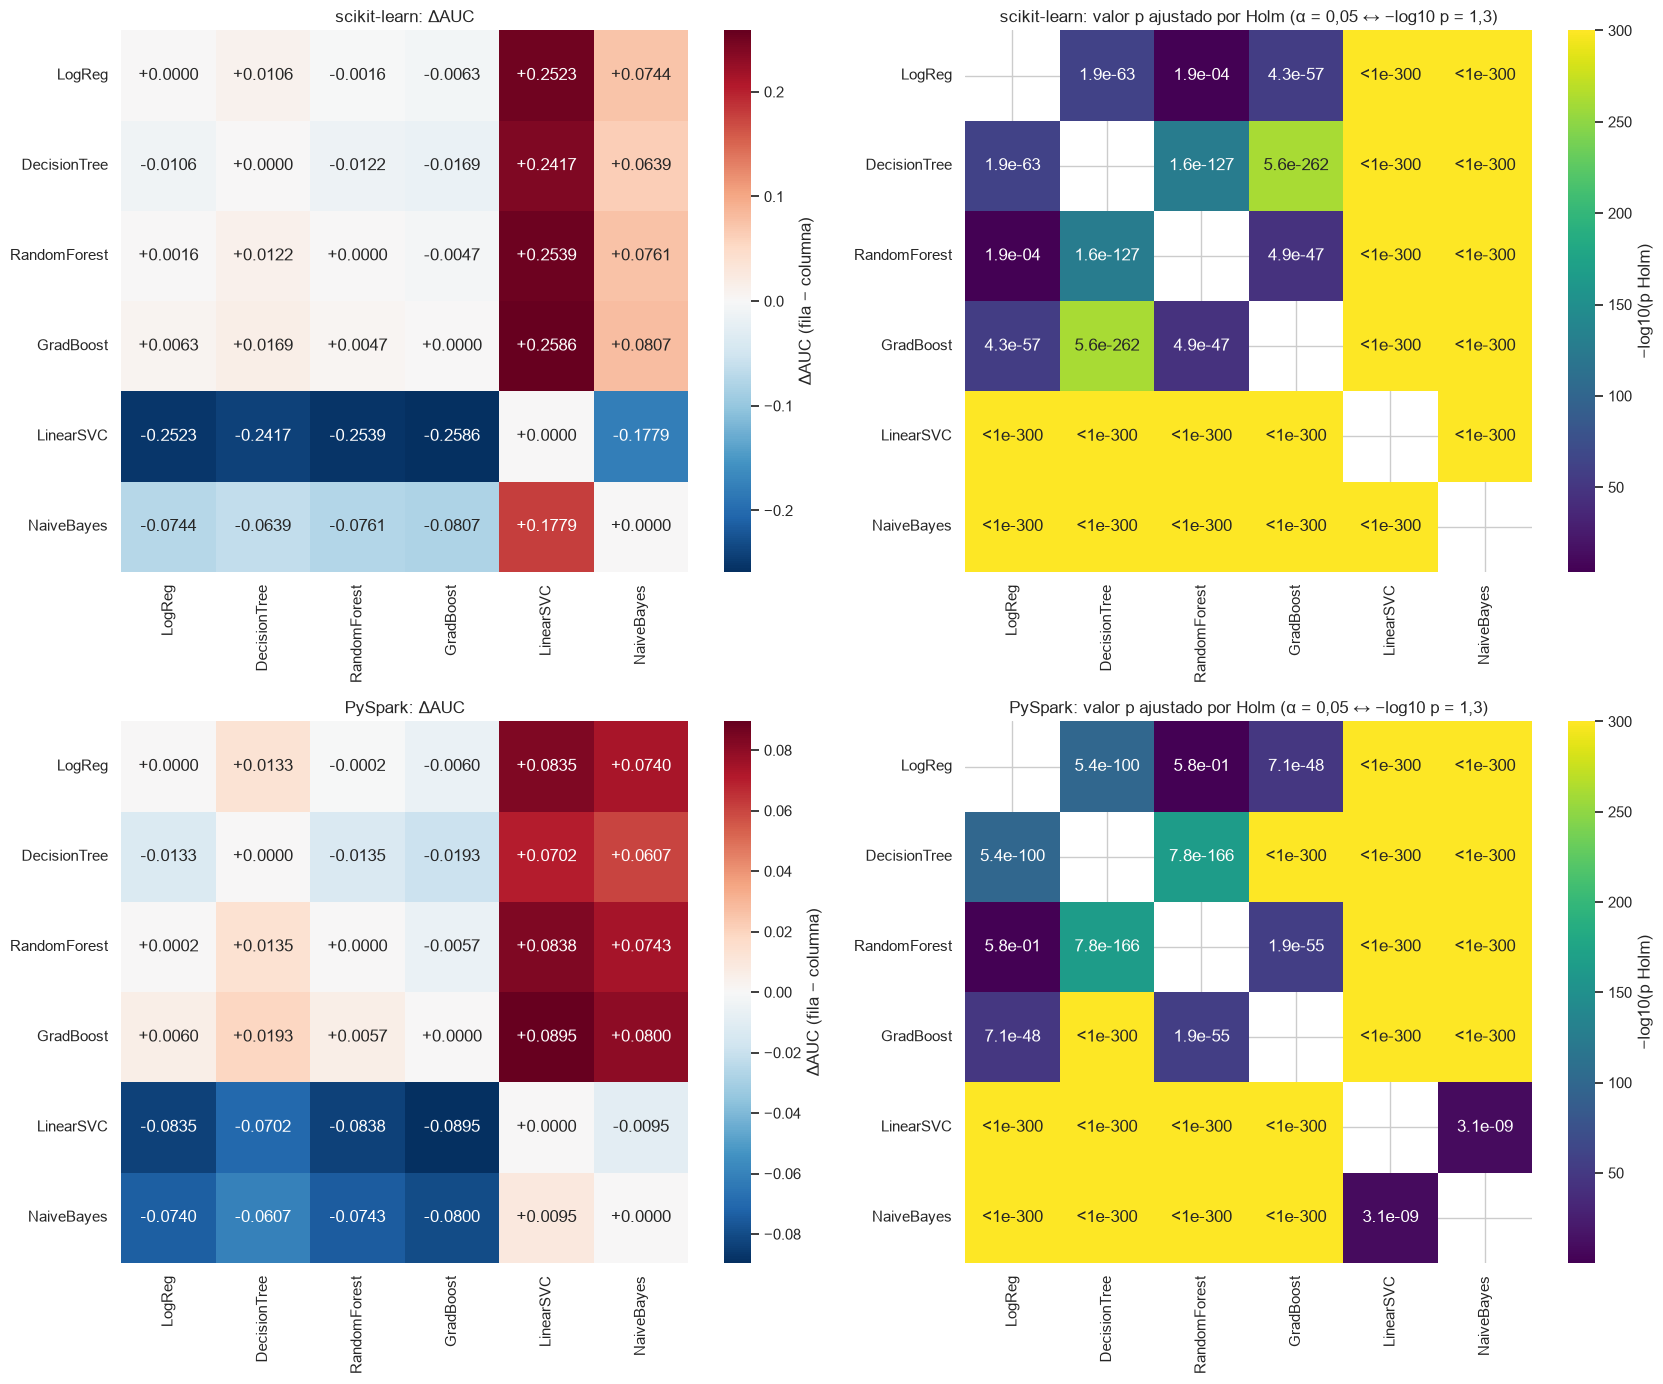

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(17, 14))
for row, (env, df) in enumerate(within.items()):
    d = pd.DataFrame(0.0, index=U.MODELS, columns=U.MODELS)
    p = pd.DataFrame(np.nan, index=U.MODELS, columns=U.MODELS)
    for _, r in df.iterrows():
        a, b = r["modelo 1"].split(" (")[0], r["modelo 2"].split(" (")[0]
        d.loc[a, b], d.loc[b, a] = r["delta_auc"], -r["delta_auc"]
        p.loc[a, b] = p.loc[b, a] = r["p Holm"]
    lim = np.abs(d.to_numpy()).max()
    sns.heatmap(d, annot=True, fmt="+.4f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=axes[row, 0],
                cbar_kws={"label": "ΔAUC (fila − columna)"})
    axes[row, 0].set_title(f"{env}: ΔAUC")
    logp = -np.log10(p.clip(lower=1e-300))
    annot = p.map(lambda v: "" if np.isnan(v) else ("<1e-300" if v < 1e-300 else f"{v:.1e}"))
    sns.heatmap(logp, annot=annot, fmt="", cmap="viridis", ax=axes[row, 1], mask=p.isna(),
                cbar_kws={"label": "−log10(p Holm)"})
    axes[row, 1].set_title(f"{env}: valor p ajustado por Holm (α = 0,05 ↔ −log10 p = 1,3)")
plt.tight_layout()
plt.show()

## 5.5 Pruebas complementarias: McNemar y bootstrap pareado

Se aplican a dos familias, cada una corregida con Holm:

* **(i) Entre entornos:** las 6 comparaciones del mismo modelo en scikit-learn y en PySpark.
* **(ii) Mejores modelos:** el par formado por los dos modelos de mayor AUC dentro de cada entorno (2 comparaciones).

**McNemar.** Usa las decisiones con el umbral de cada modelo fijado en el conjunto de entrenamiento (capítulos 3 y 4): el cuantil $1-\pi$ de sus puntuaciones en train. El conjunto de prueba no interviene en esa elección.

**Bootstrap pareado.** Hace $B = 2000$ remuestreos con reemplazo del conjunto de prueba, con semilla 42 y **los mismos índices para ambos modelos**. Se reporta la diferencia observada, el intervalo percentil del 95 % y un valor p bilateral por percentiles, que es el doble de la proporción de réplicas al otro lado de cero, con mínimo $1/B$. Este valor p se corrige con Holm dentro de cada familia y métrica.

In [93]:
top2 = {env: sorted(U.MODELS, key=lambda m: roc_auc_score(y, S_[env][m]), reverse=True)[:2] for env in S_}
families = {
    "(i) entre entornos": [(("scikit-learn", m), ("PySpark", m)) for m in U.MODELS],
    "(ii) dos mejores por entorno": [((env, top2[env][0]), (env, top2[env][1])) for env in S_],
}
print("Dos mejores modelos por AUC:", top2)

B = 2000
comp_rows = []
t0 = time.time()
for fam, pairs in families.items():
    fam_rows = []
    for (e1, m1), (e2, m2) in pairs:
        s1, s2 = S_[e1][m1].to_numpy(), S_[e2][m2].to_numpy()
        t1, t2 = res[e1][m1]["threshold"], res[e2][m2]["threshold"]
        dl = S.delong_test(y, s1, s2)
        mc = S.mcnemar_test(y, (s1 >= t1).astype(int), (s2 >= t2).astype(int))
        bs = S.paired_bootstrap(y, s1, s2, t1, t2, B=B, seed=U.SEED)
        fam_rows.append({"familia": fam, "modelo 1": f"{m1} ({e1})", "modelo 2": f"{m2} ({e2})",
                         "DeLong ΔAUC": dl["delta_auc"], "DeLong p": dl["p"],
                         "McNemar b": mc["b"], "McNemar c": mc["c"], "McNemar χ²": mc["chi2"], "McNemar p": mc["p"],
                         "acc 1": mc["acc_1"], "acc 2": mc["acc_2"],
                         **{f"boot {k} {q}": bs[k][q] for k in ["auc", "pr_auc", "f1"] for q in ["delta", "lo", "hi", "p"]}})
    fam_df = pd.DataFrame(fam_rows)
    for col in ["DeLong p", "McNemar p", "boot auc p", "boot pr_auc p", "boot f1 p"]:
        fam_df[col + " Holm"] = S.holm(fam_df[col])
    comp_rows.append(fam_df)
comp = pd.concat(comp_rows, ignore_index=True)
print(f"McNemar + bootstrap (B = {B}) para {len(comp)} comparaciones: {time.time() - t0:.0f} s")

Dos mejores modelos por AUC: {'scikit-learn': ['GradBoost', 'RandomForest'], 'PySpark': ['GradBoost', 'RandomForest']}


McNemar + bootstrap (B = 2000) para 8 comparaciones: 701 s


In [94]:
mc_tbl = comp[["familia", "modelo 1", "modelo 2", "acc 1", "acc 2", "McNemar b", "McNemar c", "McNemar χ²",
               "McNemar p", "McNemar p Holm"]].copy()
mc_tbl["significativa"] = np.where(mc_tbl["McNemar p Holm"] < ALPHA, "sí", "no")
mc_tbl.style.format({"acc 1": "{:.4f}", "acc 2": "{:.4f}", "McNemar χ²": "{:,.1f}", "McNemar p": "{:.2e}",
                     "McNemar p Holm": "{:.2e}", "McNemar b": "{:,}", "McNemar c": "{:,}"}).hide(axis="index")

familia,modelo 1,modelo 2,acc 1,acc 2,McNemar b,McNemar c,McNemar χ²,McNemar p,McNemar p Holm,significativa
(i) entre entornos,LogReg (scikit-learn),LogReg (PySpark),0.7596,0.7596,253,255,0.0,9.65e-01,1.00e+00,no
(i) entre entornos,DecisionTree (scikit-learn),DecisionTree (PySpark),0.7548,0.7528,"8,614","8,072",17.5,2.81e-05,1.13e-04,sí
(i) entre entornos,RandomForest (scikit-learn),RandomForest (PySpark),0.7605,0.7593,"4,059","3,735",13.4,2.54e-04,7.61e-04,sí
(i) entre entornos,GradBoost (scikit-learn),GradBoost (PySpark),0.7620,0.7618,"5,111","5,054",0.3,5.79e-01,1.00e+00,no
(i) entre entornos,LinearSVC (scikit-learn),LinearSVC (PySpark),0.6674,0.7339,"37,658","55,551","3,434.5",0.00e+00,0.00e+00,sí
(i) entre entornos,NaiveBayes (scikit-learn),NaiveBayes (PySpark),0.7312,0.7319,685,868,21.3,3.87e-06,1.93e-05,sí
(ii) dos mejores por entorno,GradBoost (scikit-learn),RandomForest (scikit-learn),0.7620,0.7605,"7,260","6,852",11.7,6.12e-04,6.12e-04,sí
(ii) dos mejores por entorno,GradBoost (PySpark),RandomForest (PySpark),0.7618,0.7593,"8,601","7,926",27.5,1.58e-07,3.16e-07,sí


In [95]:
bs_tbl = pd.DataFrame({"familia": comp["familia"], "modelo 1": comp["modelo 1"], "modelo 2": comp["modelo 2"]})
for k, lab in [("auc", "ΔAUC"), ("pr_auc", "ΔAUC-PR"), ("f1", "ΔF1")]:
    bs_tbl[f"{lab} [IC 95 %]"] = [f"{d:+.4f} [{l:+.4f}, {h:+.4f}]" for d, l, h in
                                   comp[[f"boot {k} delta", f"boot {k} lo", f"boot {k} hi"]].to_numpy()]
    bs_tbl[f"p Holm {lab}"] = comp[f"boot {k} p Holm"].map("{:.1e}".format)
bs_tbl

,familia,modelo 1,modelo 2,ΔAUC [IC 95 %],p Holm ΔAUC,ΔAUC-PR [IC 95 %],p Holm ΔAUC-PR,ΔF1 [IC 95 %],p Holm ΔF1
0,(i) entre entornos,LogReg (scikit-learn),LogReg (PySpark),"-0.0000 [-0.0001, +0.0000]",2.9e-01,"+0.0001 [+0.0000, +0.0001]",8.8e-02,"-0.0002 [-0.0006, +0.0002]",9.4e-01
1,(i) entre entornos,DecisionTree (scikit-learn),DecisionTree (PySpark),"+0.0027 [+0.0017, +0.0036]",3.0e-03,"+0.0042 [+0.0022, +0.0061]",3.0e-03,"-0.0021 [-0.0043, -0.0000]",1.3e-01
2,(i) entre entornos,RandomForest (scikit-learn),RandomForest (PySpark),"+0.0014 [+0.0010, +0.0017]",3.0e-03,"+0.0019 [+0.0012, +0.0027]",3.0e-03,"+0.0022 [+0.0006, +0.0037]",3.6e-02
3,(i) entre entornos,GradBoost (scikit-learn),GradBoost (PySpark),"+0.0003 [-0.0001, +0.0007]",2.9e-01,"+0.0013 [+0.0004, +0.0023]",9.0e-03,"+0.0006 [-0.0012, +0.0023]",9.4e-01
4,(i) entre entornos,LinearSVC (scikit-learn),LinearSVC (PySpark),"-0.1688 [-0.1732, -0.1645]",3.0e-03,"-0.1179 [-0.1213, -0.1146]",3.0e-03,"-0.1632 [-0.1682, -0.1587]",3.0e-03
5,(i) entre entornos,NaiveBayes (scikit-learn),NaiveBayes (PySpark),"-0.0005 [-0.0005, -0.0004]",3.0e-03,"-0.0004 [-0.0008, +0.0000]",8.8e-02,"-0.0017 [-0.0024, -0.0012]",3.0e-03
6,(ii) dos mejores por entorno,GradBoost (scikit-learn),RandomForest (scikit-learn),"+0.0047 [+0.0041, +0.0053]",1.0e-03,"+0.0077 [+0.0065, +0.0089]",1.0e-03,"+0.0049 [+0.0030, +0.0070]",1.0e-03
7,(ii) dos mejores por entorno,GradBoost (PySpark),RandomForest (PySpark),"+0.0057 [+0.0050, +0.0064]",1.0e-03,"+0.0083 [+0.0069, +0.0096]",1.0e-03,"+0.0065 [+0.0043, +0.0088]",1.0e-03


## 5.6 Síntesis de las tres pruebas

In [96]:
yn = lambda b: "sí" if b else "no"
summary = pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["modelo 1"] + "  vs  " + comp["modelo 2"],
    "ΔAUC": comp["DeLong ΔAUC"].round(4),
    "DeLong (p Holm < 0,05)": [yn(p < ALPHA) for p in comp["DeLong p Holm"]],
    "bootstrap ΔAUC": [yn(p < ALPHA) for p in comp["boot auc p Holm"]],
    "McNemar": [yn(p < ALPHA) for p in comp["McNemar p Holm"]],
    "bootstrap ΔAUC-PR": [yn(p < ALPHA) for p in comp["boot pr_auc p Holm"]],
    "bootstrap ΔF1": [yn(p < ALPHA) for p in comp["boot f1 p Holm"]],
    "relevante (|ΔAUC| ≥ 0,005)": [yn(p < ALPHA and abs(d) >= MARGIN) for p, d in comp[["DeLong p Holm", "DeLong ΔAUC"]].to_numpy()],
})
summary["DeLong = bootstrap AUC"] = np.where(summary["DeLong (p Holm < 0,05)"] == summary["bootstrap ΔAUC"], "✓", "✗")
summary

,familia,comparación,ΔAUC,"DeLong (p Holm < 0,05)",bootstrap ΔAUC,McNemar,bootstrap ΔAUC-PR,bootstrap ΔF1,"relevante (|ΔAUC| ≥ 0,005)",DeLong = bootstrap AUC
0,(i) entre entornos,LogReg (scikit-learn) vs LogReg (PySpark),-0.0000,no,no,no,no,no,no,✓
1,(i) entre entornos,DecisionTree (scikit-learn) vs DecisionTree ...,0.0027,sí,sí,sí,sí,no,no,✓
2,(i) entre entornos,RandomForest (scikit-learn) vs RandomForest ...,0.0014,sí,sí,sí,sí,sí,no,✓
3,(i) entre entornos,GradBoost (scikit-learn) vs GradBoost (PySpark),0.0003,no,no,no,sí,no,no,✓
4,(i) entre entornos,LinearSVC (scikit-learn) vs LinearSVC (PySpark),-0.1688,sí,sí,sí,sí,sí,sí,✓
5,(i) entre entornos,NaiveBayes (scikit-learn) vs NaiveBayes (PyS...,-0.0005,sí,sí,sí,no,sí,no,✓
6,(ii) dos mejores por entorno,GradBoost (scikit-learn) vs RandomForest (sc...,0.0047,sí,sí,sí,sí,sí,no,✓
7,(ii) dos mejores por entorno,GradBoost (PySpark) vs RandomForest (PySpark),0.0057,sí,sí,sí,sí,sí,sí,✓


En esta tabla, "sí" significa diferencia significativa con **valor p ajustado por Holm < 0,05** dentro de su familia, con el mismo criterio para las tres pruebas. Los intervalos percentiles del bootstrap de la sección 5.5 no están corregidos por multiplicidad. Por eso, una diferencia minúscula puede tener un IC que apenas excluye el cero y aun así no ser significativa tras Holm, como el ΔAUC-PR de la regresión logística entre entornos.

## 5.7 Interpretación

En la comparación entre entornos, la regresión logística (ΔAUC < 0,0001; $p_{Holm} = 0{,}33$) y gradient boosting (ΔAUC = +0,0003; $p_{Holm} = 0{,}33$) no presentan diferencias significativas: ambos optimizadores convergen prácticamente a la misma solución. El árbol de decisión (+0,0027), el bosque aleatorio (+0,0014), ambos a favor de scikit-learn, y Naive Bayes (−0,0005) difieren de forma estadísticamente significativa, pero en magnitudes muy inferiores al margen de relevancia de 0,005. En los árboles, la diferencia es coherente con la discretización en `maxBins=32` de Spark frente a los cortes exactos de scikit-learn y con la aleatoriedad del *bootstrap* del bosque. En Naive Bayes, la correlación prácticamente perfecta entre las puntuaciones de ambos entornos reduce tanto el error estándar de la diferencia que hasta 0,0005 resulta significativo; la discrepancia se debe probablemente al pequeño término de estabilidad que scikit-learn suma a las varianzas (`var_smoothing`). La única diferencia a la vez significativa y relevante es la de LinearSVC (ΔAUC = −0,169, a favor de Spark), explicada por el optimizador, como se mostró en la sección 3.6.

Dentro de cada entorno, el orden de los modelos es el mismo: gradient boosting supera al bosque y a la regresión logística, que prácticamente empatan, y estos al árbol, a Naive Bayes y a LinearSVC. En scikit-learn los 15 pares resultan significativos y 13 relevantes; los dos no relevantes son la regresión logística frente al bosque (−0,0016) y el bosque frente a gradient boosting (−0,0047). En PySpark, 14 de los 15 pares son significativos, y la regresión logística y el bosque no se distinguen ($p_{Holm} = 0{,}58$). Gradient boosting supera a la regresión logística por 0,006 en ambos entornos, una diferencia significativa y relevante. Frente al bosque, su ventaja es relevante en PySpark (0,0057) y queda justo por debajo del margen en scikit-learn (0,0047). Que una diferencia de apenas 0,0010 decida la clasificación recuerda que el margen es una convención, cuya frontera no debe sobreinterpretarse. Con 269 mil observaciones y puntuaciones muy correlacionadas entre modelos (entre 0,91 y 0,99 en los modelos de árboles), el error estándar de ΔAUC ronda 0,0002–0,0006. Por eso casi todas las diferencias resultan significativas, y es el margen de relevancia el que permite distinguir las que tienen importancia práctica.

Las tres pruebas son altamente concordantes. DeLong y el bootstrap del AUC coinciden en las ocho comparaciones complementarias, como cabía esperar de dos procedimientos, uno asintótico y otro de remuestreo, que estiman la misma cantidad con una muestra en la que la aproximación normal es excelente. McNemar coincide con DeLong en las ocho comparaciones: no detecta diferencias en la regresión logística ni en gradient boosting entre entornos, y sí en los demás casos. Esto indica que las diferencias de ordenamiento se trasladan a las decisiones con el umbral elegido. Las discrepancias aparecen en las métricas centradas en la clase minoritaria. Entre los dos gradient boosting, el AUC-PR sí difiere (+0,0013; $p_{Holm} = 0{,}009$) aunque el AUC no, porque el AUC-PR pondera sobre todo la región de puntuaciones altas, donde se concentran los defaults, y es más sensible a pequeños cambios en su ordenamiento. En el árbol de decisión, el AUC difiere pero el F1 no ($p_{Holm} = 0{,}13$), porque en un umbral concreto las diferencias de ordenamiento pueden compensarse.

La prueba de DeLong tiene limitaciones relevantes en este diseño. En primer lugar, solo cuantifica la variabilidad debida al muestreo del conjunto de prueba, no la del entrenamiento (semillas, asignación de pliegues, *bootstrap* del bosque o discretización de Spark). Una diferencia de 0,0014 entre dos bosques podría ser comparable a la que produce un simple cambio de semilla, algo que DeLong no puede detectar; hacerlo requeriría repetir el entrenamiento con distintas semillas o particiones, por ejemplo mediante la prueba 5×2cv de Dietterich (1998), inviable aquí por su costo computacional. En segundo lugar, supone observaciones independientes, un supuesto razonable para préstamos distintos, pero que puede debilitarse por dependencias de cohorte, de prestatario o del ciclo económico, que llevarían a subestimar los errores estándar. En tercer lugar, el AUC resume el desempeño en todos los umbrales, de modo que una diferencia de AUC no implica necesariamente una diferencia en el umbral operativo, ni a la inversa, como muestran el F1 del árbol y el AUC-PR del boosting.

Las pruebas complementarias mitigan algunas de estas limitaciones. McNemar evalúa las decisiones en el umbral elegido, aunque trata todos los errores por igual, cuando en riesgo de crédito un falso negativo, es decir, aprobar un préstamo que termina en default, suele ser mucho más costoso que un falso positivo. El bootstrap pareado prescinde de aproximaciones asintóticas y permite comparar el AUC-PR y el F1, las métricas más informativas para la clase minoritaria. Comparte, sin embargo, las dos primeras limitaciones de DeLong, y con 2000 réplicas su valor p mínimo alcanzable es $5 \times 10^{-4}$.

In [97]:
out = {
    "margin": MARGIN,
    "between": between.to_dict(orient="records"),
    "within": {env: df.to_dict(orient="records") for env, df in within.items()},
    "complementary": comp.to_dict(orient="records"),
    "top2": top2,
}
_ = (U.DATA_DIR / "stats_results.json").write_text(json.dumps(out, indent=2, default=float), encoding="utf-8")

# 6. Interpretabilidad con LIME

Este capítulo corresponde a la sección 9.10.4.7 del proyecto. **LIME** (*Local Interpretable Model-agnostic Explanations*; Ribeiro, Singh y Guestrin, 2016) explica una predicción individual en tres pasos:

1. Genera perturbaciones alrededor de la instancia.
2. Obtiene la predicción del modelo para cada perturbación.
3. Ajusta a esas predicciones un modelo lineal ponderado por cercanía, y sus coeficientes indican qué variables empujaron localmente la probabilidad de default hacia arriba o hacia abajo.

Se explica el **modelo con mayor AUC de cada entorno entre los que entregan probabilidades**. LinearSVC queda excluido, porque solo produce valores de decisión.

In [98]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import roc_auc_score

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

res = {"scikit-learn": json.loads(U.RESULTS_SK.read_text()), "PySpark": json.loads(U.RESULTS_SPARK.read_text())}
sk_scores, sp_scores = pd.read_parquet(U.SCORES_SK), pd.read_parquet(U.SCORES_SPARK)
prob_models = [m for m in U.MODELS if m != "LinearSVC"]
best = {env: max(prob_models, key=lambda m: roc_auc_score(s[U.TARGET], s[m]))
        for env, s in [("scikit-learn", sk_scores), ("PySpark", sp_scores)]}
print("Modelo explicado en cada entorno:", best)

Modelo explicado en cada entorno: {'scikit-learn': 'GradBoost', 'PySpark': 'GradBoost'}


## 6.1 Espacio de explicación

El modelo recibe 91 columnas: numéricas estandarizadas y dummies. Explicarlo directamente en ese espacio tendría dos problemas:

* las reglas serían ilegibles (por ejemplo, "`int_rate` > 0,63 desviaciones estándar");
* LIME perturbaría por separado cada dummy de una misma variable y crearía préstamos imposibles, como uno a 36 y a 60 meses a la vez.

Por eso LIME trabaja sobre las **26 variables originales**:

* 16 numéricas en su escala real, con los faltantes imputados por la mediana de train;
* 3 indicadores binarios;
* 7 categóricas codificadas como enteros.

La función de predicción que recibe LIME aplica el preprocesamiento ajustado en el capítulo 2 y después el modelo. Las estadísticas que LIME usa para perturbar (cuartiles de las numéricas y frecuencias de las categóricas) se calculan con el conjunto de entrenamiento completo.

In [99]:
data = U.sk_train_test()
prep, raw_train, raw_test = data["prep"], data["raw_train"], data["raw_test"]

LIME_NUM, LIME_BIN, LIME_CAT = U.MODEL_NUM, U.INDICATOR_COLS, U.MODEL_CAT
LIME_COLS = LIME_NUM + LIME_BIN + LIME_CAT
cat_levels = dict(zip(LIME_CAT, [list(c) for c in prep.ohe_.categories_]))

def to_lime(df):
    out = df[LIME_NUM].astype(float).fillna(pd.Series(prep.median_)).copy()
    for c in LIME_BIN:
        out[c] = df[c].astype(float)
    for c in LIME_CAT:
        out[c] = df[c].map({v: i for i, v in enumerate(cat_levels[c])}).astype(float)
    return out[LIME_COLS]

def from_lime(Z):
    df = pd.DataFrame(Z, columns=LIME_COLS)
    for c in LIME_BIN:
        df[c] = df[c].round().astype(float)
    for c in LIME_CAT:
        df[c] = [cat_levels[c][int(round(i))] for i in df[c]]
    return df

L_train, L_test = to_lime(raw_train), to_lime(raw_test)
cat_idx = list(range(len(LIME_NUM), len(LIME_COLS)))
cat_names = {i: (["0", "1"] if c in LIME_BIN else cat_levels[c]) for i, c in zip(cat_idx, LIME_BIN + LIME_CAT)}

explainer = LimeTabularExplainer(
    L_train.to_numpy(), feature_names=LIME_COLS, class_names=["Fully Paid", "Charged Off"],
    categorical_features=cat_idx, categorical_names=cat_names, discretize_continuous=True,
    discretizer="quartile", mode="classification", random_state=U.SEED)
print("Espacio de explicación:", L_train.shape)

Espacio de explicación: (1076248, 26)


## 6.2 Funciones de predicción de cada entorno

* **scikit-learn:** se carga el mejor estimador guardado en el capítulo 3 (`joblib`) y se aplica `SkPreprocessor.transform` seguido de `predict_proba`. Todo ocurre en memoria local.
* **PySpark:** los modelos de Spark no pueden guardarse en este equipo, porque escribir con Spark en Windows requiere `winutils.exe` de Hadoop. Por eso se **reentrena el mejor modelo de Spark con sus mejores hiperparámetros** (sección 4.3) sobre el mismo conjunto de entrenamiento cacheado, sin repetir la validación cruzada. Con la semilla fija, el modelo es el mismo que eligió el `CrossValidator`, y así se comprueba reproduciendo el AUC de prueba. Para cada lote de perturbaciones, la función de predicción de LIME:
  1. crea un DataFrame de Spark (`createDataFrame`) con las 5000 filas;
  2. aplica el `Pipeline` de preprocesamiento y el modelo;
  3. trae las probabilidades al driver con `toPandas()`.

  Lo que se transfiere son las perturbaciones de LIME, no el dataset.

In [100]:
sk_model = joblib.load(U.MODELS_SK_DIR / f"{best['scikit-learn']}.joblib")

def predict_sk(Z):
    return sk_model.predict_proba(prep.transform(from_lime(Z)))

In [101]:
from pyspark.ml.classification import (DecisionTreeClassifier, GBTClassifier, LogisticRegression, NaiveBayes,
                                       RandomForestClassifier)
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

spark = U.spark_session()
sres = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)   # mismas condiciones que el capítulo 4
classes = {"LogReg": LogisticRegression, "DecisionTree": DecisionTreeClassifier, "RandomForest": RandomForestClassifier,
           "GradBoost": GBTClassifier, "NaiveBayes": NaiveBayes}
tree = dict(maxBins=32, seed=U.SEED, cacheNodeIds=True)
fixed = {"LogReg": dict(elasticNetParam=0.0, standardization=False, maxIter=100),
         "DecisionTree": tree, "RandomForest": tree, "GradBoost": dict(stepSize=0.1, **tree),
         "NaiveBayes": dict(modelType="gaussian")}
name_sp = best["PySpark"]
params_sp = {**fixed[name_sp], **res["PySpark"][name_sp]["best_params"]}

t0 = time.time()
sp_model = classes[name_sp](featuresCol="features", labelCol=U.TARGET, **params_sp).fit(sres["train"])
t_refit = time.time() - t0

check = (sp_model.transform(sres["test"]).select("id", vector_to_array("probability")[1].alias("p")).toPandas()
         .merge(sp_scores[["id", U.TARGET, name_sp]], on="id"))
print(f"{name_sp} reentrenado con {params_sp} en {t_refit:.0f} s")
print(f"AUC test reentrenado = {roc_auc_score(check[U.TARGET], check['p']):.6f} | AUC capítulo 4 = "
      f"{roc_auc_score(check[U.TARGET], check[name_sp]):.6f} | máx |Δp| = {np.abs(check['p'] - check[name_sp]).max():.1e}")

GradBoost reentrenado con {'stepSize': 0.1, 'maxBins': 32, 'seed': 42, 'cacheNodeIds': True, 'maxIter': 100, 'maxDepth': 5} en 483 s


AUC test reentrenado = 0.719463 | AUC capítulo 4 = 0.719463 | máx |Δp| = 0.0e+00


In [102]:
from pyspark.sql.types import DoubleType, StringType, StructField, StructType

spark_schema = StructType([StructField(c, DoubleType()) for c in LIME_NUM + LIME_BIN]
                          + [StructField(c, StringType()) for c in LIME_CAT])
pipeline_sp, bounds_sp = sres["model"], sres["bounds"]
spark_calls = []

def predict_sp(Z):
    t0 = time.time()
    pdf = from_lime(Z)
    sdf = spark.createDataFrame(pdf[LIME_NUM + LIME_BIN + LIME_CAT], schema=spark_schema)
    feats = pipeline_sp.transform(U.spark_clip_log(sdf, bounds_sp))
    p = sp_model.transform(feats).select(vector_to_array("probability")[1].alias("p")).toPandas()["p"].to_numpy()
    spark_calls.append(time.time() - t0)
    return np.column_stack([1 - p, p])

## 6.3 Selección de instancias mal clasificadas

Se eligen dos préstamos del conjunto de prueba que **ambos modelos clasifican mal**, usando el umbral de cada modelo fijado en entrenamiento:

* **Falso negativo:** el préstamo terminó en default, pero los dos modelos le asignaron baja probabilidad. Se toma el caso con la menor probabilidad promedio.
* **Falso positivo:** el préstamo se pagó por completo, pero los dos modelos le asignaron alta probabilidad de default. Se toma el caso con la mayor probabilidad promedio.

Explicar las mismas instancias en ambos entornos permite comparar si los dos modelos se equivocan por las mismas razones.

In [103]:
cmp = (sk_scores[["id", U.TARGET, best["scikit-learn"]]].rename(columns={best["scikit-learn"]: "p_sk"})
       .merge(sp_scores[["id", best["PySpark"]]].rename(columns={best["PySpark"]: "p_sp"}), on="id"))
thr_sk, thr_sp = res["scikit-learn"][best["scikit-learn"]]["threshold"], res["PySpark"][best["PySpark"]]["threshold"]
cmp["pred_sk"], cmp["pred_sp"] = (cmp["p_sk"] >= thr_sk).astype(int), (cmp["p_sp"] >= thr_sp).astype(int)
cmp["p_mean"] = (cmp["p_sk"] + cmp["p_sp"]) / 2
both_wrong = cmp[(cmp["pred_sk"] != cmp[U.TARGET]) & (cmp["pred_sp"] != cmp[U.TARGET])]
fn = both_wrong[both_wrong[U.TARGET] == 1].nsmallest(1, "p_mean")
fp = both_wrong[both_wrong[U.TARGET] == 0].nlargest(1, "p_mean")
chosen = pd.concat([fn.assign(tipo="falso negativo"), fp.assign(tipo="falso positivo")]).set_index("id")
print(f"Préstamos de prueba mal clasificados por ambos modelos: {len(both_wrong):,} de {len(cmp):,}")
print(f"Umbrales: scikit-learn {thr_sk:.4f} | PySpark {thr_sp:.4f}")
chosen[["tipo", U.TARGET, "p_sk", "p_sp"]]

Préstamos de prueba mal clasificados por ambos modelos: 58,983 de 269,062
Umbrales: scikit-learn 0.2959 | PySpark 0.2941


,tipo,default,p_sk,p_sp
id,,,,
36099806,falso negativo,1,0.020898,0.022070
55961482,falso positivo,0,0.793727,0.871252


In [104]:
inst = raw_test.set_index("id").loc[chosen.index, LIME_COLS]
inst.T

id,36099806,55961482
loan_amnt,9600.0,35000.0
int_rate,6.03,28.99
annual_inc,108000.0,100000.0
dti,9.36,7.44
fico_range_high,824.0,784.0
emp_length,10.0,5.0
credit_hist_years,33.585216,3.249829
delinq_2yrs,0.0,0.0
inq_last_6mths,0.0,2.0
open_acc,8.0,8.0


## 6.4 Explicaciones

Para cada instancia y entorno, LIME genera 5000 perturbaciones y muestra las 10 variables con mayor peso local. Las barras naranjas **aumentan** la probabilidad de default y las azules la **reducen**.

In [105]:
N_SAMPLES, N_FEAT = 5000, 10
explanations, lime_times = {}, {}
for loan_id in chosen.index:
    x = L_test.loc[raw_test["id"] == loan_id].to_numpy()[0]
    for env, fn_ in [("scikit-learn", predict_sk), ("PySpark", predict_sp)]:
        t0 = time.time()
        exp = explainer.explain_instance(x, fn_, num_features=N_FEAT, num_samples=N_SAMPLES)
        lime_times[(loan_id, env)] = time.time() - t0
        explanations[(loan_id, env)] = exp

pd.Series({f"{k[0]} | {k[1]}": v for k, v in lime_times.items()}, name="tiempo LIME (s)").round(2)

36099806 | scikit-learn      0.75
36099806 | PySpark         397.14
55961482 | scikit-learn      0.10
55961482 | PySpark         375.33
Name: tiempo LIME (s), dtype: float64

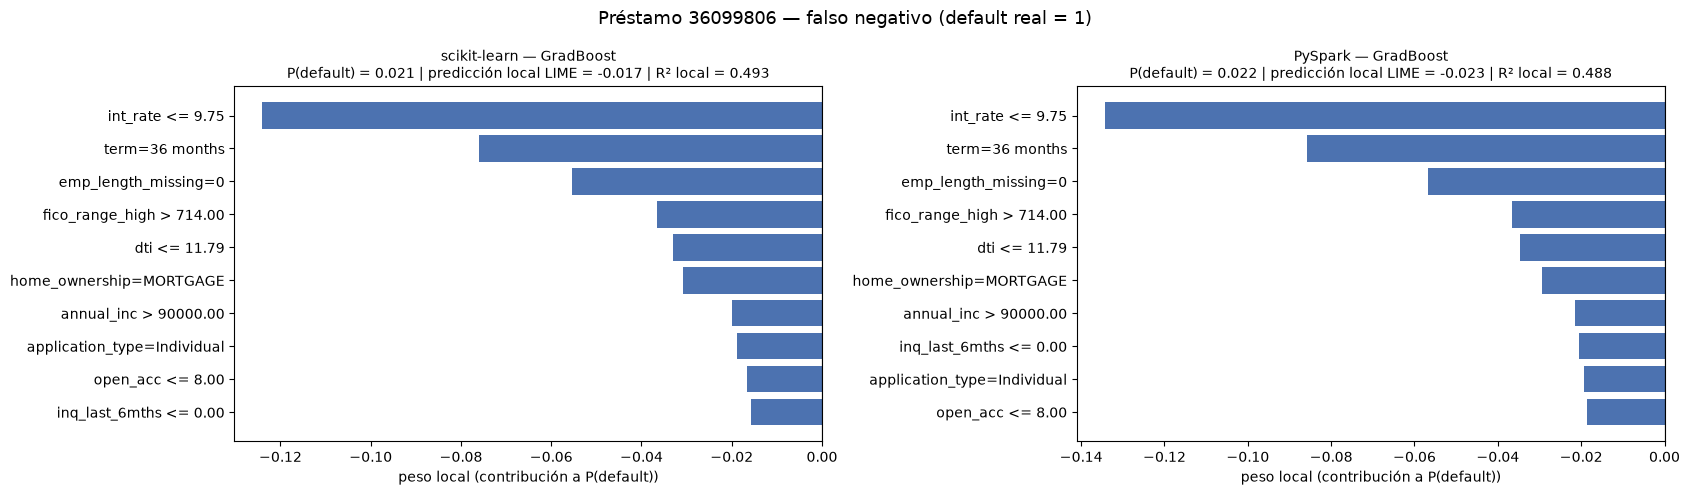

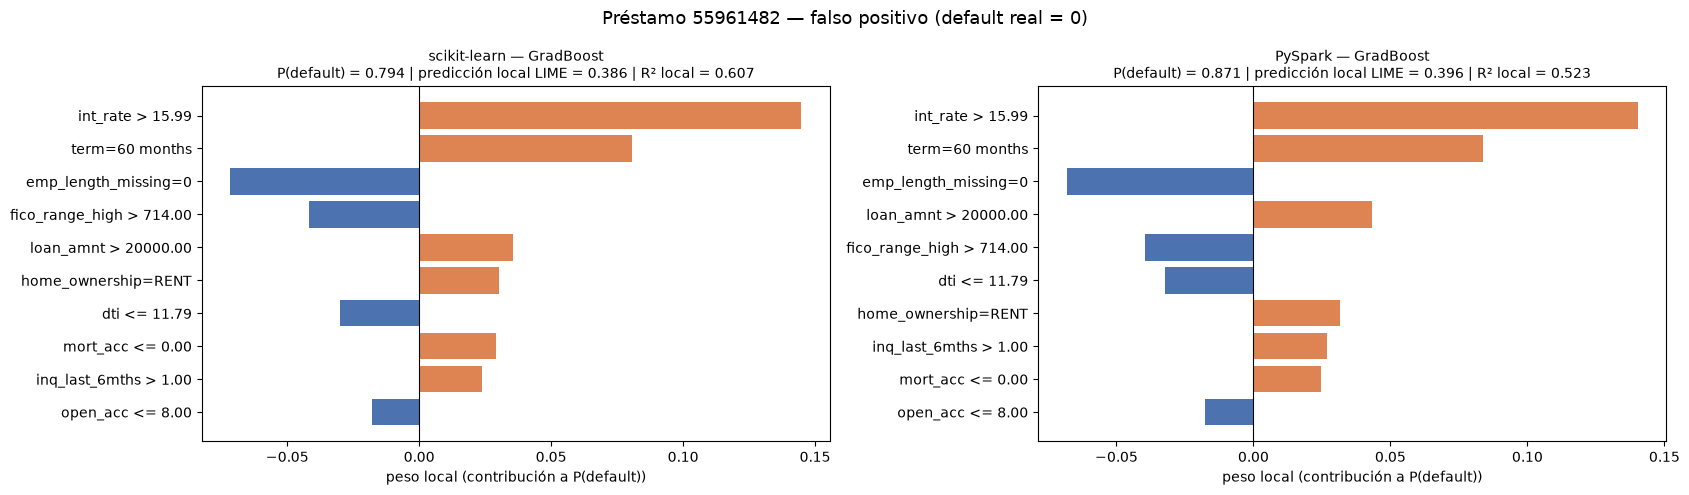

In [106]:
for loan_id in chosen.index:
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    for ax, env in zip(axes, ["scikit-learn", "PySpark"]):
        exp = explanations[(loan_id, env)]
        items = exp.as_list()[::-1]
        ax.barh([k for k, _ in items], [v for _, v in items], color=["#DD8452" if v > 0 else "#4C72B0" for _, v in items])
        ax.axvline(0, c="k", lw=0.8)
        p_model = exp.predict_proba[1]
        ax.set_title(f"{env} — {best[env]}\nP(default) = {p_model:.3f} | predicción local LIME = "
                     f"{exp.local_pred[0]:.3f} | R² local = {exp.score:.3f}", fontsize=10)
        ax.set_xlabel("peso local (contribución a P(default))")
    fig.suptitle(f"Préstamo {loan_id} — {chosen.loc[loan_id, 'tipo']} (default real = {chosen.loc[loan_id, U.TARGET]})",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

In [107]:
rows = []
for (loan_id, env), exp in explanations.items():
    for rank, (feat, w) in enumerate(exp.as_list(), 1):
        rows.append({"préstamo": loan_id, "tipo": chosen.loc[loan_id, "tipo"], "entorno": env, "rango": rank,
                     "condición": feat, "peso": w})
lime_tbl = pd.DataFrame(rows)
lime_tbl.pivot_table(index=["préstamo", "tipo", "rango"], columns="entorno", values="condición", aggfunc="first")

entorno                                            PySpark                 scikit-learn
préstamo tipo           rango                                                          
36099806 falso negativo 1                 int_rate <= 9.75             int_rate <= 9.75
                        2                   term=36 months               term=36 months
                        3             emp_length_missing=0         emp_length_missing=0
                        4         fico_range_high > 714.00     fico_range_high > 714.00
                        5                     dti <= 11.79                 dti <= 11.79
                        6          home_ownership=MORTGAGE      home_ownership=MORTGAGE
                        7            annual_inc > 90000.00        annual_inc > 90000.00
                        8           inq_last_6mths <= 0.00  application_type=Individual
                        9      application_type=Individual             open_acc <= 8.00
                        10                open_acc <= 8.00       inq_last_6mths <= 0.00
55961482 falso positivo 1                 int_rate > 15.99             int_rate > 15.99
                        2                   term=60 months               term=60 months
                        3             emp_length_missing=0         emp_length_missing=0
                        4             loan_amnt > 20000.00     fico_range_high > 714.00
                        5         fico_range_high > 714.00         loan_amnt > 20000.00
                        6                     dti <= 11.79          home_ownership=RENT
                        7              home_ownership=RENT                 dti <= 11.79
                        8            inq_last_6mths > 1.00             mort_acc <= 0.00
                        9                 mort_acc <= 0.00        inq_last_6mths > 1.00
                        10                open_acc <= 8.00             open_acc <= 8.00

In [108]:
def top_vars(exp, k=5):
    # El nombre más largo que aparece en la condición evita confundir emp_length con emp_length_missing.
    return {max((c for c in LIME_COLS if c in cond), key=len) for cond, _ in exp.as_list()[:k]}

agree = pd.DataFrame([{
    "préstamo": loan_id, "tipo": chosen.loc[loan_id, "tipo"],
    "top-5 scikit-learn": sorted(top_vars(explanations[(loan_id, "scikit-learn")])),
    "top-5 PySpark": sorted(top_vars(explanations[(loan_id, "PySpark")])),
    "variables en común (top-5)": len(top_vars(explanations[(loan_id, "scikit-learn")]) & top_vars(explanations[(loan_id, "PySpark")])),
} for loan_id in chosen.index]).set_index("préstamo")
agree

,tipo,top-5 scikit-learn,top-5 PySpark,variables en común (top-5)
préstamo,,,,
36099806,falso negativo,"[dti, emp_length_missing, fico_range_high, int...","[dti, emp_length_missing, fico_range_high, int...",5
55961482,falso positivo,"[emp_length_missing, fico_range_high, int_rate...","[emp_length_missing, fico_range_high, int_rate...",5


### Estabilidad de las explicaciones

LIME es estocástico: las perturbaciones cambian con cada ejecución. Para medir la estabilidad se repite la explicación del falso negativo con el modelo de scikit-learn con 5 semillas distintas y se registra con qué frecuencia cada variable aparece entre las 5 más influyentes. Se usa scikit-learn porque cada llamada en PySpark cuesta varios segundos.

In [109]:
loan_id = chosen.index[0]
x = L_test.loc[raw_test["id"] == loan_id].to_numpy()[0]
counts = {}
for seed in range(5):
    e = LimeTabularExplainer(L_train.to_numpy(), feature_names=LIME_COLS, class_names=["Fully Paid", "Charged Off"],
                             categorical_features=cat_idx, categorical_names=cat_names, discretizer="quartile",
                             random_state=seed).explain_instance(x, predict_sk, num_features=N_FEAT, num_samples=N_SAMPLES)
    for v in top_vars(e):
        counts[v] = counts.get(v, 0) + 1
pd.Series(counts, name="veces en el top-5 (de 5 repeticiones)").sort_values(ascending=False)

emp_length_missing    5
term                  5
int_rate              5
dti                   5
fico_range_high       5
Name: veces en el top-5 (de 5 repeticiones), dtype: int64

## 6.5 Discusión y limitaciones de LIME en entornos distribuidos

El modelo explicado es gradient boosting en ambos entornos. El modelo de Spark reentrenado reproduce exactamente las probabilidades del capítulo 4, con una diferencia máxima nula, lo que confirma que `GBTClassifier` es determinista con semilla y particionado fijos. El resultado central del análisis es que los dos modelos se equivocan por las mismas razones: en ambos préstamos, las cinco condiciones más influyentes coinciden en scikit-learn y en PySpark, en un orden casi idéntico (`int_rate`, `term`, `emp_length_missing`, `fico_range_high` y `dti`). Son precisamente los predictores que el EDA identificó como los más asociados al default, lo que otorga validez sustantiva a las explicaciones.

El falso negativo (préstamo 36099806) recibe en ambos entornos una probabilidad de default de aproximadamente 0,02. Su solicitud describe un perfil de muy bajo riesgo: tasa de 6,03 %, puntaje FICO de 824, plazo de 36 meses, razón deuda/ingreso de 9,4, ingresos de 108 mil dólares, hipoteca y 33 años de historial crediticio. Aun así, el préstamo terminó en default. Las variables disponibles al momento de la originación no pueden anticipar choques posteriores, como la pérdida del empleo, una enfermedad o una separación, de modo que este tipo de error es irreducible con la información disponible y no constituye un defecto del modelo. El falso positivo (préstamo 55961482), con probabilidades de 0,79 a 0,87, presenta el perfil opuesto: tasa de 28,99 %, entre las más altas del conjunto (máximo de 30,99 %), plazo de 60 meses, monto de 35 mil dólares, vivienda en arriendo, ninguna hipoteca y apenas 3,2 años de historial. Sin embargo, fue pagado por completo. En este caso el error se explica sobre todo por `int_rate`, que es la propia evaluación de riesgo de Lending Club: los modelos aprenden en gran medida a reproducir esa evaluación y, con ello, heredan sus errores. La presencia sistemática de `emp_length_missing = 0` entre los factores es coherente con el EDA, donde la ausencia de la antigüedad laboral elevaba el default del 19,5 % al 26,9 %. Por último, al repetir la explicación del falso negativo con cinco semillas, el conjunto de las cinco variables más influyentes no varía, de modo que las explicaciones son estables con 5000 perturbaciones.

Las limitaciones de LIME se agravan en un entorno distribuido. El método opera en memoria local: el explicador necesita las estadísticas del conjunto de entrenamiento (cuartiles y frecuencias), que aquí se calcularon en pandas sobre 1,08 millones de filas y 26 variables, y que con datos más voluminosos exigirían un cálculo distribuido o un muestreo. Además, cada explicación requiere un viaje de ida y vuelta a Spark: crear un DataFrame con las perturbaciones, aplicar el `Pipeline` y el modelo, y traer las probabilidades al driver. Mientras en scikit-learn una explicación tomó entre 0,1 y 0,75 segundos, en PySpark tomó entre 375 y 397 segundos, unas 500 veces más. El volumen de cómputo, de apenas 5000 filas, no explica esa diferencia; la explica el costo fijo de cada trabajo de Spark (planificación, serialización entre Python y la JVM y el reparto del DataFrame en las 400 particiones de `spark.default.parallelism`). Explicar miles de predicciones de este modo sería inviable sin agrupar las perturbaciones de muchas instancias en un único trabajo o recurrir a métodos diseñados para Spark. A ello se suma que, en este equipo, el modelo de Spark no pudo persistirse en disco sin `winutils.exe` y tuvo que reentrenarse (8 minutos), mientras que el de scikit-learn se recuperó directamente con `joblib`.

Por último, LIME tiene limitaciones generales que conviene no perder de vista. Las perturbaciones se generan de forma independiente por variable e ignoran su correlación, de modo que producen préstamos poco plausibles, por ejemplo con una tasa baja y un FICO bajo, cuando la correlación entre ambas variables es de −0,41; la explicación describe entonces el comportamiento del modelo en regiones sin datos. Los resultados dependen, además, de decisiones arbitrarias como la discretización por cuartiles, el ancho del *kernel* y el número de perturbaciones. Y la explicación es local: describe una predicción concreta, no el comportamiento global del modelo ni el mecanismo causal del default.

In [110]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
timings["lime"] = {"refit_pyspark_s": t_refit,
                   "scikit-learn_s": float(np.mean([v for (i, e), v in lime_times.items() if e == "scikit-learn"])),
                   "PySpark_s": float(np.mean([v for (i, e), v in lime_times.items() if e == "PySpark"]))}
(U.DATA_DIR / "timings.json").write_text(json.dumps(timings, indent=2, ensure_ascii=False), encoding="utf-8")
sres["train"].unpersist()
sres["test"].unpersist()
spark.stop()

# 7. Comparación de resultados y reflexión crítica

Este capítulo corresponde a la sección 9.10.4.8 y al entregable 9.10.5. Reúne en tablas y gráficos comparativos:

* las métricas de los seis modelos en ambos entornos;
* los tiempos de cómputo;
* los resultados de las tres pruebas estadísticas.

Cierra con la reflexión crítica que pide el enunciado. Todo se lee de los resultados que guardaron los capítulos 2 a 6. La única excepción es el experimento de escalabilidad de la sección 7.5, que mide tiempos de ajuste con volúmenes crecientes.

In [111]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, roc_auc_score

import lc_utils as U

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

res = {"scikit-learn": json.loads(U.RESULTS_SK.read_text()), "PySpark": json.loads(U.RESULTS_SPARK.read_text())}
scores = {"scikit-learn": pd.read_parquet(U.SCORES_SK), "PySpark": pd.read_parquet(U.SCORES_SPARK)}
stats_res = json.loads((U.DATA_DIR / "stats_results.json").read_text(encoding="utf-8"))
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
ENVS = ["scikit-learn", "PySpark"]

## 7.1 Tabla comparativa de métricas

Las métricas que dependen de un umbral (accuracy, precision, recall y F1) usan el umbral de cada modelo fijado en entrenamiento. El AUC de la tabla es el exacto, calculado con las puntuaciones del conjunto de prueba común.

In [112]:
rows = []
for env in ENVS:
    for m in U.MODELS:
        r = res[env][m]
        rows.append({"entorno": env, "modelo": m,
                     **{f"train {k}": r["train"][k] for k in ["roc_auc", "f1"]},
                     **{f"test {k}": r["test"][k] for k in ["accuracy", "precision", "recall", "f1", "pr_auc"]},
                     "test roc_auc": roc_auc_score(scores[env][U.TARGET], scores[env][m]),
                     "AUC CV": r["cv_auc"], "mejores hiperparámetros": str(r["best_params"] or "(por defecto)")})
table = pd.DataFrame(rows).set_index(["entorno", "modelo"])
table["brecha AUC train−test"] = table["train roc_auc"] - table["test roc_auc"]
num_cols = [c for c in table.columns if c != "mejores hiperparámetros"]
(table.style.format({c: "{:.4f}" for c in num_cols})
      .highlight_max(subset=["test roc_auc", "test pr_auc", "test f1"], props="font-weight: bold; background-color: #d9ead3"))

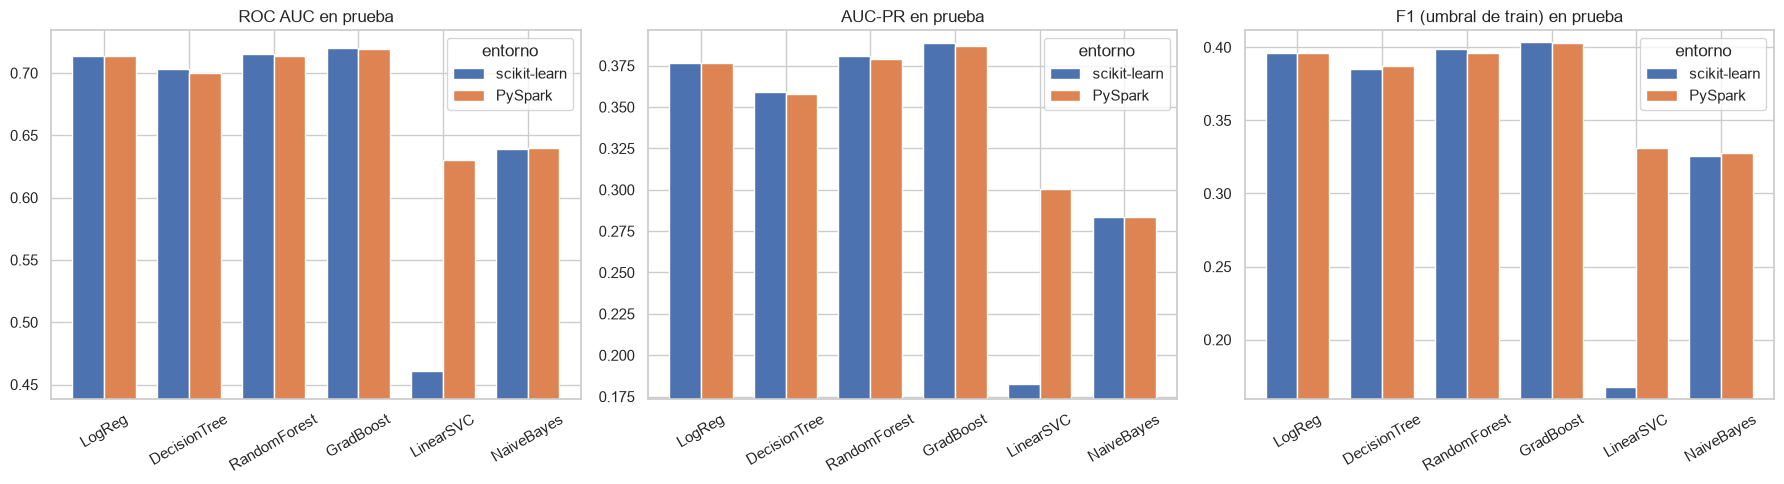

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, lab in zip(axes, ["test roc_auc", "test pr_auc", "test f1"], ["ROC AUC", "AUC-PR", "F1 (umbral de train)"]):
    d = table[metric].unstack(0)[ENVS].loc[U.MODELS]
    d.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"], width=0.75)
    ax.set_title(f"{lab} en prueba")
    ax.set_ylim(d.min().min() * 0.95, d.max().max() * 1.02)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 7.2 Curvas ROC

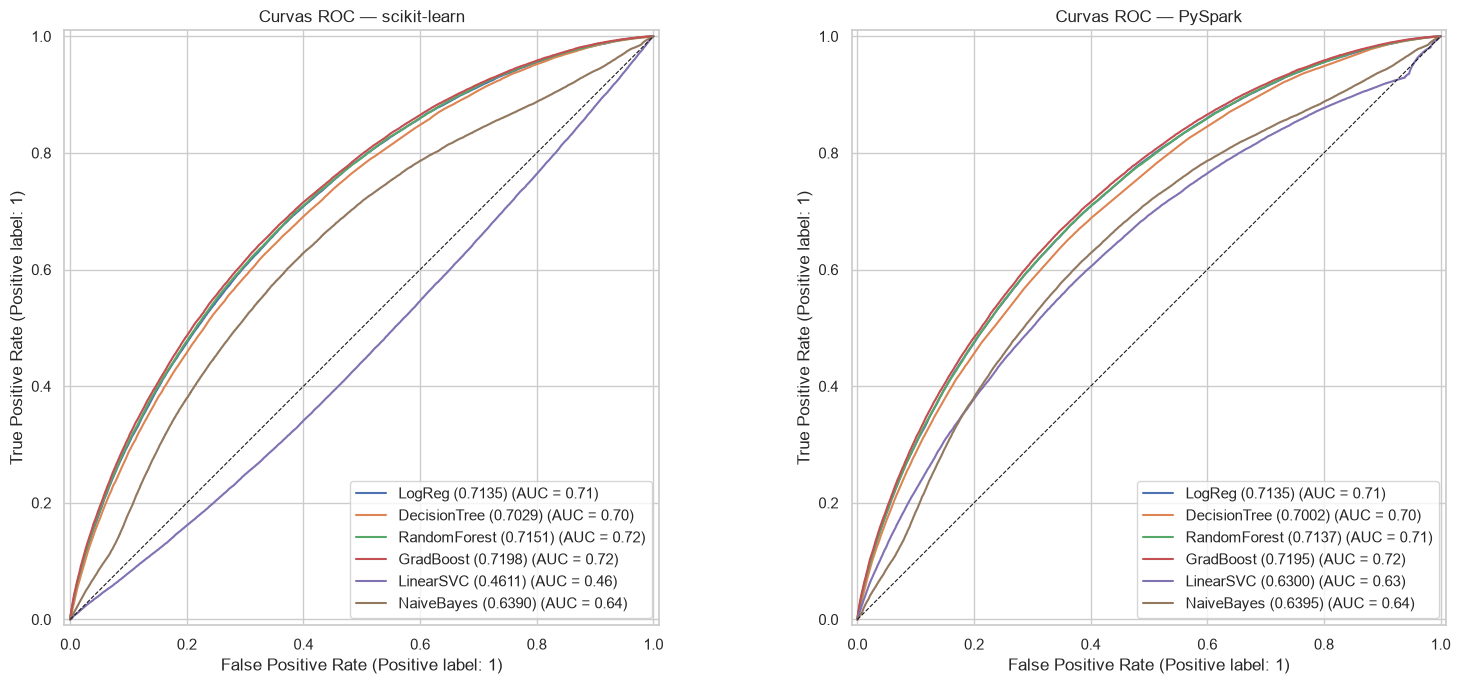

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, env in zip(axes, ENVS):
    s = scores[env]
    for m in U.MODELS:
        RocCurveDisplay.from_predictions(s[U.TARGET], s[m], ax=ax, name=f"{m} ({roc_auc_score(s[U.TARGET], s[m]):.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(f"Curvas ROC — {env}")
plt.tight_layout()
plt.show()

## 7.3 Tiempo de cómputo

Los tiempos corresponden al hardware declarado en el capítulo 2. En cada entorno se reportan tres componentes:

* **preprocesamiento:** desde el CSV hasta las matrices o DataFrames listos, incluida la lectura;
* **entrenamiento:** búsqueda de hiperparámetros con validación cruzada de 3 pliegues más el reajuste final;
* **predicción** sobre el conjunto de prueba.

En PySpark se reporta aparte la transferencia al driver de las puntuaciones de prueba.

In [115]:
trows = []
for env in ENVS:
    for m in U.MODELS:
        r = res[env][m]
        trows.append({"entorno": env, "modelo": m, "entrenamiento con CV (s)": r["train_time_s"],
                      "predicción (s)": r["predict_time_s"], "transferencia (s)": r.get("transfer_time_s", np.nan)})
times = pd.DataFrame(trows).set_index(["entorno", "modelo"])
prep = pd.Series(timings["preprocesamiento"], name="preprocesamiento (s)")
totals = times.groupby(level=0).sum(min_count=1)
totals["preprocesamiento (s)"] = prep
totals["total (s)"] = totals[["preprocesamiento (s)", "entrenamiento con CV (s)", "predicción (s)"]].sum(axis=1)
totals["total (min)"] = totals["total (s)"] / 60
display(times.unstack(0).round(1))
totals.loc[ENVS].round(1)

entrenamiento con CV (s)              predicción (s)              transferencia (s)             
entorno                       PySpark scikit-learn        PySpark scikit-learn           PySpark scikit-learn
modelo                                                                                                       
DecisionTree                    219.3        136.2            1.3          0.1               2.3          NaN
GradBoost                      4845.5       7506.0            3.7          2.6               4.4          NaN
LinearSVC                      1268.9       1412.7            1.3          0.2               2.0          NaN
LogReg                          662.9         25.4            1.4          0.0               2.7          NaN
NaiveBayes                      174.2         12.4            1.3          0.3               2.0          NaN
RandomForest                   6306.3       1544.8          100.5          4.3              28.2          NaN

,entrenamiento con CV (s),predicción (s),transferencia (s),preprocesamiento (s),total (s),total (min)
entorno,,,,,,
scikit-learn,10637.6,7.6,NaN,39.6,10684.7,178.1
PySpark,13477.1,109.5,41.7,158.1,13744.8,229.1


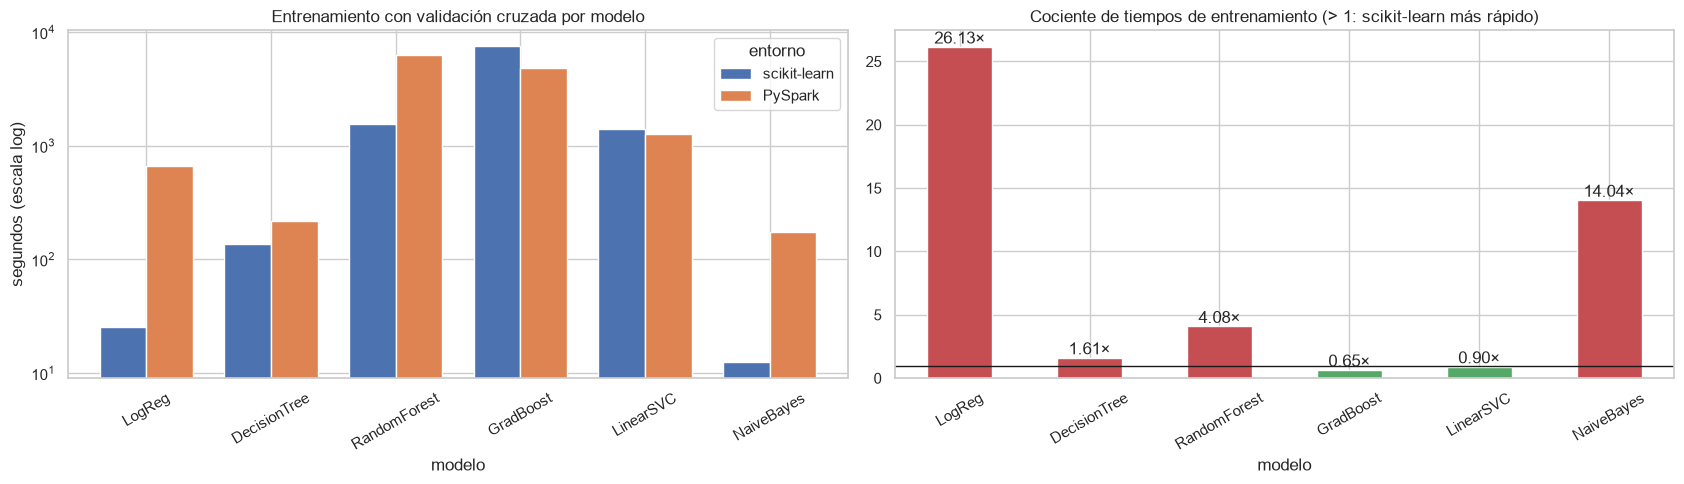

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
tr = times["entrenamiento con CV (s)"].unstack(0)[ENVS].loc[U.MODELS]
tr.plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"], logy=True, width=0.75)
axes[0].set_ylabel("segundos (escala log)")
axes[0].set_title("Entrenamiento con validación cruzada por modelo")
axes[0].tick_params(axis="x", rotation=30)
ratio = (tr["PySpark"] / tr["scikit-learn"]).rename("PySpark / scikit-learn")
ratio.plot.bar(ax=axes[1], color=np.where(ratio > 1, "#C44E52", "#55A868"))
axes[1].axhline(1, c="k", lw=1)
axes[1].set_title("Cociente de tiempos de entrenamiento (> 1: scikit-learn más rápido)")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(ratio):
    axes[1].text(i, v, f"{v:.2f}×", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 7.4 Resultados de las pruebas estadísticas

In [117]:
b = pd.DataFrame(stats_res["between"])
between = pd.DataFrame({
    "modelo": [m for m in U.MODELS],
    "AUC scikit-learn": b["auc_1"], "AUC PySpark": b["auc_2"],
    "ΔAUC (sk − spark) [IC 95 %]": [f"{d:+.4f} [{l:+.4f}, {h:+.4f}]" for d, l, h in b[["delta_auc", "delta_lo", "delta_hi"]].to_numpy()],
    "p Holm": b["p Holm"].map("{:.1e}".format),
    "significativa": b["significativa"].map({True: "sí", False: "no"}),
    "relevante (≥ 0,005)": b["relevante"].map({True: "sí", False: "no"}),
}).set_index("modelo")
print("DeLong entre entornos (familia de 6 comparaciones, Holm):")
between.style.format({"AUC scikit-learn": "{:.4f}", "AUC PySpark": "{:.4f}"})

DeLong entre entornos (familia de 6 comparaciones, Holm):


,AUC scikit-learn,AUC PySpark,ΔAUC (sk − spark) [IC 95 %],p Holm,significativa,"relevante (≥ 0,005)"
modelo,,,,,,
LogReg,0.7135,0.7135,"-0.0000 [-0.0001, +0.0000]",3.3e-01,no,no
DecisionTree,0.7029,0.7002,"+0.0027 [+0.0017, +0.0037]",3.3e-07,sí,no
RandomForest,0.7151,0.7137,"+0.0014 [+0.0010, +0.0017]",1.8e-11,sí,no
GradBoost,0.7198,0.7195,"+0.0003 [-0.0001, +0.0007]",3.3e-01,no,no
LinearSVC,0.4611,0.6300,"-0.1688 [-0.1731, -0.1645]",0.0e+00,sí,sí
NaiveBayes,0.6390,0.6395,"-0.0005 [-0.0005, -0.0004]",1.2e-32,sí,no


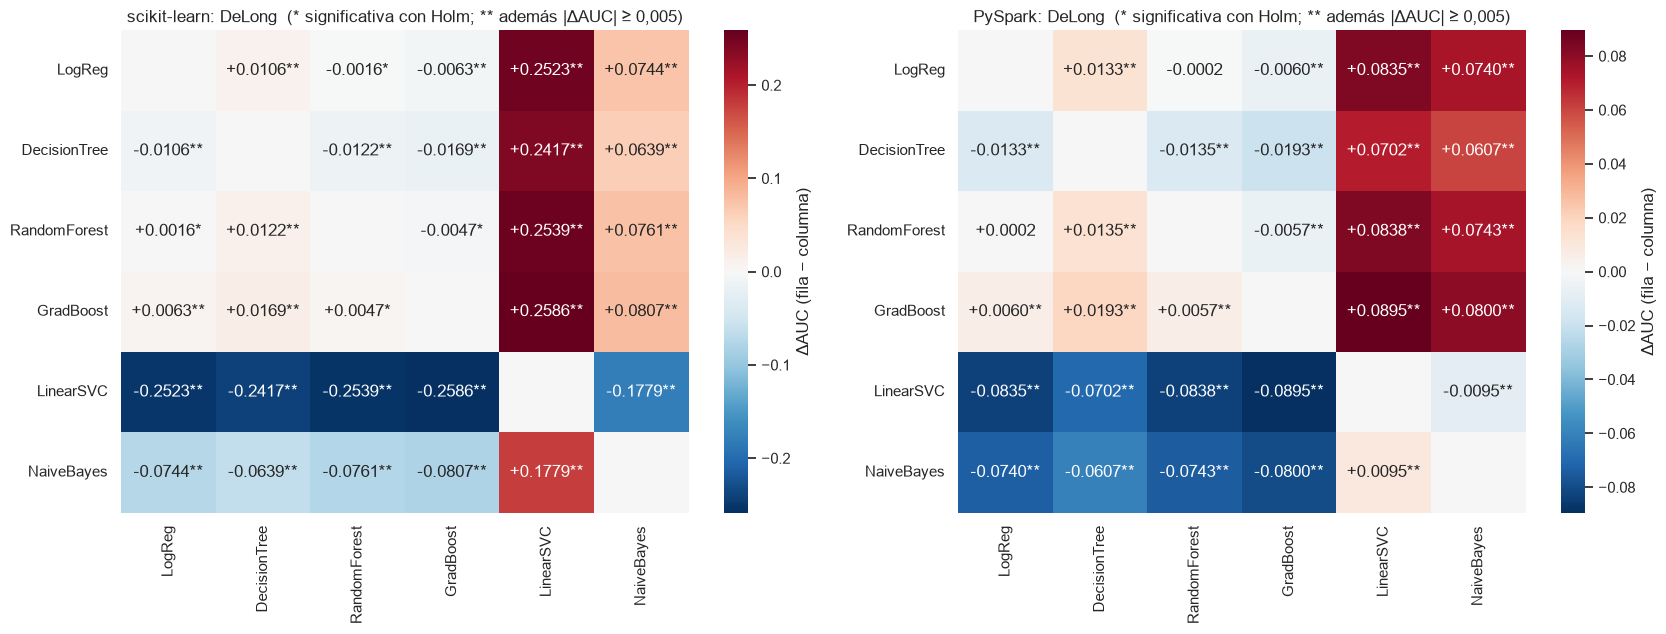

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, env in zip(axes, ENVS):
    df = pd.DataFrame(stats_res["within"][env])
    d = pd.DataFrame(0.0, index=U.MODELS, columns=U.MODELS)
    annot = pd.DataFrame("", index=U.MODELS, columns=U.MODELS)
    for _, r in df.iterrows():
        a, c = r["modelo 1"].split(" (")[0], r["modelo 2"].split(" (")[0]
        d.loc[a, c], d.loc[c, a] = r["delta_auc"], -r["delta_auc"]
        star = "" if r["p Holm"] >= 0.05 else ("*" if abs(r["delta_auc"]) < stats_res["margin"] else "**")
        annot.loc[a, c] = f"{r['delta_auc']:+.4f}{star}"
        annot.loc[c, a] = f"{-r['delta_auc']:+.4f}{star}"
    lim = np.abs(d.to_numpy()).max()
    sns.heatmap(d, annot=annot, fmt="", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax,
                cbar_kws={"label": "ΔAUC (fila − columna)"})
    ax.set_title(f"{env}: DeLong  (* significativa con Holm; ** además |ΔAUC| ≥ 0,005)")
plt.tight_layout()
plt.show()

In [119]:
comp = pd.DataFrame(stats_res["complementary"])
yn = lambda v: "sí" if v else "no"
pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["modelo 1"] + " vs " + comp["modelo 2"],
    "ΔAUC": comp["DeLong ΔAUC"].round(4),
    "DeLong": [yn(p < 0.05) for p in comp["DeLong p Holm"]],
    "McNemar": [yn(p < 0.05) for p in comp["McNemar p Holm"]],
    "bootstrap ΔAUC": [yn(p < 0.05) for p in comp["boot auc p Holm"]],
    "bootstrap ΔAUC-PR": [yn(p < 0.05) for p in comp["boot pr_auc p Holm"]],
    "bootstrap ΔF1": [yn(p < 0.05) for p in comp["boot f1 p Holm"]],
}).set_index(["familia", "comparación"])

ΔAUC DeLong McNemar bootstrap ΔAUC bootstrap ΔAUC-PR bootstrap ΔF1
familia                      comparación                                                                                                             
(i) entre entornos           LogReg (scikit-learn) vs LogReg (PySpark)          -0.0000     no      no             no                no            no
                             DecisionTree (scikit-learn) vs DecisionTree (Py...  0.0027     sí      sí             sí                sí            no
                             RandomForest (scikit-learn) vs RandomForest (Py...  0.0014     sí      sí             sí                sí            sí
                             GradBoost (scikit-learn) vs GradBoost (PySpark)     0.0003     no      no             no                sí            no
                             LinearSVC (scikit-learn) vs LinearSVC (PySpark)    -0.1688     sí      sí             sí                sí            sí
                             NaiveBayes (scikit-learn) vs NaiveBayes (PySpark)  -0.0005     sí      sí             sí                no            sí
(ii) dos mejores por entorno GradBoost (scikit-learn) vs RandomForest (sciki...  0.0047     sí      sí             sí                sí            sí
                             GradBoost (PySpark) vs RandomForest (PySpark)       0.0057     sí      sí             sí                sí            sí

## 7.5 Experimento de escalabilidad: ¿a partir de qué volumen gana PySpark?

La reflexión pregunta a partir de qué volumen de datos PySpark comienza a superar a scikit-learn. Para responder con mediciones y no con suposiciones, se mide **un único ajuste** (sin validación cruzada) de dos modelos representativos:

* la **regresión logística**, que hace muchas pasadas baratas sobre los datos;
* un **árbol de decisión** de profundidad 10, que hace pocas pasadas caras.

Cada modelo se ajusta sobre el conjunto de entrenamiento completo **replicado 1, 2 y 4 veces** (1,08 M, 2,15 M y 4,30 M de filas), con los mejores hiperparámetros de cada entorno. La réplica solo sirve para emular volúmenes mayores y medir tiempos: no aporta información nueva y no se usa para evaluar desempeño. En ningún caso se reduce el dataset.

Ambos entornos corren en el mismo equipo:

* scikit-learn usa un proceso, con L-BFGS en la regresión logística y un solo hilo en el árbol;
* Spark usa `local[*]`, con 12 particiones y caché.

In [120]:
import time
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.tree import DecisionTreeClassifier as SkDT

REPS = [1, 2, 4]
data = U.sk_train_test()
X1, y1 = data["X_train"], data["y_train"]
del data
C_best = res["scikit-learn"]["LogReg"]["best_params"]["C"]
scal = []
for k in REPS:
    Xk, yk = (np.concatenate([X1] * k), np.concatenate([y1] * k)) if k > 1 else (X1, y1)
    t0 = time.time(); SkLR(C=C_best, max_iter=1000).fit(Xk, yk); t_lr = time.time() - t0
    t0 = time.time(); SkDT(max_depth=10, random_state=U.SEED).fit(Xk, yk); t_dt = time.time() - t0
    scal.append({"filas": len(yk), "entorno": "scikit-learn", "LogReg (s)": t_lr, "DecisionTree (s)": t_dt})
    del Xk, yk
del X1, y1

In [121]:
from pyspark import StorageLevel
from pyspark.ml.classification import DecisionTreeClassifier as SpDT, LogisticRegression as SpLR

spark = U.spark_session()
sres = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)
base = sres["train"]
reg_best = res["PySpark"]["LogReg"]["best_params"]["regParam"]
for k in REPS:
    df = base
    for _ in range(k - 1):
        df = df.union(base)
    df = df.coalesce(U.SPARK_MODEL_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)
    n = df.count()
    t0 = time.time()
    SpLR(featuresCol="features", labelCol=U.TARGET, regParam=reg_best, elasticNetParam=0.0, standardization=False,
         maxIter=100).fit(df)
    t_lr = time.time() - t0
    t0 = time.time()
    SpDT(featuresCol="features", labelCol=U.TARGET, maxDepth=10, maxBins=32, seed=U.SEED, cacheNodeIds=True).fit(df)
    t_dt = time.time() - t0
    scal.append({"filas": n, "entorno": "PySpark", "LogReg (s)": t_lr, "DecisionTree (s)": t_dt})
    df.unpersist()
U.spark_shutdown(spark)

scal_df = pd.DataFrame(scal)
scal_df.pivot(index="filas", columns="entorno").round(1)

LogReg (s)              DecisionTree (s)             
entorno    PySpark scikit-learn          PySpark scikit-learn
filas                                                        
1076248       17.0          4.9             13.4         18.7
2152496       20.8          5.6             16.3         37.0
4304992       29.3         10.6             27.9         82.0

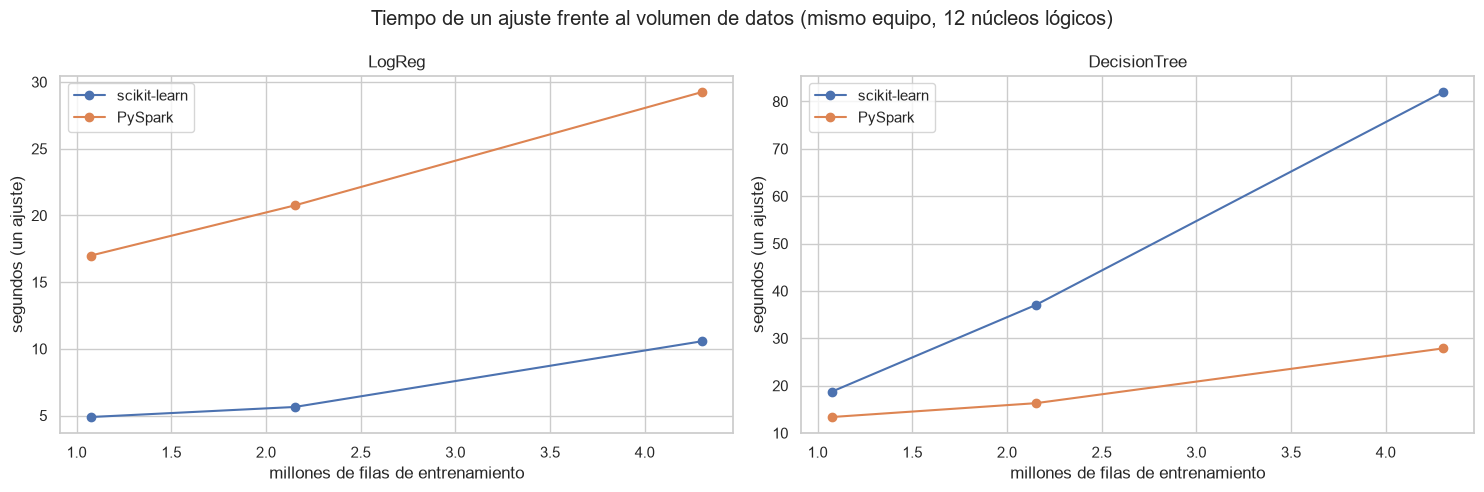

,s/millón de filas scikit-learn,s/millón de filas PySpark,costo fijo PySpark (s),cruce estimado (millones de filas)
LogReg,1.84,3.82,12.74,inf
DecisionTree,19.78,4.62,7.59,0.75


In [122]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cross = {}
for ax, m in zip(axes, ["LogReg (s)", "DecisionTree (s)"]):
    fits = {}
    for env, col in zip(ENVS, ["#4C72B0", "#DD8452"]):
        d = scal_df[scal_df["entorno"] == env]
        ax.plot(d["filas"] / 1e6, d[m], "o-", color=col, label=env)
        fits[env] = np.polyfit(d["filas"], d[m], 1)      # t = pendiente · n + costo fijo
    (b_sk, a_sk), (b_sp, a_sp) = fits["scikit-learn"], fits["PySpark"]
    n_cross = (a_sp - a_sk) / (b_sk - b_sp) if b_sk > b_sp else np.inf
    cross[m.replace(" (s)", "")] = {"s/millón de filas scikit-learn": b_sk * 1e6, "s/millón de filas PySpark": b_sp * 1e6,
                                    "costo fijo PySpark (s)": a_sp, "cruce estimado (millones de filas)": n_cross / 1e6}
    ax.set_xlabel("millones de filas de entrenamiento")
    ax.set_ylabel("segundos (un ajuste)")
    ax.set_title(m.replace(" (s)", ""))
    ax.legend()
plt.suptitle("Tiempo de un ajuste frente al volumen de datos (mismo equipo, 12 núcleos lógicos)")
plt.tight_layout()
plt.show()
pd.DataFrame(cross).T.round(2)

El experimento muestra que no existe un único volumen a partir del cual PySpark supere a scikit-learn: la respuesta depende del algoritmo. En el árbol de decisión, un ajuste único con Spark ya es más rápido con el conjunto de entrenamiento original (13,4 frente a 18,7 segundos). El cruce estimado se sitúa en torno a 0,75 millones de filas, y con 4,3 millones la ventaja de Spark es de tres veces (28 frente a 82 segundos). `DecisionTreeClassifier` de scikit-learn construye el árbol en un solo hilo y su costo crece linealmente con el volumen (19,8 s por millón de filas), mientras que Spark reparte el cálculo de histogramas entre los doce núcleos (4,6 s por millón de filas más un costo fijo de unos 8 segundos). En la regresión logística ocurre lo contrario: scikit-learn es más rápido en los tres tamaños y además escala mejor (1,8 frente a 3,8 s por millón de filas), porque L-BFGS opera sobre una matriz densa en memoria con operaciones vectorizadas y multihilo. Spark, en cambio, paga en cada iteración la agregación distribuida del gradiente. En este caso las rectas no se cruzan, de modo que en un único equipo Spark no alcanzaría a scikit-learn a ningún volumen.

Estas mediciones corresponden a un solo ajuste. En la búsqueda completa de hiperparámetros, `GridSearchCV` ajusta en paralelo hasta doce combinaciones y pliegues, mientras que `CrossValidator` las ajusta secuencialmente (con `parallelism=1` por defecto) y materializa en caché cada pliegue. Por eso el árbol, más rápido en Spark en un ajuste aislado, resultó más lento en la validación cruzada (219 frente a 136 segundos). El límite práctico de scikit-learn en este equipo no es el tiempo sino la memoria: la matriz de entrenamiento ocupa unos 364 bytes por fila en `float32`, y con `n_jobs=-1` cada proceso copia su pliegue, de modo que la validación cruzada paralela agotaría los 16 GB de RAM hacia los tres o cuatro millones de filas. Por encima de ese volumen, o en un clúster con varios nodos, Spark pasa a ser la opción viable y no solo la más rápida.

## 7.6 Modelo ganador

El modelo ganador es **gradient boosting**, que ocupa el primer lugar en ambos entornos con los mismos hiperparámetros: 100 iteraciones o árboles, profundidad 5 y tasa de aprendizaje 0,1. En el conjunto de prueba alcanza un AUC de 0,7198 en scikit-learn y de 0,7195 en PySpark, una diferencia no significativa ($p_{Holm} = 0{,}33$), con un AUC-PR de 0,389 y un F1 de 0,40. Su ventaja sobre la regresión logística (0,006 de AUC) es significativa y supera el margen de relevancia en ambos entornos. Frente al bosque aleatorio, es relevante en PySpark (0,0057) y se queda ligeramente por debajo del margen en scikit-learn (0,0047). Además, gradient boosting presenta la menor brecha entre entrenamiento y prueba de los modelos no lineales (0,004), lo que indica una buena capacidad de generalización.

Conviene dimensionar el resultado. Un AUC de 0,72, equivalente a un coeficiente de Gini de 0,44, es un desempeño moderado, típico de los modelos de originación que solo disponen de la información de la solicitud. El análisis LIME del capítulo 6 muestra que parte del error es irreducible con esas variables, y que los modelos se apoyan en buena medida en la propia tasa de interés asignada por la plataforma. Con el umbral fijado en entrenamiento, el modelo identifica el 40 % de los defaults con una precisión del 40 %, el doble de la tasa base. Desde una perspectiva práctica, la regresión logística ofrece una alternativa atractiva: pierde solo 0,006 de AUC, se entrena en segundos, sus coeficientes son directamente interpretables y es la solución más estable entre entornos. En cuanto a la implementación del ganador, los dos entornos son estadísticamente equivalentes en capacidad de ordenamiento, y la elección debe basarse en el costo. En este equipo, el GBT de Spark se entrenó en 81 minutos frente a 125 de `GradientBoostingClassifier`, aunque `HistGradientBoostingClassifier` de scikit-learn alcanzó un desempeño similar en una fracción de ese tiempo (sección 3.7).

## 7.7 Reflexión crítica

**¿Qué entorno fue más rápido y por qué?** scikit-learn completó el flujo en 178 minutos y PySpark en 229, es decir, 1,29 veces más. scikit-learn fue más rápido en el preprocesamiento (40 frente a 158 segundos), en la predicción y en cuatro de los seis modelos. La regresión logística fue 26 veces más rápida y Naive Bayes 14 veces. PySpark solo aventajó a scikit-learn en gradient boosting (81 frente a 125 minutos) y, marginalmente, en LinearSVC. La expectativa del enunciado de que PySpark superara en velocidad a scikit-learn no se cumplió en estas condiciones, y la razón es estructural. Con 1,35 millones de filas, la matriz de entrenamiento ocupa 392 MB y cabe holgadamente en la memoria de un único equipo. En ese régimen, Spark no aporta capacidad adicional y sí añade costos fijos en cada pasada sobre los datos: planificación de tareas, serialización entre Python y la JVM, agregaciones en árbol y materialización de pliegues. Estos costos dominan en los algoritmos de muchas iteraciones baratas y se amortizan en los de pocas pasadas costosas, como la construcción de árboles profundos. El caché resultó indispensable (sin él, un ajuste fue catorce veces más lento). El `CrossValidator` secuencial multiplicó por diez o más el costo de un ajuste aislado. Y la configuración obligatoria, con 400 particiones pensadas para un clúster, ralentizaba entre seis y diez veces los ajustes en un equipo de doce núcleos, lo que obligó a reducir las particiones de los DataFrames de modelado a doce.

**¿Cuál fue más preciso?** En términos prácticos, ninguno. En el modelo ganador y en la regresión logística, los dos entornos son estadísticamente indistinguibles en AUC. scikit-learn obtuvo pequeñas ventajas significativas en el árbol (+0,0027) y en el bosque (+0,0014), y en el AUC-PR del boosting (+0,0013), todas muy por debajo del margen de relevancia. PySpark superó ampliamente a scikit-learn en LinearSVC (+0,169), pero por diferencias del optimizador y no por una mayor capacidad del entorno.

**¿Qué diferencias en el AUC fueron significativas tras la corrección por comparaciones múltiples, y cuáles son relevantes en la práctica?** Entre entornos, cuatro de las seis comparaciones son significativas con Holm (árbol, bosque, Naive Bayes y LinearSVC), pero solo la de LinearSVC es relevante. Dentro de cada entorno, 15 de 15 pares en scikit-learn y 14 de 15 en PySpark son significativos, y 13 y 14, respectivamente, superan además el margen de 0,005. Las diferencias relevantes separan tres niveles de desempeño: gradient boosting en la cima; el bosque y la regresión logística en un nivel intermedio, prácticamente empatados; y el árbol, Naive Bayes y LinearSVC por debajo. Con 269 mil observaciones de prueba y modelos muy correlacionados, la significancia estadística es casi automática, y es el margen de relevancia, fijado antes de ver los resultados, el que permite una lectura sustantiva.

**¿Qué diferencias de implementación explican las discrepancias?** La más importante es la formulación de LinearSVC. scikit-learn solo admite la pérdida hinge mediante el dual de liblinear, que además regulariza el intercepto y no converge con valores grandes de $C$. Spark optimiza el primal con OWL-QN sin penalizar el intercepto. Con la misma pérdida, esto produce un AUC de 0,46 frente a 0,63. En los árboles, Spark discretiza cada variable continua en 32 intervalos por cuantiles aproximados, mientras que scikit-learn evalúa todos los cortes posibles. Además, el *bootstrap* y el submuestreo de variables del bosque siguen generadores aleatorios distintos que dependen del particionado. En la regresión logística, la relación $C = 1/(\lambda n)$ es solo aproximada porque $C$ pondera la suma de las pérdidas y `regParam` su promedio, y porque en validación cruzada cada pliegue tiene $2n/3$ observaciones; aun así, la superficie de validación es tan plana que ambos entornos llegan al mismo AUC con parámetros distintos. Otros detalles menores también influyen: Spark estima la desviación estándar muestral y scikit-learn la poblacional, scikit-learn añade un término de estabilidad a las varianzas de Naive Bayes, y los pliegues de validación cruzada difieren entre entornos. Ninguna de estas diferencias altera las conclusiones sobre los modelos.

**¿Qué limitaciones tiene la prueba de DeLong en este diseño experimental y cómo la complementan McNemar y el bootstrap pareado? ¿Coinciden las conclusiones?** DeLong solo cuantifica la variabilidad debida al muestreo del conjunto de prueba, no la del entrenamiento (semillas, pliegues o *bootstrap*). Además, supone observaciones independientes y resume el desempeño en todos los umbrales, sin informar sobre el punto de operación. McNemar evalúa las decisiones en el umbral elegido, aunque pondera por igual los falsos positivos y los falsos negativos, cuyo costo en crédito es muy distinto. El bootstrap pareado prescinde de aproximaciones asintóticas y extiende la comparación al AUC-PR y al F1, más informativos para la clase minoritaria. Las conclusiones coinciden plenamente en lo esencial: DeLong, el bootstrap del AUC y McNemar concuerdan en las ocho comparaciones complementarias. Las únicas discrepancias aparecen en el AUC-PR y el F1, que capturan aspectos del desempeño que el AUC no refleja. Ninguna de las tres pruebas resuelve la limitación de no considerar la variabilidad del entrenamiento; para ello se requerirían esquemas de remuestreo del entrenamiento, como 5×2cv, cuyo costo computacional era prohibitivo aquí.

**¿A partir de qué volumen de datos PySpark comienza a superar a scikit-learn?** Según el experimento de la sección 7.5, depende del algoritmo y del esquema de entrenamiento. En un ajuste único de árbol, Spark ya es más rápido a partir de unos 0,75 millones de filas y su ventaja crece con el volumen. En la regresión logística no se observa cruce en un único equipo. Con validación cruzada, el paralelismo entre ajustes de `GridSearchCV` desplaza el cruce hacia volúmenes mayores. En consecuencia, la ventaja decisiva de Spark en un único equipo aparece cuando los datos dejan de caber en la memoria de un proceso de scikit-learn, lo que en este equipo ocurriría hacia los tres o cuatro millones de filas con validación cruzada paralela. En un clúster, Spark escala horizontalmente y su ventaja se manifiesta a volúmenes muy superiores a los de este problema.

**¿Qué aporta LIME y cuáles son sus limitaciones en entornos distribuidos?** LIME permitió verificar que los dos modelos ganadores se equivocan por las mismas razones y que se apoyan en variables con sentido económico (tasa de interés, plazo, puntaje FICO, endeudamiento), lo que aporta validez sustantiva a los modelos y ayuda a distinguir el error irreducible del error del modelo. Su limitación principal en un entorno distribuido es el costo: cada explicación exige un trabajo de Spark completo, y explicar una predicción tomó unas 500 veces más que en scikit-learn (380 frente a 0,75 segundos). A ello se suman la necesidad de disponer en memoria local de las estadísticas del entrenamiento y la dificultad para trasladar el modelo al lugar donde se ejecuta el explicador. A estas se añaden las limitaciones generales del método: perturbaciones que ignoran la correlación entre variables, dependencia de la discretización y del *kernel*, y carácter estrictamente local de las explicaciones.

**¿Qué efecto tuvo cada una de las condiciones obligatorias en el rendimiento?** El **uso del dataset completo** (1,35 millones de préstamos) hizo que el entrenamiento de gradient boosting en scikit-learn superara las dos horas. A cambio, produjo intervalos de confianza muy estrechos (±0,0024 de AUC), que hacen significativas diferencias ínfimas y obligan a interpretar con el margen de relevancia. El **caché obligatorio** fue la condición de mayor impacto positivo: sin él, cada iteración releería el CSV de 1,7 GB, con una penalización de catorce veces. El uso exclusivo de **`CrossValidator` con `ParamGridBuilder`**, sin bucles manuales, garantizó un procedimiento de selección equivalente al de `GridSearchCV`, pero con ajustes secuenciales y pliegues materializados en caché, lo que multiplicó el costo y la presión sobre la memoria. La **configuración de la sesión** tuvo efectos mixtos. Las 400 particiones de `spark.sql.shuffle.partitions` y `spark.default.parallelism` resultaron contraproducentes en un único equipo (entre seis y diez veces más lentas) y se mitigaron con un `coalesce` justificado experimentalmente. `spark.driver.memory=8g`, en un equipo de 16 GB compartido con el sistema operativo, dejó un margen estrecho, que contribuyó a los fallos por memoria documentados en el capítulo 4. `spark.executor.memory` no tiene efecto en modo local, y `spark.memory.fraction=0.8` favoreció el caché de los pliegues. La **prohibición de `.toPandas()` y `.collect()`** obligó a calcular las métricas de forma distribuida y limitó la transferencia al driver a las puntuaciones de prueba (42 segundos en total para los seis modelos), sin impacto relevante en el tiempo, aunque sí en la complejidad del código y de la interpretabilidad. Por último, la **partición común** guardada en disco fue la condición metodológica clave: sin ella, las pruebas pareadas entre entornos no habrían sido posibles.

En síntesis, en un problema de 1,35 millones de observaciones que cabe en la memoria de un solo equipo, scikit-learn y PySpark alcanzan desempeños estadísticamente equivalentes en los modelos bien especificados, y scikit-learn resulta en general más rápido. La elección del entorno debe guiarse por el volumen de los datos y la infraestructura disponible, más que por la precisión esperada. La elección del algoritmo, y en particular de su formulación y su optimizador, como muestra el caso de LinearSVC, pesa más en el resultado que la elección de la librería.